In [1]:
%reload_ext autoreload
%autoreload 2
import sys, os
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# Add project root to path
project_root = '/sdf/group/neutrino/pgranger/larnd-sim-jax/src'
if project_root not in sys.path:
    sys.path.insert(0, project_root)

%cd /sdf/group/neutrino/pgranger/larnd-sim-jax

from larndsim.consts_jax import build_params_class, load_detector_properties, load_lut
from larndsim.losses_jax import llhd_loss, adc2charge, mse_adc
from optimize.strategies import LUTSimulation, LUTProbabilisticSimulation, ProbabilisticLossStrategy, CollapsedProbabilisticLossStrategy
from optimize.dataio import TracksDataset, DataLoader
from optimize.ranges import ranges

import optimize.strategies
import logging
logging.getLogger(optimize.strategies.__name__).setLevel(logging.WARNING)

/sdf/home/p/pgranger/.local/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


/sdf/group/neutrino/pgranger/larnd-sim-jax


In [2]:
# --- Configuration ---

INPUT_FILE = 'prepared_data/input_1.h5'
LUT_FILE = 'src/larndsim/detector_properties/response_44.npy'
DET_PROPS = 'src/larndsim/detector_properties/module0.yaml'
PIXEL_LAYOUTS = 'src/larndsim/pixel_layouts/multi_tile_layout-2.4.16_v4.yaml'

# Parameters to optimize (and their ranges)

RELEVANT_PARAMS = ['Ab', 'kb', 'lifetime', 'tran_diff', 'long_diff', 'eField', 'shift_x', 'shift_y', 'shift_z']

# Simulation Settings
ELECTRON_SAMPLING_RESOLUTION = 0.01
NUMBER_PIX_NEIGHBORS = 4
SIGNAL_LENGTH = 150

# --- Setup Parameters ---

ParamsClass = build_params_class(RELEVANT_PARAMS)
ref_params = load_detector_properties(ParamsClass, DET_PROPS, PIXEL_LAYOUTS)
ref_params = ref_params.replace(
    electron_sampling_resolution=ELECTRON_SAMPLING_RESOLUTION,
    number_pix_neighbors=NUMBER_PIX_NEIGHBORS,
    signal_length=SIGNAL_LENGTH,
    time_window=SIGNAL_LENGTH,
    # RESET_NOISE_CHARGE = 0.1,
    #DISCRIMINATION_THRESHOLD = 5000,
    # UNCORRELATED_NOISE_CHARGE = 0.1,
    # Ensure noise params are zero for deterministic checks if needed, but llhd handles noise in prob
)

response, ref_params = load_lut(LUT_FILE, ref_params)

# Set nominal values
initial_values = {p: ranges[p]['nom'] for p in RELEVANT_PARAMS}
current_params = ref_params.replace(**initial_values)

print("Parameters initialized.")

INFO:larndsim.consts_jax:Loading response from numpy array
Could not load symbol cuFuncGetName. Error: /.singularity.d/libs/libcuda.so.1: undefined symbol: cuFuncGetName


Parameters initialized.


In [3]:
# --- Initialize Strategies ---

# 1. Stochastic Strategy for Generating Target (Ground Truth)
target_strategy = LUTSimulation(response)

# 2. Probabilistic Strategy for Prediction (Differentiable)
pred_strategy = LUTProbabilisticSimulation(response)

# 3. Loss Strategy - now computes proper negative log-likelihood
# No need to pass llhd_loss, the strategy implements it internally
# loss_strategy = ProbabilisticLossStrategy(sigma_charge=500.0)
loss_strategy = CollapsedProbabilisticLossStrategy(
    loss_fn=mse_adc,
    hit_threshold=1e-6
)

print("Strategies initialized.")
print("Loss: Negative log-likelihood with Gaussian charge prior (sigma=500 electrons)")

Strategies initialized.
Loss: Negative log-likelihood with Gaussian charge prior (sigma=500 electrons)


In [4]:
# --- Load Data ---

dataset = TracksDataset(filename=INPUT_FILE, ntrack=-1,
                        electron_sampling_resolution=ELECTRON_SAMPLING_RESOLUTION)
dataloader = DataLoader(dataset, batch_size=-1)

# Get one batch
tracks_batch = dataloader[0]
track_fields = dataset.get_track_fields()

# Prepare tracks for JAX
tracks = jax.device_put(tracks_batch.reshape(-1, len(track_fields)))

print(f"Loaded {tracks.shape[0]} tracks segments.")

INFO:optimize.dataio:Padding sequences with padding value: 0


Loaded 120 tracks segments.


In [5]:
# --- Generate Target (Data) ---

rngkey = 42

# Run stochastic simulation to get 'fake data'

target_output = target_strategy.predict(current_params, tracks, track_fields, rngkey)

print("Target generated.")
print(f"Number of hits in target: {target_output['adcs'].shape[0]}")
target_output['pixel_id'] = target_output['unique_pixels']

Target generated.
Number of hits in target: 201


In [6]:
# --- Test CollapsedProbabilisticLossStrategy with parameter scan ---

# Import loss functions we want to test
from larndsim.losses_jax import mse_adc, chamfer_3d

# target_output = target_strategy.predict(current_params, tracks, track_fields, rngkey)
target_output = target_strategy.predict(current_params, tracks, track_fields, rngkey)

# target_output = pred_strategy.predict(current_params, tracks, track_fields, rngkey)
# target_output['pixel_id'] = target_output['hit_pixels']

# 2. Collapsed with MSE
from optimize.strategies import CollapsedProbabilisticLossStrategy, ProbabilisticLossStrategy
loss_strategy_collapsed_mse = CollapsedProbabilisticLossStrategy(
    loss_fn=mse_adc, 
    hit_threshold=1e-8,
    sigma=0.1,
    collapsed=False,
    lambda_Q=0
    # prob_target=True
)

nll_strategy = ProbabilisticLossStrategy(
    sigma_charge=ref_params.UNCORRELATED_NOISE_CHARGE)



# Define parameter to scan (use eField as before)
jax.config.update("jax_debug_nans", False)
jax.config.update("jax_traceback_filtering", 'auto')
all_results = {}

# for par in RELEVANT_PARAMS:
for par in ['shift_x', 'shift_y']:

    param_to_scan_test = par
    eField_nominal_test = getattr(current_params, param_to_scan_test)

    def loss_wrapper_collapsed_mse(param_val):
        p = current_params.replace(**{param_to_scan_test: param_val})
        prediction = pred_strategy.predict(p, tracks, track_fields, rngkey)
        target_data = target_output.copy()
        target_data['pixel_id'] = target_output['hit_pixels']
        loss, aux = loss_strategy_collapsed_mse.compute(p, prediction, target_data)
        return loss, aux

    def loss_wrapper_nll(param_val):
        p = current_params.replace(**{param_to_scan_test: param_val})
        prediction = pred_strategy.predict(p, tracks, track_fields, rngkey)
        target_data = target_output.copy()
        target_data['pixel_id'] = target_output['hit_pixels']
        # white_list = jnp.unique(target_data['pixel_id'])  # Keep only pixels that are predicted to have hits
        # white_list = white_list[white_list >= 0]  # Remove any invalid pixel IDs
        # # white_list = white_list[:50]
        # # white_list = jnp.array([1136651, 6232922, 6889085, 6889224, 6889503, 6889923, 6889924, 7249730, 7250715])  # Example pixel ID to keep
        # mask = jnp.isin(target_output['hit_pixels'], white_list)
        # target_data['pixel_id'] = target_data['pixel_id'][mask]
        # target_data['adcs'] = target_data['adcs'][mask]
        # target_data['ticks'] = target_data['ticks'][mask]
        # mask = jnp.isin(prediction['unique_pixels'], white_list)
        # prediction['adcs_distrib'] = prediction['adcs_distrib'][mask]
        # prediction['ticks_prob'] = prediction['ticks_prob'][mask]
        # prediction['unique_pixels'] = prediction['unique_pixels'][mask]
        
        loss, aux = nll_strategy.compute(p, prediction, target_data)
        aux['prediction'] = prediction
        return loss, aux


    vg_collapsed_mse = jax.value_and_grad(loss_wrapper_collapsed_mse, has_aux=True)
    vg_nll = jax.value_and_grad(loss_wrapper_nll, has_aux=True)

    # Create scan range: wider range to see behavior
    scan_factors = np.linspace(0.9, 1.1, 100)  # ±10% around nominal
    if eField_nominal_test > 1e-8:
        scan_values_test = eField_nominal_test * scan_factors
    else:
        scan_values_test = np.linspace(-0.5, 0.5, 200)  # Absolute values for very small nominal to avoid zero scan range

    # Storage for results
    results_test = {
        'scan_values': scan_values_test,
        'prob_loss': [],
        'prob_grad': [],
        'collapsed_mse_loss': [],
        'collapsed_mse_grad': [],
        'collapsed_chamfer_loss': [],
        'collapsed_chamfer_grad': [],
        'charge_loss': [],
        'mmd_loss': [],
        'log_likelihood_charge': [],
        'log_likelihood_tick': [],
        'total_false_positive_penalty': [],
        'no_match_penalty': []

    }

    print(f"Scanning {param_to_scan_test} from {scan_values_test[0]:.3f} to {scan_values_test[-1]:.3f}")
    print(f"Nominal value: {eField_nominal_test:.6f}")

    # Perform scan
    for i, param_val in enumerate(tqdm(scan_values_test)):
        
        # # Probabilistic loss
        # loss_val, grad_val = vg_prob(param_val)
        # results_test['prob_loss'].append(float(loss_val))
        # results_test['prob_grad'].append(float(grad_val))
        
        # Collapsed MSE
        # (loss_val, aux), grad_val = vg_collapsed_mse(param_val)
        # with jax.disable_jit():
        (loss_val, aux), grad_val = vg_nll(param_val)
            # loss_val, aux = loss_wrapper_nll(param_val)
        results_test['collapsed_mse_loss'].append(float(loss_val))
        results_test['collapsed_mse_grad'].append(float(grad_val))
        results_test['log_likelihood_charge'].append(float(aux['log_likelihood_charge']))
        results_test['log_likelihood_tick'].append(float(aux['log_likelihood_tick']))
        results_test['no_match_penalty'].append(float(aux['no_match_penalty']))
        # break
        # results_test['charge_loss'].append(float(aux['charge_loss']))
        # results_test['mmd_loss'].append(float(aux['mmd_loss_term']))
        # print(f"eField factor: {param_val/eField_nominal_test:.3f}×, Collapsed MSE Loss: {loss_val:.6f}, Charge Loss: {aux['charge_loss']:.6f}, MMD Loss: {aux['mmd_loss_term']:.6f}, Grad: {grad_val:.6e}")
        
    all_results[param_to_scan_test] = results_test
    # break
    # # Collapsed Chamfer
    # loss_val, grad_val = vg_collapsed_chamfer(param_val)
    # results_test['collapsed_chamfer_loss'].append(float(loss_val))
    # results_test['collapsed_chamfer_grad'].append(float(grad_val))

    print(f"Scan complete! Tested {len(scan_values_test)} values.")

Scanning shift_x from -0.500 to 0.500
Nominal value: 0.000000


100%|██████████| 200/200 [00:48<00:00,  4.12it/s]


Scan complete! Tested 200 values.
Scanning shift_y from -0.500 to 0.500
Nominal value: 0.000000


100%|██████████| 200/200 [00:51<00:00,  3.91it/s]

Scan complete! Tested 200 values.


In [16]:
prediction = pred_strategy.predict(ref_params, tracks, track_fields, rngkey)

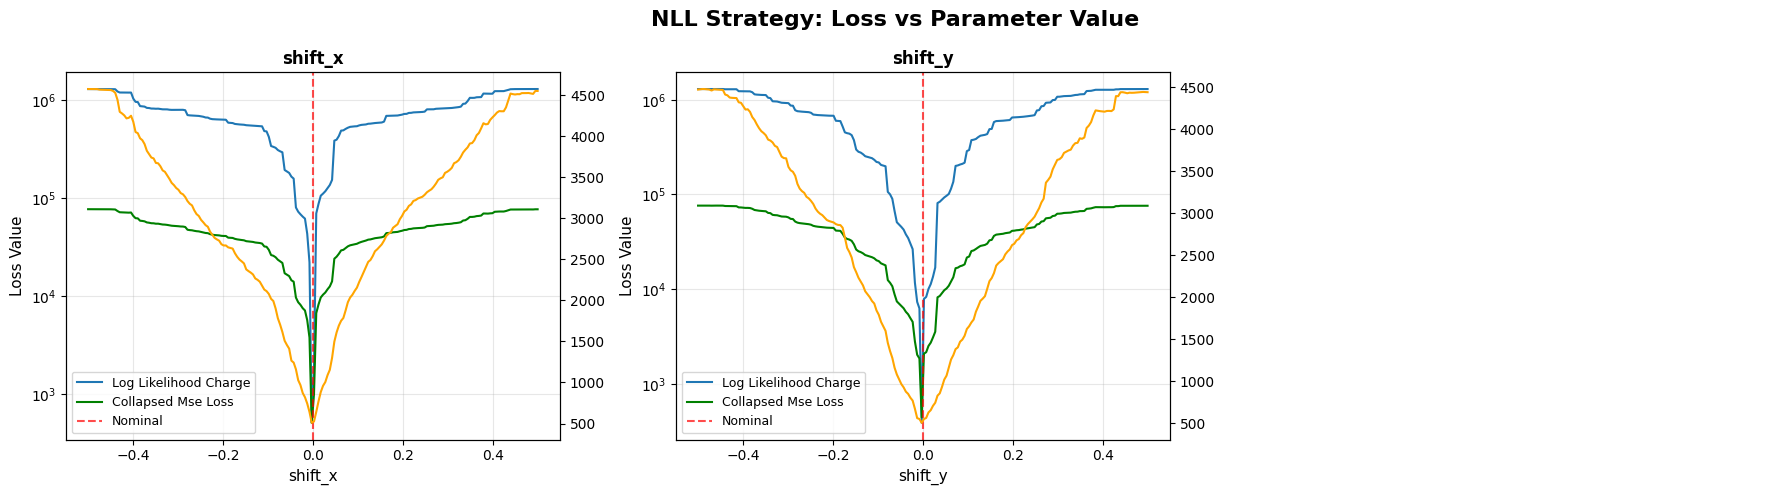

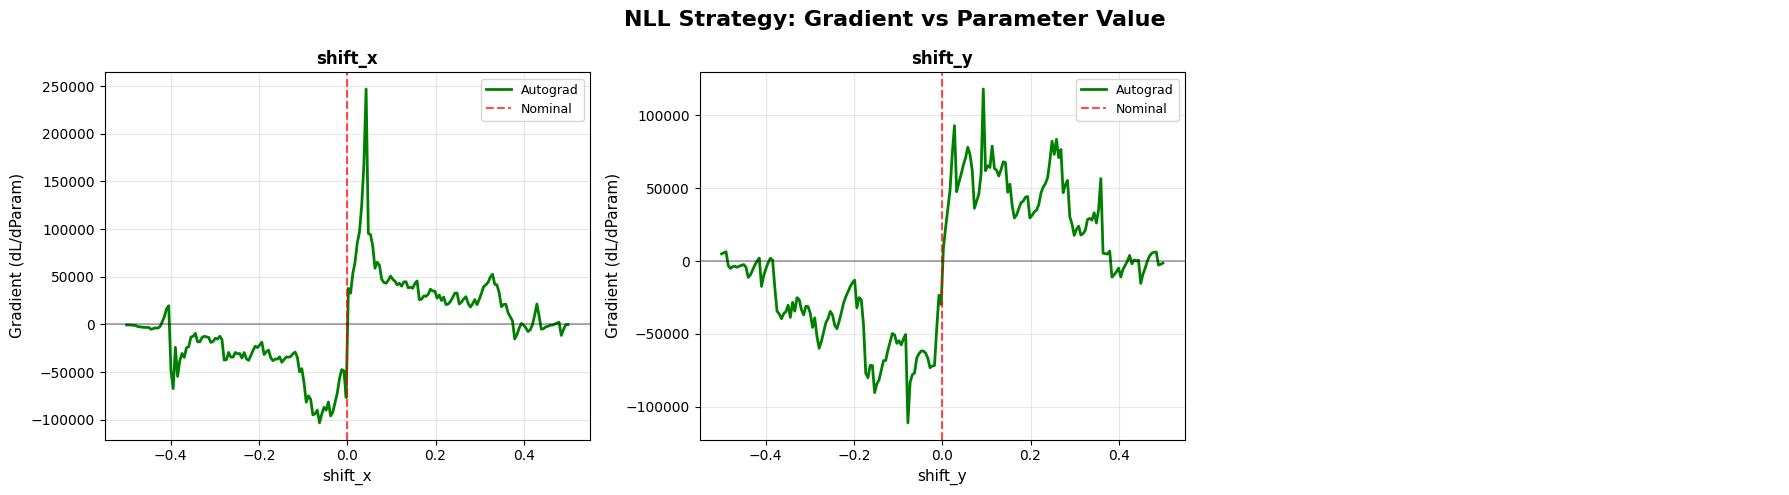

In [9]:
# --- Plot Results: Loss and Gradient Comparison for All Parameters ---

import matplotlib.pyplot as plt

# Determine grid layout
n_params = len(all_results)
n_cols = 3
n_rows = int(np.ceil(n_params / n_cols))

# Create figure for Loss plots
fig_loss, axes_loss = plt.subplots(n_rows, n_cols, figsize=(18, 5*n_rows))
fig_loss.suptitle('NLL Strategy: Loss vs Parameter Value', fontsize=16, fontweight='bold')
axes_loss = axes_loss.flatten() if n_params > 1 else [axes_loss]

# Create figure for Gradient plots
fig_grad, axes_grad = plt.subplots(n_rows, n_cols, figsize=(18, 5*n_rows))
fig_grad.suptitle('NLL Strategy: Gradient vs Parameter Value', fontsize=16, fontweight='bold')
axes_grad = axes_grad.flatten() if n_params > 1 else [axes_grad]

# to_plot = ['collapsed_mse_loss', 'log_likelihood_charge', 'log_likelihood_tick']
to_plot = ['log_likelihood_charge', 'log_likelihood_tick']

# Plot each parameter
for idx, (param_name, results) in enumerate(all_results.items()):
    # Get nominal value for this parameter
    param_nominal = getattr(current_params, param_name)
    
    # Convert to arrays
    scan_vals = np.array(results['scan_values'])
    mse_loss = np.array(results['collapsed_mse_loss'])
    mse_grad = np.array(results['collapsed_mse_grad'])
    charge_loss = np.array(results['charge_loss'])
    mmd_loss = np.array(results['mmd_loss'])
    
    # Compute finite difference gradient
    mse_fd_grad = np.gradient(mse_loss, scan_vals)
    
    # Plot Loss
    ax_loss = axes_loss[idx]
    ax_loss.set_yscale('symlog')
    # for loss_key in to_plot:
    #     values = np.array(results[loss_key])
    #     # if loss_key == 'log_likelihood_tick':
    #     #     values = values*100
    #     ax_loss.plot(scan_vals, values, label=loss_key.replace('_', ' ').title())
    loss_key = 'log_likelihood_charge'  # Change this to plot different loss components
    ax_loss.plot(scan_vals, np.array(results[loss_key]), label=loss_key.replace('_', ' ').title())
    loss_key = 'collapsed_mse_loss'  # Change this to plot different loss components
    ax_loss.plot(scan_vals, np.array(results[loss_key]), label=loss_key.replace('_', ' ').title(), color='green')
    loss_key = 'log_likelihood_tick'
    ax2 = ax_loss.twinx()
    ax2.plot(scan_vals, np.array(results[loss_key]), label=loss_key.replace('_', ' ').title(), color='orange')
    # loss_key = 'no_match_penalty'
    # ax2.plot(scan_vals, np.array(results[loss_key]), label=loss_key.replace('_', ' ').title(), color='green')

    # ax_loss.plot(scan_vals, mse_loss, 'g-', linewidth=2, label='Total Loss')
    # ax_loss.plot(scan_vals, charge_loss, 'c--', linewidth=1.5, label='Charge Loss')
    # ax_loss.plot(scan_vals, mmd_loss, 'm--', linewidth=1.5, label='MMD Loss')
    ax_loss.axvline(param_nominal, color='red', linestyle='--', alpha=0.7, label='Nominal')
    ax_loss.set_xlabel(f'{param_name}', fontsize=11)
    ax_loss.set_ylabel('Loss Value', fontsize=11)
    ax_loss.set_title(f'{param_name}', fontsize=12, fontweight='bold')
    ax_loss.grid(True, alpha=0.3)
    ax_loss.legend(fontsize=9)
    
    # Plot Gradient
    ax_grad = axes_grad[idx]
    ax_grad.plot(scan_vals, mse_grad, 'g-', linewidth=2, label='Autograd')
    # ax_grad.plot(scan_vals, mse_fd_grad, 'g--', linewidth=2, alpha=0.6, label='Finite Diff')
    ax_grad.axvline(param_nominal, color='red', linestyle='--', alpha=0.7, label='Nominal')
    ax_grad.axhline(0.0, color='black', linestyle='-', alpha=0.3)
    ax_grad.set_xlabel(f'{param_name}', fontsize=11)
    ax_grad.set_ylabel('Gradient (dL/dParam)', fontsize=11)
    ax_grad.set_title(f'{param_name}', fontsize=12, fontweight='bold')
    ax_grad.grid(True, alpha=0.3)
    ax_grad.legend(fontsize=9)

# Hide unused subplots
for idx in range(n_params, len(axes_loss)):
    axes_loss[idx].axis('off')
    axes_grad[idx].axis('off')

fig_loss.tight_layout()
fig_grad.tight_layout()
plt.show()




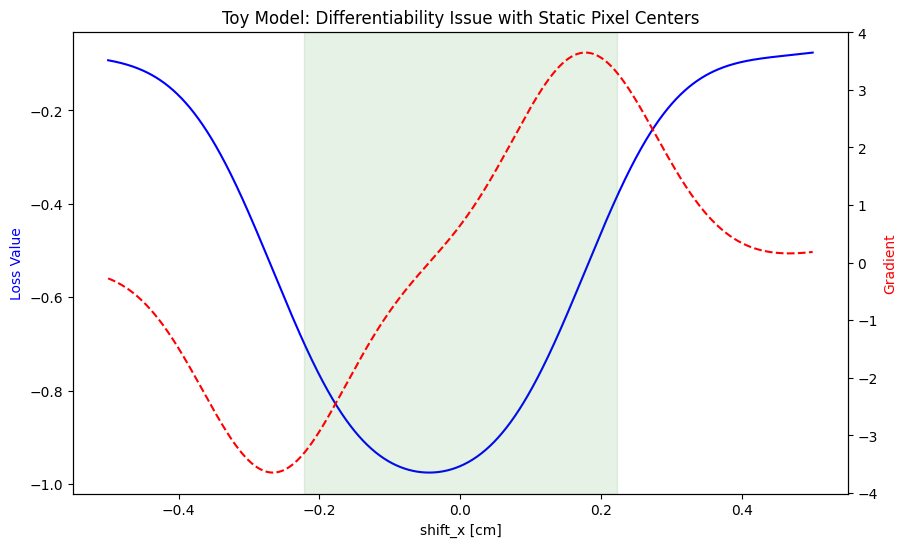

In [87]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from jax.scipy.special import erf

# Mocking the integral function from your detsim_jax.py
def gaussian_1d_integral_new(bin_edges, x0, std):
    calculated_edges = bin_edges - x0
    erf_at_borders = jnp.ones_like(calculated_edges)
    erf_at_borders = erf_at_borders.at[:, 0].set(-1)
    erf_at_borders = erf_at_borders.at[:, 1:-1].set(erf(calculated_edges[:, 1:-1] / (jnp.sqrt(2) * std)))
    return 0.5 * (erf_at_borders[:, 1:] - erf_at_borders[:, :-1])

def simulation_with_static_centers(shift_x, track_x, params):
    """
    Modified toy mimicking the full simulation's gradient bottleneck.
    """
    x_shifted = track_x - shift_x
    width = params['pixel_pitch'] / params['nb_sampling_bins_per_pixel']
    nb_bins = params['nb_tran_diff_bins']
    nb_bins_sym = (nb_bins - 1) // 2
    
    # 1. Smooth Weight Calculation (This part is differentiable)
    x0 = x_shifted % width
    bin_edges = jnp.linspace(-nb_bins_sym * width, (nb_bins_sym + 1) * width, nb_bins + 1)
    x_weights = gaussian_1d_integral_new(bin_edges[None, :], x0, params['sigma']).flatten()
    
    # 2. Discrete Indexing (Snap to Pixel IDs)
    bin_index_track = jnp.floor(x_shifted / width).astype(int)
    global_bin_indices = bin_index_track + jnp.arange(-nb_bins_sym, nb_bins_sym + 1)
    N = params['nb_sampling_bins_per_pixel']
    pixel_ids = (global_bin_indices + N // 2) // N
    
    # 3. STATIC COORDINATE RECONSTRUCTION (The Bottleneck)
    # In the real sim, id2pixel gives the center of the pixel
    # We map each bin weight to the center of its parent pixel.
    pixel_centers = pixel_ids * params['pixel_pitch']
    
    # 4. NLL-like Loss Calculation
    # Instead of just summing weights, we calculate a distance-based loss 
    # (like NLL/MMD) using the 'reconstructed' static centers
    target_x = 0.0 # Our reference/target position
    distances_sq = (pixel_centers - target_x)**2
    
    # Gaussian kernel logic similar to nll_loss or rbf_kernel
    sigma_loss = 0.2
    kernel_values = jnp.exp(-distances_sq / (2 * sigma_loss**2))
    
    # Total loss is sum of weights multiplied by the spatial kernel
    return -jnp.sum(x_weights * kernel_values)

# --- Params ---
params = {
    'pixel_pitch': 0.4434,
    'nb_sampling_bins_per_pixel': 5,
    'nb_tran_diff_bins': 15,
    'sigma': 0.1
}

# --- Scan ---
shifts = jnp.linspace(-0.5, 0.5, 1000)
grad_fn = jax.vmap(jax.value_and_grad(lambda s: simulation_with_static_centers(s, 0.0, params)))
losses, gradients = grad_fn(shifts)

# --- Plot ---
fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.plot(shifts, losses, label='NLL-like Loss', color='blue')
ax1.set_xlabel('shift_x [cm]')
ax1.set_ylabel('Loss Value', color='blue')

ax2 = ax1.twinx()
ax2.plot(shifts, gradients, label='Gradient', color='red', linestyle='--')
ax2.set_ylabel('Gradient', color='red')

plt.axvspan(-params['pixel_pitch']/2, params['pixel_pitch']/2, alpha=0.1, color='green', label='Pixel 0 Width')
plt.title('Toy Model: Differentiability Issue with Static Pixel Centers')
plt.show()

In [51]:
import jax.numpy as jnp
from jax.scipy.special import erf

def gaussian_1d_integral(bin_edges, x0, std):
    calculated_edges = bin_edges - x0
    # Simplified version of the integral logic in detsim_jax
    erf_at_borders = erf(calculated_edges / (jnp.sqrt(2) * std))
    return 0.5 * (erf_at_borders[1:] - erf_at_borders[:-1])

# Simulation Parameters
nb_tran_diff_bins = 5
nb_tran_diff_bins_sym = (nb_tran_diff_bins - 1) // 2
width = 0.004434 # e.g., pixel_pitch / nb_sampling_bins_per_pixel

# Test Case: Track is exactly in the middle of a sampling bin
x0 = 0.5 * width 
sigma = 1e-6 # Negligible diffusion
# 1. Buggy Binning (Centered at 0)
# Resulting bins: [-2.5w, -1.5w, -0.5w, 0.5w, 1.5w, 2.5w]
bins_buggy = jnp.linspace(-(nb_tran_diff_bins/2) * width, 
                         (nb_tran_diff_bins/2) * width, 
                         nb_tran_diff_bins + 1)
# 2. Corrected Binning (Aligned with local bin [0, width])
# Resulting bins: [-2w, -1w, 0, w, 2w, 3w]
bins_correct = jnp.linspace(-nb_tran_diff_bins_sym * width, 
                           (nb_tran_diff_bins_sym + 1) * width, 
                           nb_tran_diff_bins + 1)
weights_buggy = gaussian_1d_integral(bins_buggy, x0, sigma)
weights_correct = gaussian_1d_integral(bins_correct, x0, sigma)
print(f"Track position x0: {x0:.6f} (Middle of sampling bin [0, {width:.6f}])")
print("-" * 30)
print("BUGGY BINNING WEIGHTS:")
print(weights_buggy)
print(f"-> Issue: Splits charge 50/50 between bins {jnp.argmax(weights_buggy)} and {jnp.argmax(weights_buggy)+1}")
print("\nCORRECTED BINNING WEIGHTS:")
print(weights_correct)

Track position x0: 0.002217 (Middle of sampling bin [0, 0.004434])
------------------------------
BUGGY BINNING WEIGHTS:
[0.         0.         0.5001857  0.49981418 0.        ]
-> Issue: Splits charge 50/50 between bins 2 and 3

CORRECTED BINNING WEIGHTS:
[0.        0.        0.9999999 0.        0.       ]


In [16]:
# --- Debug Gradient Propagation: Track Individual Pixel-Tick Probabilities ---

# Select 10 pixels with hits from the target (stochastic simulation)
target_pixel_ids = target_output['hit_pixels']
target_adcs = target_output['adcs']
target_ticks = target_output['ticks']  # Get the time ticks for each hit

# Sort by ADC value (descending) and select top 10 hits (pixel-tick pairs)
sorted_indices = jnp.argsort(-target_adcs)[:10]
selected_pixel_ids = target_pixel_ids[sorted_indices]
selected_target_adcs = target_adcs[sorted_indices]
selected_target_ticks = target_ticks[sorted_indices]

print("Selected 10 pixel-tick pairs for gradient debugging:")
print(f"Pixel IDs: {selected_pixel_ids}")
print(f"Target ticks: {selected_target_ticks}")
print(f"Target ADC values: {selected_target_adcs}")

# Get probabilities and charges for these specific pixel-tick pairs at nominal params
nominal_pred = pred_strategy.predict(current_params, tracks, track_fields, rngkey)
print(f"\nAvailable fields in prediction: {list(nominal_pred.keys())}")
print(f"Shape of hit_pixels: {nominal_pred['hit_pixels'].shape}")
if 'ticks_prob' in nominal_pred:
    print(f"Shape of ticks_prob: {nominal_pred['ticks_prob'].shape}")
if 'adcs_distrib' in nominal_pred:
    print(f"Shape of adcs_distrib: {nominal_pred['adcs_distrib'].shape}")

# Function to extract probability and charge for a specific pixel-tick pair
def get_pixel_tick_values(prediction, pixel_id, tick_idx):
    """Extract probability and charge for a specific pixel-tick combination"""
    pred_pixel_ids = prediction['hit_pixels']
    
    # Find the pixel in the prediction
    pixel_mask = pred_pixel_ids == pixel_id
    pixel_idx = jnp.where(pixel_mask, size=1, fill_value=0)[0][0]
    
    # Get probability for this specific tick
    # ticks_prob shape: (n_pixels, n_samples, n_ticks)
    # Use jnp.where to avoid branching in traced code
    if 'ticks_prob' in prediction:
        prob = jnp.sum(prediction['ticks_prob'][pixel_idx, :, tick_idx])
        # If pixel not found, return 0
        prob = jnp.where(jnp.any(pixel_mask), prob, 0.0)
    else:
        prob = jnp.array(0.0)
    
    # Get predicted charge (ADC) for this pixel-tick
    # adcs_distrib shape: (n_pixels, n_samples, n_ticks)
    if 'adcs_distrib' in prediction:
        charge = jnp.sum(prediction['adcs_distrib'][pixel_idx, :, tick_idx])
        # If pixel not found, return 0
        charge = jnp.where(jnp.any(pixel_mask), charge, 0.0)
    else:
        charge = jnp.array(0.0)
    
    return prob, charge

# Get values at nominal for selected hits
selected_nominal_probs = []
selected_nominal_charges = []
for i in range(len(selected_pixel_ids)):
    # Convert tick to int for indexing (safe here, not in traced function)
    tick_idx = int(selected_target_ticks[i])
    prob, charge = get_pixel_tick_values(nominal_pred, selected_pixel_ids[i], tick_idx)
    selected_nominal_probs.append(prob)
    selected_nominal_charges.append(charge)

selected_nominal_probs = jnp.array(selected_nominal_probs)
selected_nominal_charges = jnp.array(selected_nominal_charges)

print(f"\nAt nominal parameters:")
print(f"Probabilities: {selected_nominal_probs}")
print(f"Predicted charges: {selected_nominal_charges}")
print(f"Target charges: {selected_target_adcs}")

# Function to extract probabilities and charges for selected pixel-tick pairs
def get_selected_pixel_tick_values(param_val, param_name):
    """Get probabilities and charges for selected pixel-tick pairs"""
    p = current_params.replace(**{param_name: param_val})
    prediction = pred_strategy.predict(p, tracks, track_fields, rngkey)
    
    probs = []
    charges = []
    for i in range(len(selected_pixel_ids)):
        # Convert tick to int outside the traced function
        tick_idx = int(selected_target_ticks[i])
        prob, charge = get_pixel_tick_values(prediction, selected_pixel_ids[i], tick_idx)
        probs.append(prob)
        charges.append(charge)
    
    return jnp.stack(probs), jnp.stack(charges)

# Create separate functions for probabilities and charges (for Jacobian computation)
def get_selected_probs_only(param_val, param_name):
    """Returns only probabilities"""
    probs, _ = get_selected_pixel_tick_values(param_val, param_name)
    return probs

def get_selected_charges_only(param_val, param_name):
    """Returns only charges"""
    _, charges = get_selected_pixel_tick_values(param_val, param_name)
    return charges

print("\nFunctions created for extracting pixel-tick probabilities and charges.")

Selected 10 pixel-tick pairs for gradient debugging:
Pixel IDs: [3088414 3090526 3922411 3966094 3969595 4561870 4565940 4567906 6195549
 7250715]
Target ticks: [ 764.  718. 1724. 1722. 1490. 1636.  567.  198. 1495.   25.]
Target ADC values: [256. 256. 256. 256. 256. 256. 256. 256. 256. 256.]

Available fields in prediction: ['adcs_distrib', 'ticks_prob', 'pixel_x', 'pixel_y', 'pixel_plane', 'event', 'unique_pixels', 'hit_pixels', 'wfs']
Shape of hit_pixels: (128,)
Shape of ticks_prob: (128, 10, 1998)
Shape of adcs_distrib: (128, 10, 1998)

At nominal parameters:
Probabilities: [0.10328048 0.03771194 0.01128984 0.08931729 0.02642107 0.0166939
 0.09688617 0.09397614 0.09298863 0.0006797 ]
Predicted charges: [2560. 2560. 2560. 2560. 2560. 2560. 2560. 2560. 2560. 2560.]
Target charges: [256. 256. 256. 256. 256. 256. 256. 256. 256. 256.]

Functions created for extracting pixel-tick probabilities and charges.


In [19]:
# --- Scan Parameters and Track Pixel-Tick Probabilities and Charges ---

# Choose a parameter to scan for detailed analysis
debug_param = 'eField'  # Change this to debug different parameters
debug_param_nominal = getattr(current_params, debug_param)

# Create scan range
debug_scan_factors = np.linspace(0.5, 1.5, 200)
debug_scan_values = debug_param_nominal * debug_scan_factors

# Storage for pixel-tick probabilities, charges, and gradients
pixel_probs_evolution = []
pixel_charges_evolution = []
pixel_prob_jacobians = []
pixel_charge_jacobians = []

print(f"Scanning {debug_param} to track pixel-tick probabilities and charges...")
print(f"Nominal value: {debug_param_nominal:.6f}")
print(f"Scan range: {debug_scan_values[0]:.6f} to {debug_scan_values[-1]:.6f}")

# For each scan value, get probabilities, charges, and Jacobians
for param_val in tqdm(debug_scan_values):
    # Get probabilities and charges
    probs, charges = get_selected_pixel_tick_values(param_val, debug_param)
    pixel_probs_evolution.append(np.array(probs))
    pixel_charges_evolution.append(np.array(charges))
    
    # Compute Jacobian for probabilities
    def prob_func(pval):
        return get_selected_probs_only(pval, debug_param)
    
    jac_prob = jax.jacobian(prob_func)(param_val)
    pixel_prob_jacobians.append(np.array(jac_prob))
    
    # Compute Jacobian for charges
    def charge_func(pval):
        return get_selected_charges_only(pval, debug_param)
    
    jac_charge = jax.jacobian(charge_func)(param_val)
    pixel_charge_jacobians.append(np.array(jac_charge))

pixel_probs_evolution = np.array(pixel_probs_evolution)  # Shape: (n_scan, n_hits)
pixel_charges_evolution = np.array(pixel_charges_evolution)  # Shape: (n_scan, n_hits)
pixel_prob_jacobians = np.array(pixel_prob_jacobians)  # Shape: (n_scan, n_hits)
pixel_charge_jacobians = np.array(pixel_charge_jacobians)  # Shape: (n_scan, n_hits)

print(f"Scan complete! Tracked {len(selected_pixel_ids)} pixel-tick pairs over {len(debug_scan_values)} parameter values.")
print(f"Probability evolution shape: {pixel_probs_evolution.shape}")
print(f"Charge evolution shape: {pixel_charges_evolution.shape}")
print(f"Probability Jacobian shape: {pixel_prob_jacobians.shape}")
print(f"Charge Jacobian shape: {pixel_charge_jacobians.shape}")

Scanning eField to track pixel-tick probabilities and charges...
Nominal value: 0.500000
Scan range: 0.250000 to 0.750000


  0%|          | 0/200 [00:00<?, ?it/s]

100%|██████████| 200/200 [02:03<00:00,  1.62it/s]

Scan complete! Tracked 10 pixel-tick pairs over 200 parameter values.
Probability evolution shape: (200, 10)
Charge evolution shape: (200, 10)
Probability Jacobian shape: (200, 10)
Charge Jacobian shape: (200, 10)


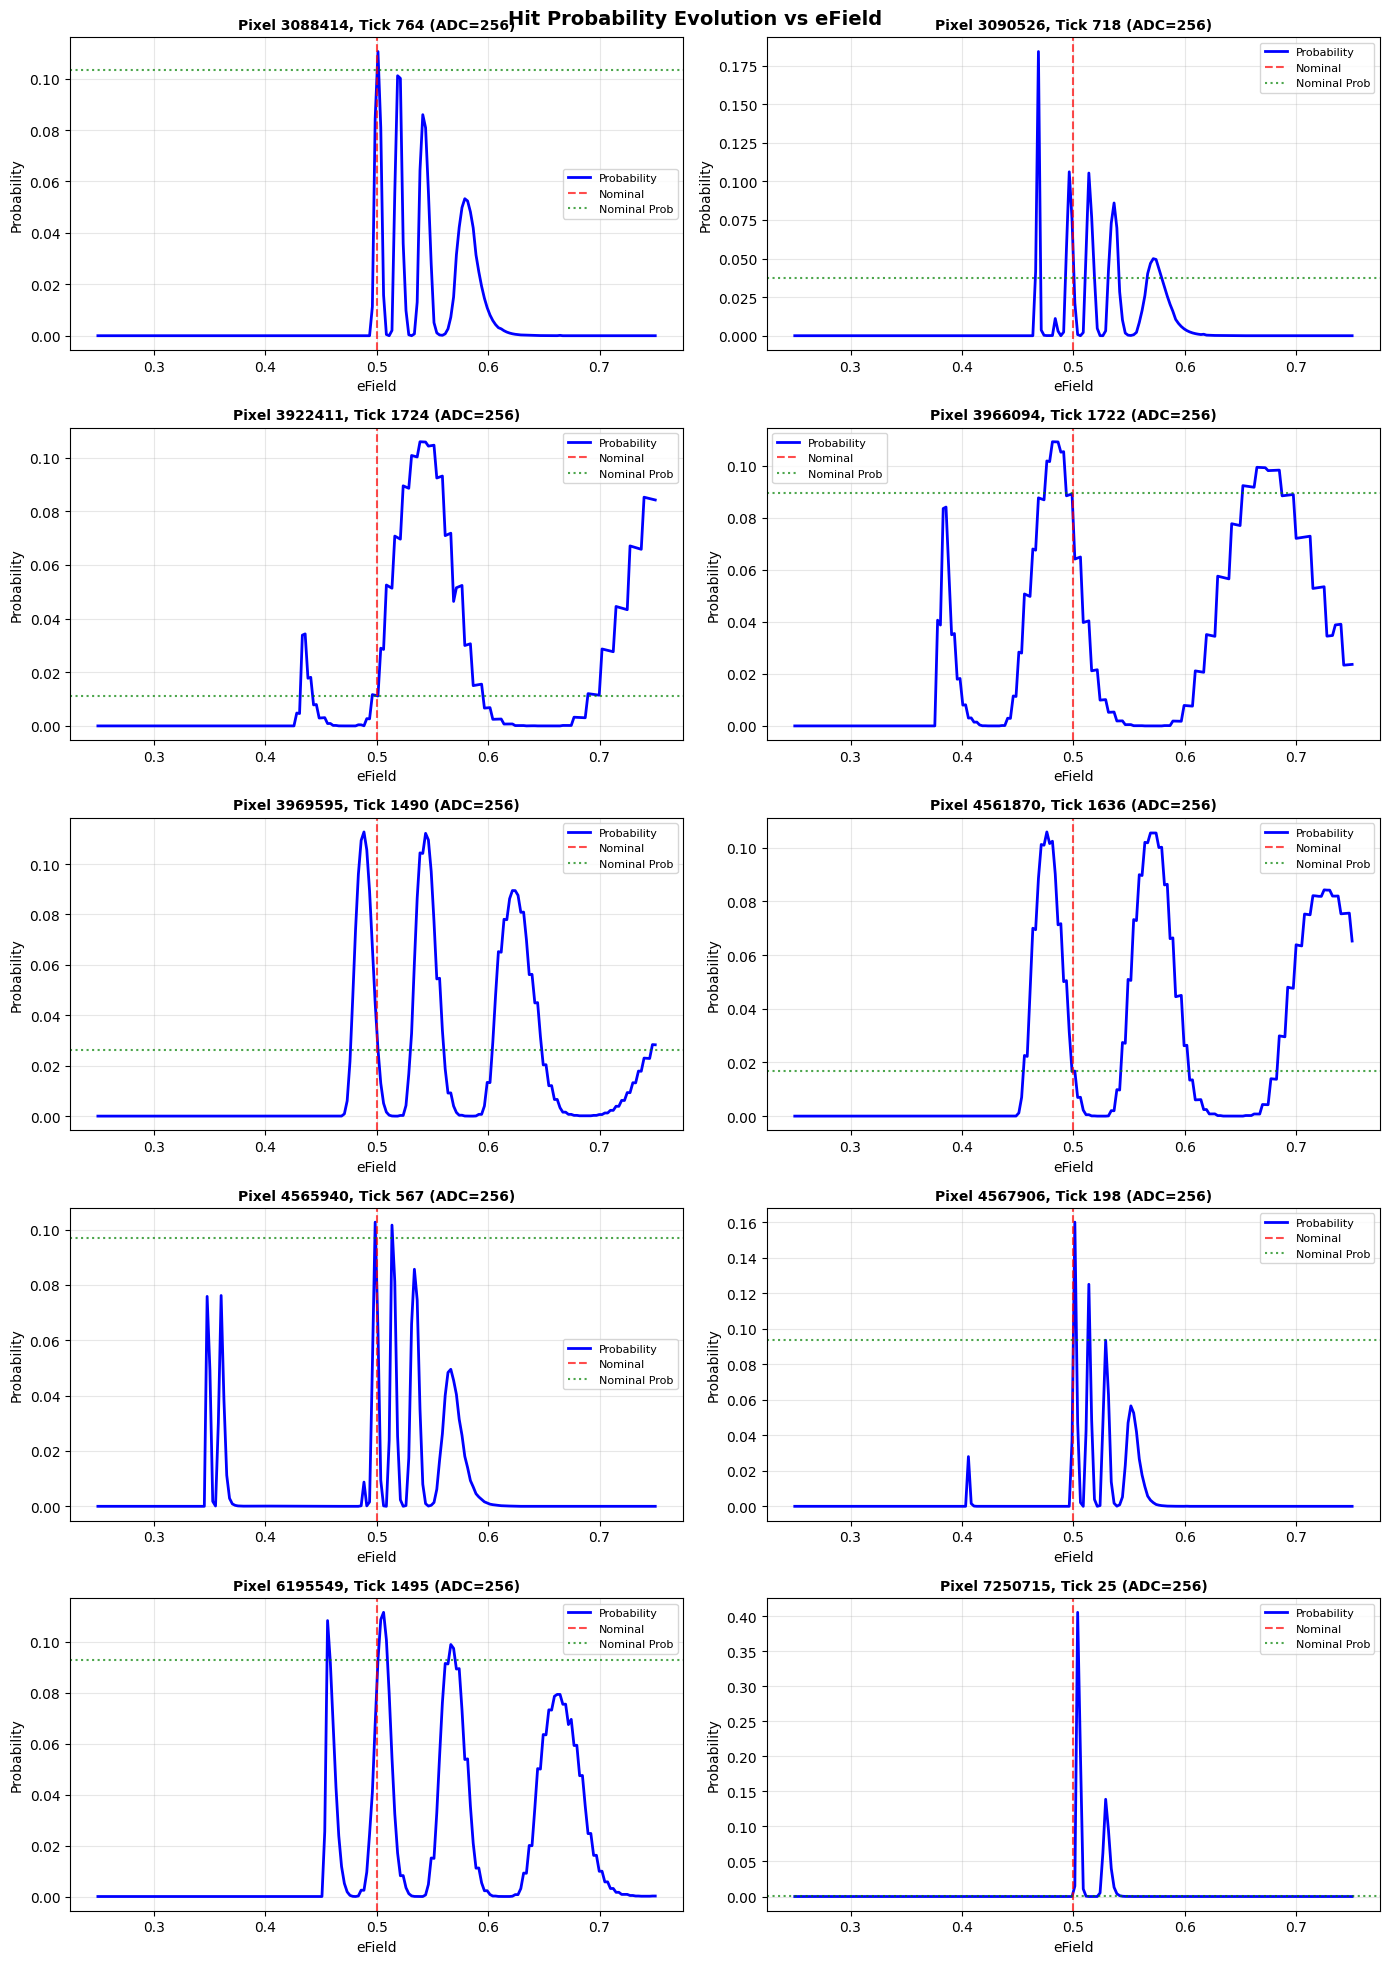

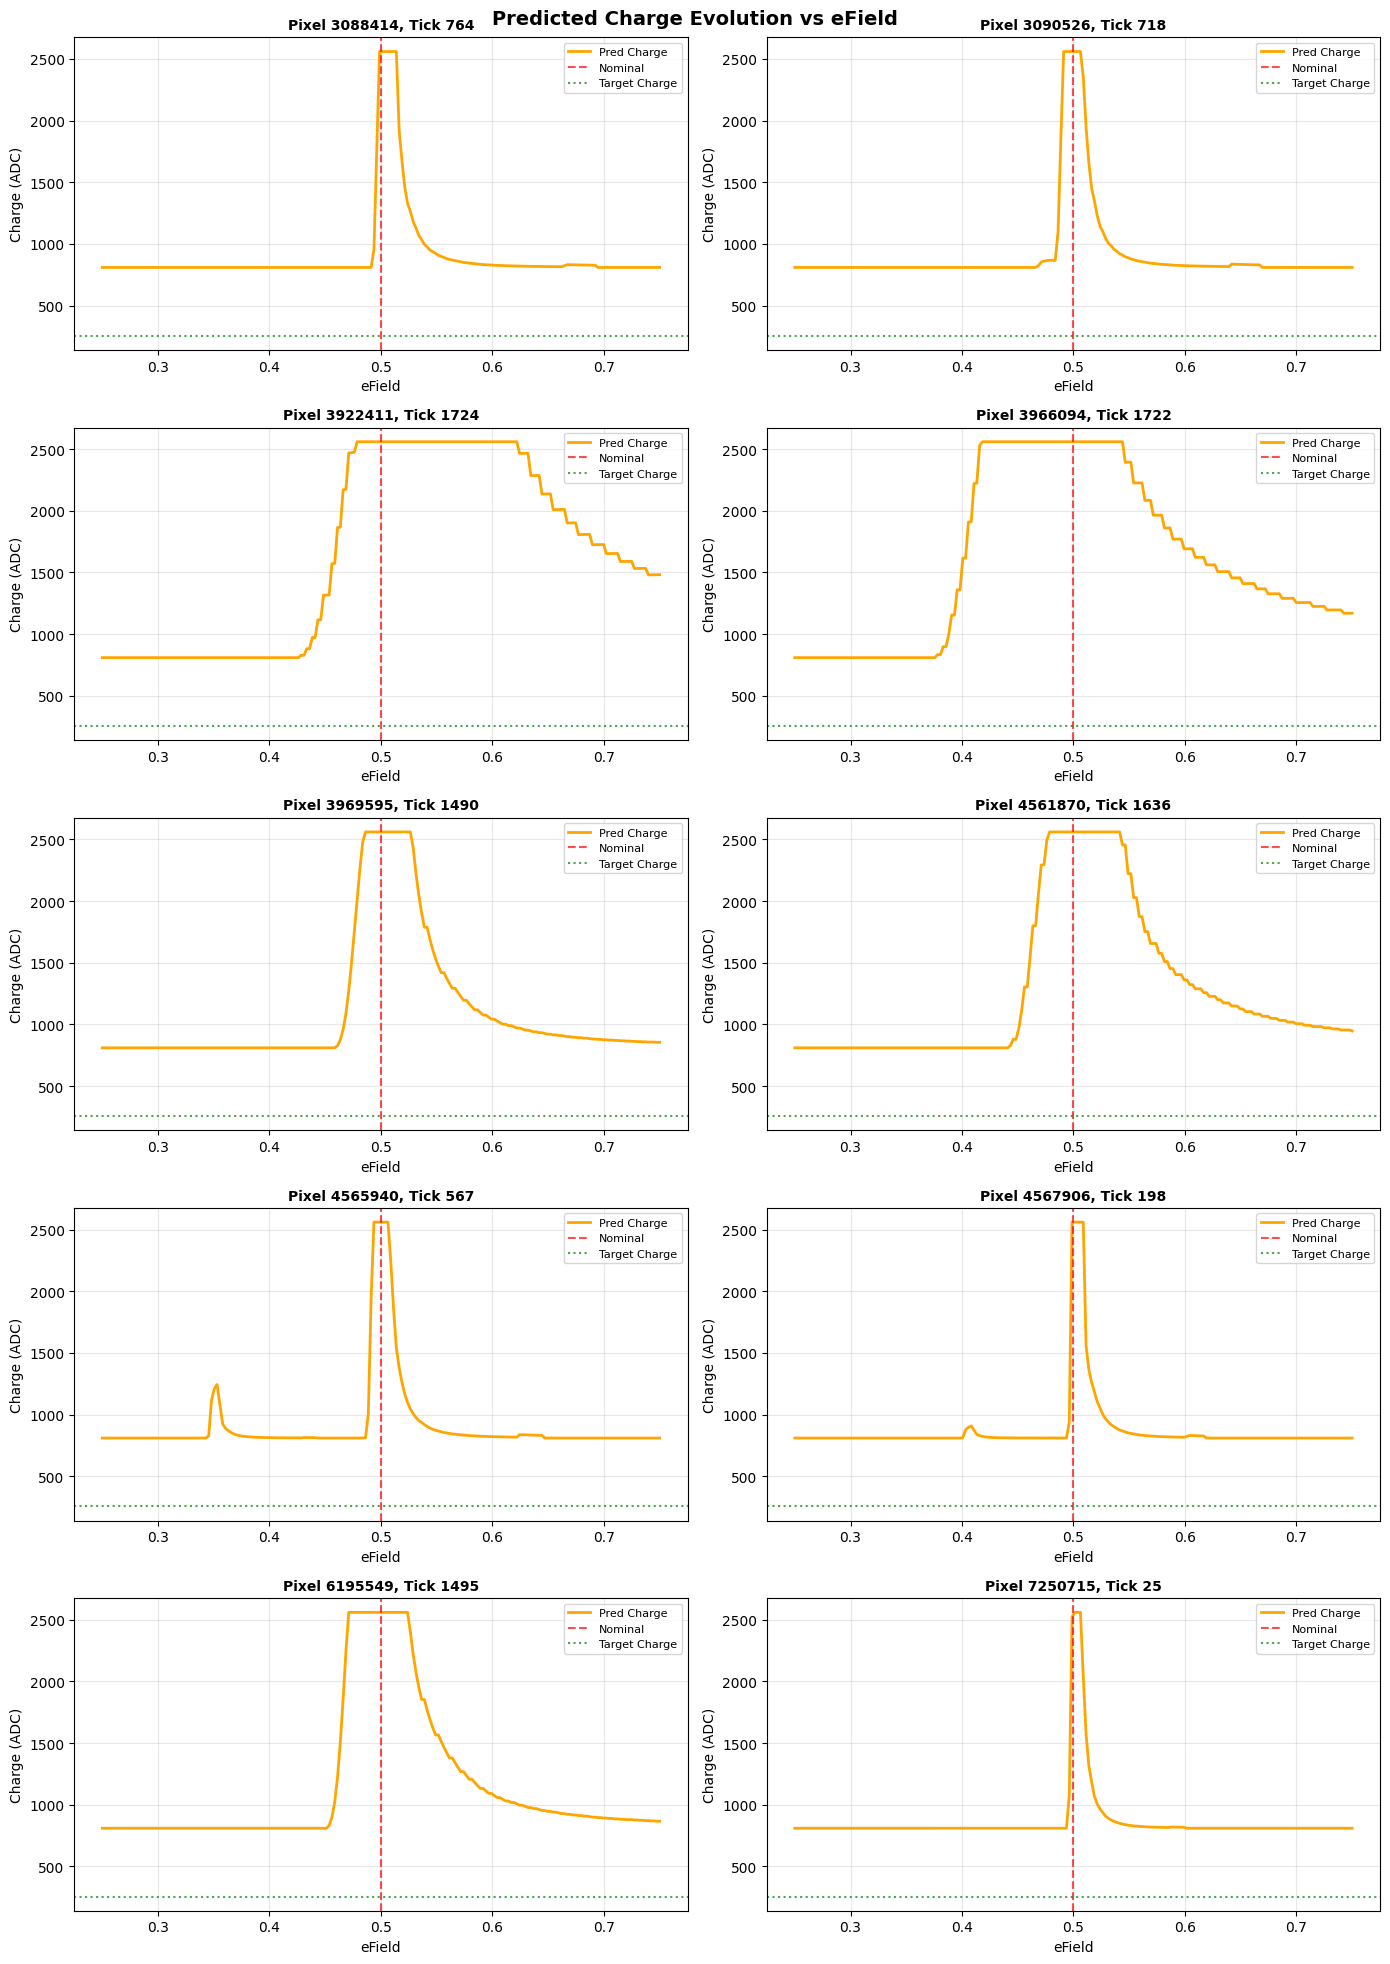

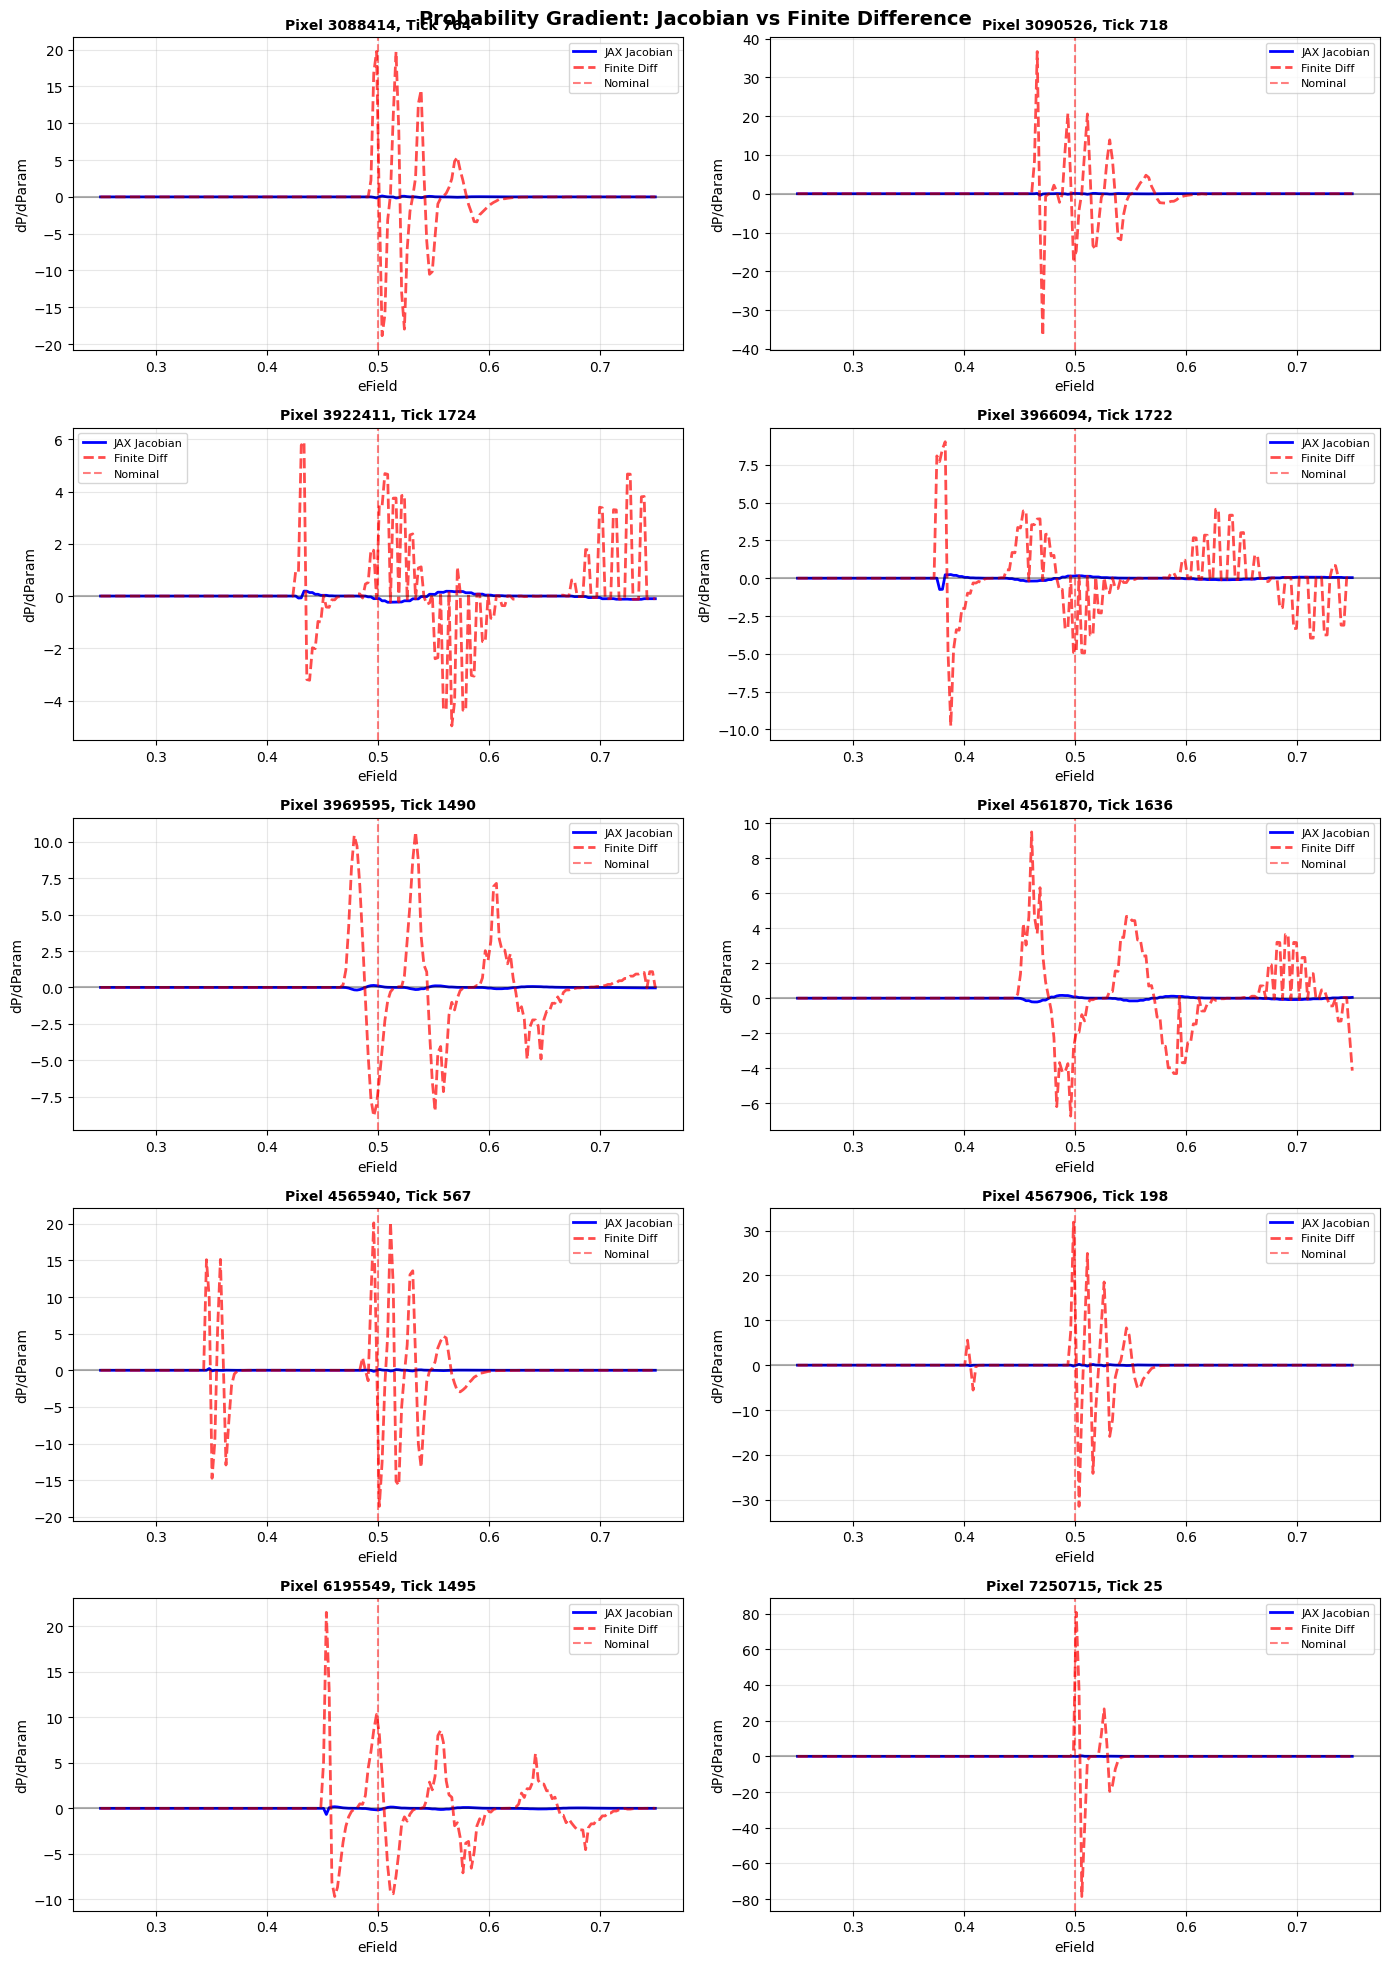

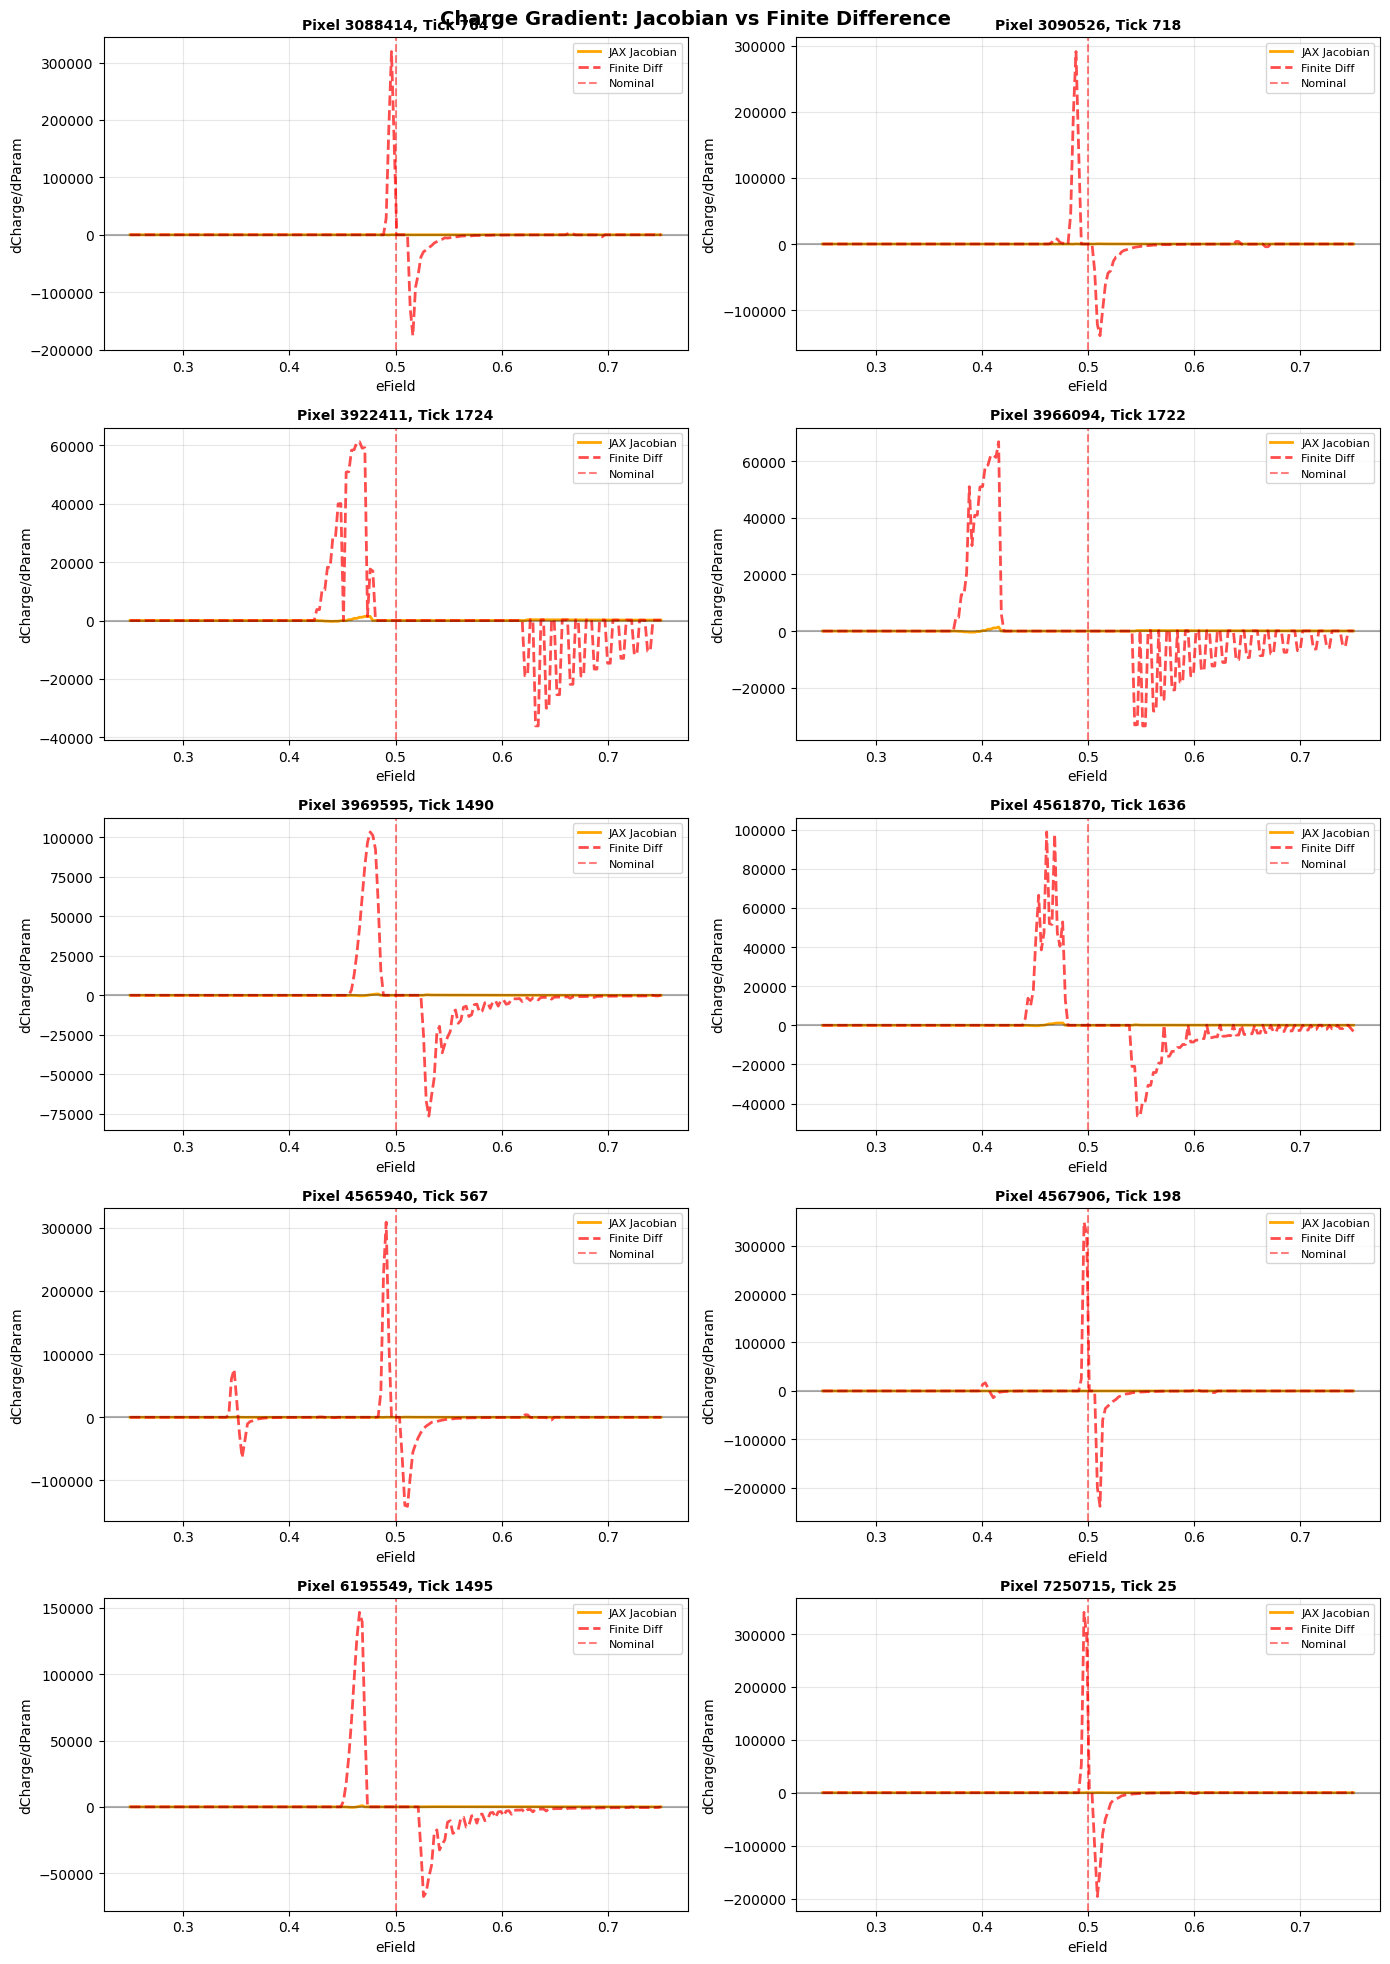


GRADIENT COMPARISON STATISTICS (per hit)

Hit #1: Pixel 3088414, Tick 764
  Target charge: 256.0 ADC

  PROBABILITY:
    Value at nominal: 0.084501
    Jacobian at nominal: -1.505965e-01
    FD gradient at nominal: 1.974900e+01
    Mean absolute difference: 1.337427e+00
    Max absolute difference: 1.989960e+01
    Sign agreement: 14.0%

  CHARGE:
    Value at nominal: 2560.0 ADC
    Jacobian at nominal: 0.000000e+00
    FD gradient at nominal: 1.614089e+05
    Mean absolute difference: 7.037946e+03
    Max absolute difference: 3.188272e+05
    Sign agreement: 63.5%

  NLL CONTRIBUTION (approximate):
    At nominal: 13.087824
    Min: 3.480543, Max: 26.662338

Hit #2: Pixel 3090526, Tick 718
  Target charge: 256.0 ADC

  PROBABILITY:
    Value at nominal: 0.075177
    Jacobian at nominal: 1.034343e-01
    FD gradient at nominal: -1.689351e+01
    Mean absolute difference: 1.712448e+00
    Max absolute difference: 3.655619e+01
    Sign agreement: 21.0%

  CHARGE:
    Value at nominal: 

In [20]:
# --- Plot Pixel-Tick Probability and Charge Evolution with Gradient Comparison ---

import matplotlib.pyplot as plt

# Compute finite difference gradients for comparison
pixel_prob_fd_grads = np.gradient(pixel_probs_evolution, debug_scan_values, axis=0)
pixel_charge_fd_grads = np.gradient(pixel_charges_evolution, debug_scan_values, axis=0)

# Create figure with subplots for each hit
n_hits = len(selected_pixel_ids)
n_cols = 2
n_rows = int(np.ceil(n_hits / n_cols))

# Figure 1: Probability Evolution
fig1, axes1 = plt.subplots(n_rows, n_cols, figsize=(14, 4*n_rows))
fig1.suptitle(f'Hit Probability Evolution vs {debug_param}', fontsize=14, fontweight='bold')
axes1 = axes1.flatten() if n_hits > 1 else [axes1]

for i in range(n_hits):
    ax = axes1[i]
    ax.plot(debug_scan_values, pixel_probs_evolution[:, i], 'b-', linewidth=2, label='Probability')
    ax.axvline(debug_param_nominal, color='red', linestyle='--', alpha=0.7, label='Nominal')
    ax.axhline(selected_nominal_probs[i], color='green', linestyle=':', alpha=0.7, label='Nominal Prob')
    ax.set_xlabel(f'{debug_param}', fontsize=10)
    ax.set_ylabel('Probability', fontsize=10)
    ax.set_title(f'Pixel {selected_pixel_ids[i]}, Tick {selected_target_ticks[i]:.0f} (ADC={selected_target_adcs[i]:.0f})', fontsize=10, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

for i in range(n_hits, len(axes1)):
    axes1[i].axis('off')

fig1.tight_layout()
plt.show()

# Figure 2: Charge Evolution
fig2, axes2 = plt.subplots(n_rows, n_cols, figsize=(14, 4*n_rows))
fig2.suptitle(f'Predicted Charge Evolution vs {debug_param}', fontsize=14, fontweight='bold')
axes2 = axes2.flatten() if n_hits > 1 else [axes2]

for i in range(n_hits):
    ax = axes2[i]
    ax.plot(debug_scan_values, pixel_charges_evolution[:, i], 'orange', linewidth=2, label='Pred Charge')
    ax.axvline(debug_param_nominal, color='red', linestyle='--', alpha=0.7, label='Nominal')
    ax.axhline(selected_target_adcs[i], color='green', linestyle=':', alpha=0.7, label='Target Charge')
    ax.set_xlabel(f'{debug_param}', fontsize=10)
    ax.set_ylabel('Charge (ADC)', fontsize=10)
    ax.set_title(f'Pixel {selected_pixel_ids[i]}, Tick {selected_target_ticks[i]:.0f}', fontsize=10, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

for i in range(n_hits, len(axes2)):
    axes2[i].axis('off')

fig2.tight_layout()
plt.show()

# Figure 3: Probability Gradient Comparison
fig3, axes3 = plt.subplots(n_rows, n_cols, figsize=(14, 4*n_rows))
fig3.suptitle(f'Probability Gradient: Jacobian vs Finite Difference', fontsize=14, fontweight='bold')
axes3 = axes3.flatten() if n_hits > 1 else [axes3]

for i in range(n_hits):
    ax = axes3[i]
    ax.plot(debug_scan_values, pixel_prob_jacobians[:, i], 'b-', linewidth=2, label='JAX Jacobian')
    ax.plot(debug_scan_values, pixel_prob_fd_grads[:, i], 'r--', linewidth=2, alpha=0.7, label='Finite Diff')
    ax.axvline(debug_param_nominal, color='red', linestyle='--', alpha=0.5, label='Nominal')
    ax.axhline(0.0, color='black', linestyle='-', alpha=0.3)
    ax.set_xlabel(f'{debug_param}', fontsize=10)
    ax.set_ylabel('dP/dParam', fontsize=10)
    ax.set_title(f'Pixel {selected_pixel_ids[i]}, Tick {selected_target_ticks[i]:.0f}', fontsize=10, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

for i in range(n_hits, len(axes3)):
    axes3[i].axis('off')

fig3.tight_layout()
plt.show()

# Figure 4: Charge Gradient Comparison
fig4, axes4 = plt.subplots(n_rows, n_cols, figsize=(14, 4*n_rows))
fig4.suptitle(f'Charge Gradient: Jacobian vs Finite Difference', fontsize=14, fontweight='bold')
axes4 = axes4.flatten() if n_hits > 1 else [axes4]

for i in range(n_hits):
    ax = axes4[i]
    ax.plot(debug_scan_values, pixel_charge_jacobians[:, i], 'orange', linewidth=2, label='JAX Jacobian')
    ax.plot(debug_scan_values, pixel_charge_fd_grads[:, i], 'r--', linewidth=2, alpha=0.7, label='Finite Diff')
    ax.axvline(debug_param_nominal, color='red', linestyle='--', alpha=0.5, label='Nominal')
    ax.axhline(0.0, color='black', linestyle='-', alpha=0.3)
    ax.set_xlabel(f'{debug_param}', fontsize=10)
    ax.set_ylabel('dCharge/dParam', fontsize=10)
    ax.set_title(f'Pixel {selected_pixel_ids[i]}, Tick {selected_target_ticks[i]:.0f}', fontsize=10, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

for i in range(n_hits, len(axes4)):
    axes4[i].axis('off')

fig4.tight_layout()
plt.show()

# Print gradient statistics for each pixel-tick pair
print("\n" + "="*80)
print("GRADIENT COMPARISON STATISTICS (per hit)")
print("="*80)

nominal_idx = np.argmin(np.abs(debug_scan_values - debug_param_nominal))

for i in range(n_hits):
    jac_prob = pixel_prob_jacobians[:, i]
    fd_prob = pixel_prob_fd_grads[:, i]
    diff_prob = np.abs(jac_prob - fd_prob)
    
    jac_charge = pixel_charge_jacobians[:, i]
    fd_charge = pixel_charge_fd_grads[:, i]
    diff_charge = np.abs(jac_charge - fd_charge)
    
    print(f"\nHit #{i+1}: Pixel {selected_pixel_ids[i]}, Tick {selected_target_ticks[i]:.0f}")
    print(f"  Target charge: {selected_target_adcs[i]:.1f} ADC")
    print(f"\n  PROBABILITY:")
    print(f"    Value at nominal: {pixel_probs_evolution[nominal_idx, i]:.6f}")
    print(f"    Jacobian at nominal: {jac_prob[nominal_idx]:.6e}")
    print(f"    FD gradient at nominal: {fd_prob[nominal_idx]:.6e}")
    print(f"    Mean absolute difference: {diff_prob.mean():.6e}")
    print(f"    Max absolute difference: {diff_prob.max():.6e}")
    sign_agreement_prob = np.sum(np.sign(jac_prob) == np.sign(fd_prob)) / len(jac_prob) * 100
    print(f"    Sign agreement: {sign_agreement_prob:.1f}%")
    
    print(f"\n  CHARGE:")
    print(f"    Value at nominal: {pixel_charges_evolution[nominal_idx, i]:.1f} ADC")
    print(f"    Jacobian at nominal: {jac_charge[nominal_idx]:.6e}")
    print(f"    FD gradient at nominal: {fd_charge[nominal_idx]:.6e}")
    print(f"    Mean absolute difference: {diff_charge.mean():.6e}")
    print(f"    Max absolute difference: {diff_charge.max():.6e}")
    sign_agreement_charge = np.sum(np.sign(jac_charge) == np.sign(fd_charge)) / len(jac_charge) * 100
    print(f"    Sign agreement: {sign_agreement_charge:.1f}%")
    
    # Compute NLL contribution (simplified): -log(prob) + charge_mismatch
    charge_mismatch = (pixel_charges_evolution[:, i] - selected_target_adcs[i])**2
    nll_approx = -np.log(pixel_probs_evolution[:, i] + 1e-10) + charge_mismatch / (2 * 500**2)
    print(f"\n  NLL CONTRIBUTION (approximate):")
    print(f"    At nominal: {nll_approx[nominal_idx]:.6f}")
    print(f"    Min: {nll_approx.min():.6f}, Max: {nll_approx.max():.6f}")

print("\n" + "="*80)

In [24]:
prediction['adcs_distrib'].shape

(128, 10, 1998)

In [25]:
# --- DIAGNOSTIC: Check Hit Order and Sample Index Handling ---

print("="*80)
print("DIAGNOSTIC: Checking hit order and sample index in NLL calculation")
print("="*80)

# Check what fields are available in target output
print("\n1. Target output structure (stochastic simulation):")
print(f"   Available fields: {list(target_output.keys())}")
for key in target_output.keys():
    if hasattr(target_output[key], 'shape'):
        print(f"   - {key}: shape {target_output[key].shape}")
    else:
        print(f"   - {key}: {type(target_output[key])}")

# Check if there's any sample/retrigger information
if 'sample_id' in target_output or 'retrigger' in target_output or 'trigger_id' in target_output:
    print("\n   Found sample/retrigger information in target!")
    for key in ['sample_id', 'retrigger', 'trigger_id']:
        if key in target_output:
            print(f"   {key}: {target_output[key]}")
else:
    print("\n   No explicit sample/retrigger information found in target output")

# Check prediction structure
print("\n2. Prediction output structure (probabilistic simulation):")
print(f"   Available fields: {list(nominal_pred.keys())}")
print(f"   - ticks_prob shape: {nominal_pred['ticks_prob'].shape}")
print(f"   - adcs_distrib shape: {nominal_pred['adcs_distrib'].shape}")
print(f"   - hit_pixels shape: {nominal_pred['hit_pixels'].shape}")
n_pixels_pred = nominal_pred['ticks_prob'].shape[0]
n_samples = nominal_pred['ticks_prob'].shape[1]
n_ticks = nominal_pred['ticks_prob'].shape[2]
print(f"\n   Interpretation: {n_pixels_pred} pixels, {n_samples} samples per pixel, {n_ticks} time ticks")

# Check how the current extraction sums over samples
print("\n3. Current extraction method (from get_pixel_tick_values):")
print("   We sum over all samples: jnp.sum(prediction['ticks_prob'][pixel_idx, :, tick_idx])")
print("   This gives the TOTAL probability across all samples/retriggerings")
print(f"   Example for pixel {selected_pixel_ids[0]}, tick {int(selected_target_ticks[0])}:")

test_pixel_id = selected_pixel_ids[0]
test_tick = int(selected_target_ticks[0])
test_pixel_mask = nominal_pred['hit_pixels'] == test_pixel_id
test_pixel_idx = jnp.where(test_pixel_mask, size=1, fill_value=0)[0][0]

probs_per_sample = nominal_pred['ticks_prob'][test_pixel_idx, :, test_tick]
charges_per_sample = nominal_pred['adcs_distrib'][test_pixel_idx, :, test_tick]

print(f"   Probabilities per sample: {probs_per_sample}")
print(f"   Sum of probabilities: {jnp.sum(probs_per_sample):.6f}")
print(f"   Charges per sample: {charges_per_sample}")
print(f"   Sum of charges: {jnp.sum(charges_per_sample):.2f}")

# Check if samples are independent or mutually exclusive
print("\n4. Checking if samples represent independent events or retriggering:")
print("   If samples are RETRIGGERING (mutually exclusive):")
print("     - Sum of probabilities across samples should be ≤ 1")
print("     - Only one sample should be 'active' at a time")
print("   If samples are INDEPENDENT:")
print("     - Probabilities can sum to > 1")
print("     - Multiple samples can contribute simultaneously")

# Check a few pixels to see the pattern
print(f"\n   Checking probability sums for first 5 predicted pixels:")
for i in range(min(5, n_pixels_pred)):
    prob_sum_over_samples = jnp.sum(nominal_pred['ticks_prob'][i, :, :])
    prob_max_at_any_tick = jnp.max(jnp.sum(nominal_pred['ticks_prob'][i, :, :], axis=0))
    print(f"   Pixel {i} (ID {nominal_pred['hit_pixels'][i]}): total prob sum = {prob_sum_over_samples:.3f}, "
          f"max prob at any tick = {prob_max_at_any_tick:.6f}")

# Check how multiple hits at the same pixel are handled in target
print("\n5. Checking for multiple hits at same pixel in target (retriggering):")
unique_pixels_in_target = jnp.unique(target_output['hit_pixels'])
print(f"   Total hits in target: {len(target_output['hit_pixels'])}")
print(f"   Unique pixels with hits: {len(unique_pixels_in_target)}")

# Find pixels with multiple hits
from collections import Counter
pixel_counts = Counter(np.array(target_output['hit_pixels']))
multi_hit_pixels = [(pid, count) for pid, count in pixel_counts.items() if count > 1]

if multi_hit_pixels:
    print(f"\n   Found {len(multi_hit_pixels)} pixels with multiple hits (retriggering)!")
    print(f"   Examples (pixel_id, num_hits):")
    for pid, count in multi_hit_pixels[:5]:
        print(f"     Pixel {pid}: {count} hits")
        # Show the ticks and ADCs for this pixel
        pixel_mask = target_output['hit_pixels'] == pid
        pixel_ticks = target_output['ticks'][pixel_mask]
        pixel_adcs = target_output['adcs'][pixel_mask]
        print(f"       Ticks: {pixel_ticks}")
        print(f"       ADCs: {pixel_adcs}")
else:
    print("   No pixels with multiple hits found")

# Investigate how ProbabilisticLossStrategy handles this
print("\n6. Checking NLL strategy implementation:")
print("   Let's trace how the loss is computed for a pixel with multiple hits...")

# Look at the source or check the loss computation
print("   The ProbabilisticLossStrategy should:")
print("   a) For each hit in target, find the corresponding pixel in prediction")
print("   b) Extract the probability at the target tick")
print("   c) Extract the predicted charge at the target tick")
print("   d) Compute: -log(prob) + (charge_pred - charge_target)^2 / (2*sigma^2)")
print("\n   CRITICAL QUESTION: Does it sum over all samples, or match sample indices?")

print("\n" + "="*80)

DIAGNOSTIC: Checking hit order and sample index in NLL calculation

1. Target output structure (stochastic simulation):
   Available fields: ['adcs', 'pixel_x', 'pixel_y', 'pixel_z', 'ticks', 'hit_prob', 'event', 'hit_pixels', 'unique_pixels', 'wfs', 'pixel_id']
   - adcs: shape (252,)
   - pixel_x: shape (252,)
   - pixel_y: shape (252,)
   - pixel_z: shape (252,)
   - ticks: shape (252,)
   - hit_prob: shape (252,)
   - event: shape (252,)
   - hit_pixels: shape (252,)
   - unique_pixels: shape (109,)
   - wfs: shape (109, 2000)
   - pixel_id: shape (109,)

   No explicit sample/retrigger information found in target output

2. Prediction output structure (probabilistic simulation):
   Available fields: ['adcs_distrib', 'ticks_prob', 'pixel_x', 'pixel_y', 'pixel_plane', 'event', 'unique_pixels', 'hit_pixels', 'wfs']
   - ticks_prob shape: (128, 10, 1998)
   - adcs_distrib shape: (128, 10, 1998)
   - hit_pixels shape: (128,)

   Interpretation: 128 pixels, 10 samples per pixel, 1998 ti

In [26]:
# --- DETAILED CHECK: How NLL Handles Multiple Hits at Same Pixel ---

print("="*80)
print("CHECKING: NLL Loss Computation for Retriggering")
print("="*80)

# Find a pixel with multiple hits (retriggering) in the target
from collections import Counter
pixel_counts = Counter(np.array(target_output['hit_pixels']))
multi_hit_pixels = [(pid, count) for pid, count in pixel_counts.items() if count > 1]

if multi_hit_pixels:
    # Pick the first pixel with multiple hits
    test_retrigger_pixel = multi_hit_pixels[0][0]
    test_retrigger_count = multi_hit_pixels[0][1]
    
    print(f"\nTest case: Pixel {test_retrigger_pixel} with {test_retrigger_count} hits (retriggering)")
    
    # Get all hits for this pixel from target
    pixel_mask = target_output['hit_pixels'] == test_retrigger_pixel
    hits_ticks = target_output['ticks'][pixel_mask]
    hits_adcs = target_output['adcs'][pixel_mask]
    
    print(f"\nTarget hits for this pixel:")
    for i, (tick, adc) in enumerate(zip(hits_ticks, hits_adcs)):
        print(f"  Hit {i}: Tick {tick:.0f}, ADC {adc:.1f}")
    
    # Get prediction for this pixel
    pred_pixel_mask = nominal_pred['hit_pixels'] == test_retrigger_pixel
    pred_pixel_idx = jnp.where(pred_pixel_mask, size=1, fill_value=0)[0][0]
    
    print(f"\nPrediction for this pixel (index {pred_pixel_idx}):")
    print(f"  ticks_prob shape at this pixel: {nominal_pred['ticks_prob'][pred_pixel_idx].shape}")
    print(f"  This is (n_samples={n_samples}, n_ticks={n_ticks})")
    
    # Show probability and charge at each hit tick, for each sample
    print(f"\nProbability and charge per sample at each target tick:")
    for i, tick in enumerate(hits_ticks):
        tick_int = int(tick)
        probs_per_sample = nominal_pred['ticks_prob'][pred_pixel_idx, :, tick_int]
        charges_per_sample = nominal_pred['adcs_distrib'][pred_pixel_idx, :, tick_int]
        
        print(f"\n  Hit {i} at tick {tick_int}:")
        print(f"    Probabilities per sample: {probs_per_sample}")
        print(f"    Charges per sample: {charges_per_sample}")
        print(f"    Sum of probs: {jnp.sum(probs_per_sample):.6f}")
        print(f"    Sum of charges: {jnp.sum(charges_per_sample):.2f}")
        print(f"    Target ADC: {hits_adcs[i]:.2f}")
    
    # Now simulate what the NLL loss does
    print(f"\n" + "-"*60)
    print("SIMULATING NLL LOSS COMPUTATION:")
    print("-"*60)
    
    # Step 1: Marginal probability (sum over samples)
    marginal_tick_prob = jnp.sum(nominal_pred['ticks_prob'][pred_pixel_idx], axis=0)  # (n_ticks,)
    
    print(f"\n1. Marginal probability P(tick | pixel) = sum over samples")
    for i, tick in enumerate(hits_ticks):
        tick_int = int(tick)
        prob = marginal_tick_prob[tick_int]
        print(f"   Hit {i} at tick {tick_int}: P(tick|pixel) = {prob:.6f}")
    
    # Step 2: Expected charge (weighted by conditional probability)
    safe_marginal = jnp.where(marginal_tick_prob > 1e-10, marginal_tick_prob, 1.0)
    conditional_value_prob = nominal_pred['ticks_prob'][pred_pixel_idx] / safe_marginal[None, :]
    expected_charge_adc = jnp.sum(nominal_pred['adcs_distrib'][pred_pixel_idx] * conditional_value_prob, axis=0)
    
    print(f"\n2. Expected charge E[charge | pixel, tick] = weighted sum over samples")
    for i, tick in enumerate(hits_ticks):
        tick_int = int(tick)
        exp_charge = expected_charge_adc[tick_int]
        print(f"   Hit {i} at tick {tick_int}: E[ADC|tick] = {exp_charge:.2f}, Target ADC = {hits_adcs[i]:.2f}")
    
    # Step 3: Compute NLL contribution for each hit
    print(f"\n3. NLL contribution for each hit:")
    sigma = 500.0  # from strategy
    for i, (tick, target_adc) in enumerate(zip(hits_ticks, hits_adcs)):
        tick_int = int(tick)
        prob = marginal_tick_prob[tick_int]
        exp_charge = expected_charge_adc[tick_int]
        
        # Convert to electrons (simplified, assuming linear)
        target_charge = target_adc * 1.0  # Simplified
        exp_charge_electrons = exp_charge * 1.0
        
        # NLL components
        log_lik_tick = jnp.log(prob + 1e-10)
        charge_diff = target_charge - exp_charge_electrons
        log_lik_charge = -0.5 * (charge_diff / sigma)**2
        total_nll = -(log_lik_tick + log_lik_charge)
        
        print(f"   Hit {i} at tick {tick_int}:")
        print(f"     -log P(tick) = {-log_lik_tick:.3f}")
        print(f"     -(charge_mismatch)^2/(2*sigma^2) = {-log_lik_charge:.3f}")
        print(f"     Total NLL = {total_nll:.3f}")
    
    print(f"\n" + "-"*60)
    print("POTENTIAL ISSUE:")
    print("-"*60)
    print("""
    The current implementation sums probabilities and charges over ALL samples
    to compute a marginal P(tick|pixel) and expected E[charge|tick,pixel].
    
    For multiple hits at the same pixel (retriggering):
    - Each hit gets evaluated against the SAME marginal probability
    - Each hit gets evaluated against the SAME expected charge
    
    This might be CORRECT if samples represent different possible charge values
    for a single hit event (like a distribution over uncertainties).
    
    This might be INCORRECT if samples represent different retriggering events
    (sample 0 = first trigger, sample 1 = second trigger, etc.), because then
    each target hit should match to its corresponding sample index.
    
    QUESTION: What do the samples represent in your simulation?
    - Independent retriggering events? (each sample = one trigger)
    - Distribution over charge uncertainties? (samples = Monte Carlo draws)
    - Something else?
    """)
    
else:
    print("\nNo pixels with multiple hits found in target.")
    print("This is unusual - retriggering should produce multiple hits per pixel.")
    print("\nPossible reasons:")
    print("1. The simulation parameters don't produce retriggering")
    print("2. Retriggering is handled differently (e.g., summed into single hit)")
    print("3. The time window is too short to capture retriggering")

print("\n" + "="*80)

CHECKING: NLL Loss Computation for Retriggering

Test case: Pixel 838720 with 2 hits (retriggering)

Target hits for this pixel:
  Hit 0: Tick 621, ADC 85.4
  Hit 1: Tick 649, ADC 119.3

Prediction for this pixel (index 11):
  ticks_prob shape at this pixel: (10, 1998)
  This is (n_samples=10, n_ticks=1998)

Probability and charge per sample at each target tick:

  Hit 0 at tick 621:
    Probabilities per sample: [0.03646913 0.         0.         0.         0.         0.
 0.         0.         0.         0.        ]
    Charges per sample: [85.65095 85.65095 85.65095 85.65095 85.65095 85.65095 85.65095 85.65095
 85.65095 85.65095]
    Sum of probs: 0.036469
    Sum of charges: 856.51
    Target ADC: 85.39

  Hit 1 at tick 649:
    Probabilities per sample: [0.         0.08564501 0.         0.         0.         0.
 0.         0.         0.         0.        ]
    Charges per sample: [117.71098 117.71098 117.71098 117.71098 117.71098 117.71098 117.71098
 117.71098 117.71098 117.71098]
 

In [27]:
# --- CRITICAL ISSUE: Retrigger Indexing in NLL Loss ---

print("="*80)
print("CRITICAL ISSUE IDENTIFIED: Retrigger Order Must Be Matched")
print("="*80)

print("""
UNDERSTANDING THE DIMENSIONS:
- ticks_prob shape: (n_pixels, n_retriggers, n_ticks) = (n_pixels, 10, n_ticks)
- The second dimension (size 10) represents RETRIGGER INDEX (0-9)
  - Index 0 = first trigger
  - Index 1 = second trigger (if pixel retriggers)
  - Index 2 = third trigger (if pixel retriggers again)
  - etc.

CURRENT NLL IMPLEMENTATION (INCORRECT):
The current ProbabilisticLossStrategy sums over ALL retrigger indices:
    marginal_tick_prob = jnp.sum(ticks_prob, axis=1)  # Sums over retriggers!

This means for a pixel with multiple hits (retriggering):
- All hits are evaluated against the SAME probability (sum of all retrigger probs)
- The order of hits is IGNORED
- Hit #0 and Hit #1 both use the same marginal probability

CORRECT IMPLEMENTATION:
Each hit should match to its retrigger index:
- Hit #0 at a pixel should use retrigger index 0: ticks_prob[pixel_idx, 0, tick]
- Hit #1 at the same pixel should use retrigger index 1: ticks_prob[pixel_idx, 1, tick]
- Hit #2 at the same pixel should use retrigger index 2: ticks_prob[pixel_idx, 2, tick]
- etc.
""")

# Demonstrate the issue with actual data
from collections import Counter
pixel_counts = Counter(np.array(target_output['hit_pixels']))
multi_hit_pixels = [(pid, count) for pid, count in pixel_counts.items() if count > 1]

if multi_hit_pixels:
    print("\n" + "-"*60)
    print("DEMONSTRATION WITH ACTUAL DATA:")
    print("-"*60)
    
    # Pick a pixel with multiple hits
    test_pixel = multi_hit_pixels[0][0]
    test_count = multi_hit_pixels[0][1]
    
    print(f"\nPixel {test_pixel} with {test_count} hits (retriggering)")
    
    # Get all hits for this pixel
    pixel_mask = target_output['hit_pixels'] == test_pixel
    hits_indices = np.where(pixel_mask)[0]
    hits_ticks = target_output['ticks'][pixel_mask]
    hits_adcs = target_output['adcs'][pixel_mask]
    
    # Get prediction for this pixel
    pred_pixel_mask = nominal_pred['hit_pixels'] == test_pixel
    pred_pixel_idx = jnp.where(pred_pixel_mask, size=1, fill_value=0)[0][0]
    
    print(f"\nTarget hits (in order):")
    for i, (hit_idx, tick, adc) in enumerate(zip(hits_indices, hits_ticks, hits_adcs)):
        print(f"  Hit #{i} (retrigger {i}): Tick {tick:.0f}, ADC {adc:.1f}")
    
    print(f"\nPrediction probabilities and charges at each hit tick:")
    for i, tick in enumerate(hits_ticks):
        tick_int = int(tick)
        print(f"\n  Hit #{i} at tick {tick_int} (should use retrigger index {i}):")
        
        # Show what each retrigger index predicts
        for retrig_idx in range(min(test_count + 2, 10)):
            prob = nominal_pred['ticks_prob'][pred_pixel_idx, retrig_idx, tick_int]
            charge = nominal_pred['adcs_distrib'][pred_pixel_idx, retrig_idx, tick_int]
            marker = " <-- CORRECT" if retrig_idx == i else ""
            print(f"    Retrigger {retrig_idx}: P={prob:.6f}, ADC={charge:.2f}{marker}")
    
    print(f"\n" + "-"*60)
    print("COMPARISON: Current vs Correct Implementation")
    print("-"*60)
    
    for i, (tick, target_adc) in enumerate(zip(hits_ticks, hits_adcs)):
        tick_int = int(tick)
        
        # CURRENT (INCORRECT): Sum over all retriggers
        prob_current = jnp.sum(nominal_pred['ticks_prob'][pred_pixel_idx, :, tick_int])
        
        # CORRECT: Use the specific retrigger index
        prob_correct = nominal_pred['ticks_prob'][pred_pixel_idx, i, tick_int]
        charge_correct = nominal_pred['adcs_distrib'][pred_pixel_idx, i, tick_int]
        
        # Compute NLL contributions
        sigma = 500.0
        nll_current = -jnp.log(prob_current + 1e-10)
        nll_correct = -jnp.log(prob_correct + 1e-10) - 0.5 * ((charge_correct - target_adc) / sigma)**2
        
        print(f"\n  Hit #{i} at tick {tick_int}:")
        print(f"    CURRENT (sum over retriggers): P(tick)={prob_current:.6f}, NLL={nll_current:.3f}")
        print(f"    CORRECT (retrigger {i}): P(tick)={prob_correct:.6f}, ADC={charge_correct:.2f}, NLL={nll_correct:.3f}")
        print(f"    Target ADC: {target_adc:.2f}")
        print(f"    Probability ratio: {prob_correct / prob_current:.4f} (correct uses {i}th retrigger only)")

else:
    print("\nNo pixels with multiple hits found - cannot demonstrate the issue.")

print("\n" + "="*80)
print("REQUIRED FIX:")
print("="*80)
print("""
The ProbabilisticLossStrategy.compute() method needs to be modified to:

1. For each pixel, count how many hits it has in the target
2. For each hit at a pixel, determine its retrigger index (0, 1, 2, ...)
3. Use the SPECIFIC retrigger index when extracting probability and charge:
   - Hit #0: use ticks_prob[pixel_idx, 0, tick], adcs_distrib[pixel_idx, 0, tick]
   - Hit #1: use ticks_prob[pixel_idx, 1, tick], adcs_distrib[pixel_idx, 1, tick]
   - etc.

This requires tracking hit order within each pixel, which means we need to:
- Sort target hits by pixel_id (already done via searchsorted)
- Within each pixel, assign retrigger indices based on hit order
- Extract probabilities using (pixel_idx, retrigger_idx, tick_idx) instead of summing

Without this fix, the gradient information about retrigger timing is lost!
""")

print("="*80)

CRITICAL ISSUE IDENTIFIED: Retrigger Order Must Be Matched

UNDERSTANDING THE DIMENSIONS:
- ticks_prob shape: (n_pixels, n_retriggers, n_ticks) = (n_pixels, 10, n_ticks)
- The second dimension (size 10) represents RETRIGGER INDEX (0-9)
  - Index 0 = first trigger
  - Index 1 = second trigger (if pixel retriggers)
  - Index 2 = third trigger (if pixel retriggers again)
  - etc.

CURRENT NLL IMPLEMENTATION (INCORRECT):
The current ProbabilisticLossStrategy sums over ALL retrigger indices:
    marginal_tick_prob = jnp.sum(ticks_prob, axis=1)  # Sums over retriggers!

This means for a pixel with multiple hits (retriggering):
- All hits are evaluated against the SAME probability (sum of all retrigger probs)
- The order of hits is IGNORED
- Hit #0 and Hit #1 both use the same marginal probability

CORRECT IMPLEMENTATION:
Each hit should match to its retrigger index:
- Hit #0 at a pixel should use retrigger index 0: ticks_prob[pixel_idx, 0, tick]
- Hit #1 at the same pixel should use retrigge

In [28]:
# --- Test Fixed NLL Strategy with Correct Retrigger Indexing ---

print("="*80)
print("TESTING FIXED NLL STRATEGY")
print("="*80)

# Reload the strategies module to get the updated code
import importlib
import optimize.strategies
importlib.reload(optimize.strategies)

# Re-create the NLL strategy with the fixed implementation
from optimize.strategies import ProbabilisticLossStrategy
nll_strategy_fixed = ProbabilisticLossStrategy(sigma_charge=500.0)

print("\nTesting fixed NLL strategy at nominal parameters...")

# Compute loss with fixed strategy
prediction_test = pred_strategy.predict(current_params, tracks, track_fields, rngkey)
target_test = target_output.copy()
target_test['pixel_id'] = target_output['hit_pixels']

loss_fixed, aux_fixed = nll_strategy_fixed.compute(current_params, prediction_test, target_test)

print(f"\nFixed NLL Loss: {loss_fixed:.6f}")
print(f"\nAuxiliary information:")
for key, value in aux_fixed.items():
    if isinstance(value, (int, float)):
        print(f"  {key}: {value}")
    else:
        print(f"  {key}: {float(value):.6f}")

# Compare with a pixel that has multiple hits
from collections import Counter
pixel_counts = Counter(np.array(target_output['hit_pixels']))
multi_hit_pixels = [(pid, count) for pid, count in pixel_counts.items() if count > 1]

if multi_hit_pixels:
    print(f"\n" + "-"*60)
    print("VERIFICATION: Checking retrigger-specific values")
    print("-"*60)
    
    test_pixel = multi_hit_pixels[0][0]
    test_count = multi_hit_pixels[0][1]
    
    print(f"\nPixel {test_pixel} with {test_count} hits")
    
    # Get hits for this pixel
    pixel_mask = target_output['hit_pixels'] == test_pixel
    hits_ticks = target_output['ticks'][pixel_mask]
    hits_adcs = target_output['adcs'][pixel_mask]
    
    # Get prediction for this pixel
    pred_pixel_mask = prediction_test['hit_pixels'] == test_pixel
    pred_pixel_idx = jnp.where(pred_pixel_mask, size=1, fill_value=0)[0][0]
    
    print(f"\nShowing that each hit now uses its specific retrigger index:")
    for i, (tick, adc) in enumerate(zip(hits_ticks, hits_adcs)):
        tick_int = int(tick)
        
        # Old method (incorrect): sum over all retriggers
        prob_old = jnp.sum(prediction_test['ticks_prob'][pred_pixel_idx, :, tick_int])
        
        # New method (correct): use specific retrigger index
        prob_new = prediction_test['ticks_prob'][pred_pixel_idx, i, tick_int]
        charge_new = prediction_test['adcs_distrib'][pred_pixel_idx, i, tick_int]
        
        print(f"\n  Hit #{i} (retrigger {i}) at tick {tick_int}:")
        print(f"    Old (sum): P={prob_old:.6f}")
        print(f"    New (retrigger {i}): P={prob_new:.6f}, ADC={charge_new:.2f}")
        print(f"    Target ADC: {adc:.2f}")
        print(f"    Now using only {prob_new/prob_old*100:.1f}% of the summed probability")

print("\n" + "="*80)
print("The NLL strategy has been fixed to use retrigger-specific indexing!")
print("="*80)

INFO:optimize.strategies:Padding from shape (109,) to target shape (128,) with pad value -1
INFO:optimize.strategies:Padding from shape (109, 2000) to target shape (128, 2000) with pad value 0.0


TESTING FIXED NLL STRATEGY

Testing fixed NLL strategy at nominal parameters...

Fixed NLL Loss: 2909.197266

Auxiliary information:
  n_hits_raw: 252
  n_hits_real: 252
  n_hits_fake: 0.000000
  n_valid_matches: 224.000000
  n_invalid_retrigger: 0.000000
  mean_tick_prob: 0.067274
  mean_charge_diff: 5.512576
  n_low_prob_hits: 29.000000
  max_retrigger_index: 6.000000
  false_positive_penalty: 12.127789
  n_pred_pixels: 128
  n_pixels_with_hits: 96.000000

------------------------------------------------------------
VERIFICATION: Checking retrigger-specific values
------------------------------------------------------------

Pixel 838720 with 2 hits

Showing that each hit now uses its specific retrigger index:

  Hit #0 (retrigger 0) at tick 621:
    Old (sum): P=0.036469
    New (retrigger 0): P=0.036469, ADC=85.65
    Target ADC: 85.39
    Now using only 100.0% of the summed probability

  Hit #1 (retrigger 1) at tick 649:
    Old (sum): P=0.085645
    New (retrigger 1): P=0.085645

In [9]:
# --- Diagnose Gradient Issues with Retrigger Indexing ---

print("="*80)
print("DIAGNOSING GRADIENT PROBLEMS")
print("="*80)

# Check if there are fake hits
target_ticks_raw = target_output['ticks']
target_adcs_raw = target_output['adcs']
n_ticks_total = nominal_pred['ticks_prob'].shape[2]
fake_hit_tick = n_ticks_total - 2

print(f"\n1. Checking for fake hits:")
print(f"   Total number of ticks in predictions: {n_ticks_total}")
print(f"   Fake hit marker tick: {fake_hit_tick}")

# Identify fake hits
is_fake = (target_ticks_raw == fake_hit_tick) & (target_adcs_raw < 1.0)
n_fake = jnp.sum(is_fake)
n_real = jnp.sum(~is_fake)

print(f"   Total hits in target: {len(target_ticks_raw)}")
print(f"   Fake hits: {n_fake} ({n_fake/len(target_ticks_raw)*100:.1f}%)")
print(f"   Real hits: {n_real} ({n_real/len(target_ticks_raw)*100:.1f}%)")

if n_fake > 0:
    print(f"\n   Sample fake hits:")
    fake_indices = jnp.where(is_fake)[0][:5]
    for idx in fake_indices:
        print(f"     Hit {idx}: Pixel {target_output['hit_pixels'][idx]}, Tick {target_ticks_raw[idx]:.0f}, ADC {target_adcs_raw[idx]:.3f}")

# Check retrigger index distribution
from collections import Counter
pixel_counts = Counter(np.array(target_output['hit_pixels'][~is_fake]))
multi_hit_pixels = [(pid, count) for pid, count in pixel_counts.items() if count > 1]

print(f"\n2. Retrigger index distribution (real hits only):")
print(f"   Pixels with 1 hit: {sum(1 for _, c in pixel_counts.items() if c == 1)}")
print(f"   Pixels with 2+ hits: {len(multi_hit_pixels)}")
if multi_hit_pixels:
    max_retriggers = max(c for _, c in multi_hit_pixels)
    print(f"   Maximum retriggers at a pixel: {max_retriggers}")
    
    retrigger_dist = Counter([c for _, c in multi_hit_pixels])
    print(f"   Retrigger distribution:")
    for n_hits in sorted(retrigger_dist.keys()):
        print(f"     {n_hits} hits: {retrigger_dist[n_hits]} pixels")

# Check if retrigger indices exceed available slots
n_retriggers_available = nominal_pred['ticks_prob'].shape[1]
print(f"\n3. Checking retrigger index overflow:")
print(f"   Available retrigger slots: {n_retriggers_available}")

if multi_hit_pixels and max_retriggers > n_retriggers_available:
    print(f"   WARNING: Some pixels have {max_retriggers} hits but only {n_retriggers_available} slots!")
    print(f"   This will cause retrigger indices to be clipped.")
    
    overflow_pixels = [pid for pid, count in multi_hit_pixels if count > n_retriggers_available]
    print(f"   Pixels with overflow: {len(overflow_pixels)}")

# Test gradient computation at two nearby parameter values
print(f"\n4. Testing gradient sensitivity to parameter changes:")

test_param = 'eField'
test_nominal = getattr(current_params, test_param)
test_delta = test_nominal * 0.001  # 0.1% change

def compute_loss_and_aux(param_val):
    p = current_params.replace(**{test_param: param_val})
    pred = pred_strategy.predict(p, tracks, track_fields, rngkey)
    target_data = target_output.copy()
    target_data['pixel_id'] = target_output['hit_pixels']
    loss, aux = nll_strategy_fixed.compute(p, pred, target_data)
    return loss, aux

# Compute at nominal
loss_0, aux_0 = compute_loss_and_aux(test_nominal)
print(f"\n   At nominal ({test_nominal:.6f}):")
print(f"     Loss: {loss_0:.6f}")
print(f"     Real hits: {aux_0['n_hits_real']}")
print(f"     Valid matches: {aux_0['n_valid_matches']}")
print(f"     Invalid retrigger: {aux_0['n_invalid_retrigger']}")

# Compute at nominal + delta
loss_plus, aux_plus = compute_loss_and_aux(test_nominal + test_delta)
print(f"\n   At nominal + {test_delta:.6e} ({test_nominal + test_delta:.6f}):")
print(f"     Loss: {loss_plus:.6f}")
print(f"     Real hits: {aux_plus['n_hits_real']}")
print(f"     Valid matches: {aux_plus['n_valid_matches']}")
print(f"     Invalid retrigger: {aux_plus['n_invalid_retrigger']}")

# Finite difference estimate
fd_grad = (loss_plus - loss_0) / test_delta
print(f"\n   Finite difference gradient: {fd_grad:.6e}")

# JAX autograd
grad_func = jax.grad(lambda pval: compute_loss_and_aux(pval)[0])
jax_grad = grad_func(test_nominal)
print(f"   JAX gradient: {jax_grad:.6e}")
print(f"   Relative difference: {abs(jax_grad - fd_grad) / abs(fd_grad) * 100:.2f}%")

# Check if the issue is with fake hit filtering
print(f"\n5. Checking fake hit filtering impact:")
print(f"   Are fake hits being properly filtered in the loss computation?")
print(f"   Expected: n_hits_raw > n_hits_real if there are fake hits")
print(f"   Actual: n_hits_raw={aux_0['n_hits_raw']}, n_hits_real={aux_0['n_hits_real']}")

if aux_0['n_hits_raw'] == aux_0['n_hits_real'] and n_fake > 0:
    print(f"   WARNING: Fake hits might not be filtered correctly!")

print("\n" + "="*80)

DIAGNOSING GRADIENT PROBLEMS


NameError: name 'nominal_pred' is not defined

In [ ]:
# --- Deep Dive: Retrigger Index Gradient Flow ---

print("="*80)
print("ANALYZING RETRIGGER INDEX GRADIENT FLOW")
print("="*80)

# The issue might be that retrigger indices create discrete switching behavior
# Let's examine what happens at pixels with multiple hits

from collections import Counter
pixel_counts = Counter(np.array(target_output['hit_pixels']))
multi_hit_pixels = [(pid, count) for pid, count in pixel_counts.items() if count > 1]

if multi_hit_pixels:
    # Pick a pixel with multiple hits
    test_pixel = multi_hit_pixels[0][0]
    test_count = multi_hit_pixels[0][1]
    
    print(f"\n1. Analyzing pixel {test_pixel} with {test_count} hits:")
    
    # Get hits for this pixel
    pixel_mask = target_output['hit_pixels'] == test_pixel
    hits_ticks = target_output['ticks'][pixel_mask]
    hits_adcs = target_output['adcs'][pixel_mask]
    
    print(f"   Hit ticks: {hits_ticks}")
    print(f"   Hit ADCs: {hits_adcs}")
    
    # Get prediction for this pixel
    pred_pixel_mask = nominal_pred['hit_pixels'] == test_pixel
    pred_pixel_idx = jnp.where(pred_pixel_mask, size=1, fill_value=0)[0][0]
    
    print(f"\n2. Checking probability values for each retrigger:")
    for i, tick in enumerate(hits_ticks):
        tick_int = int(tick)
        print(f"\n   Hit #{i} at tick {tick_int}:")
        
        # Show probability for this specific retrigger
        prob_correct = nominal_pred['ticks_prob'][pred_pixel_idx, i, tick_int]
        charge_correct = nominal_pred['adcs_distrib'][pred_pixel_idx, i, tick_int]
        
        # Show probability if we used wrong retrigger index
        if i > 0:
            prob_wrong = nominal_pred['ticks_prob'][pred_pixel_idx, i-1, tick_int]
            charge_wrong = nominal_pred['adcs_distrib'][pred_pixel_idx, i-1, tick_int]
            print(f"     Correct retrigger {i}: P={prob_correct:.6f}, ADC={charge_correct:.2f}")
            print(f"     Wrong retrigger {i-1}: P={prob_wrong:.6f}, ADC={charge_wrong:.2f}")
            print(f"     Difference: ΔP={prob_correct-prob_wrong:.6f}, ΔADC={charge_correct-charge_wrong:.2f}")
        else:
            print(f"     Retrigger {i}: P={prob_correct:.6f}, ADC={charge_correct:.2f}")

# Test if the gradient issue is due to the sorting/counting operations
print(f"\n3. Testing if retrigger index computation affects gradients:")

# Create a simple test: compute loss with manually assigned retrigger indices
# vs. automatically computed ones

def manual_loss_single_retrigger(param_val, pixel_id, tick, retrigger_idx):
    """Compute loss for a single hit with manual retrigger index"""
    p = current_params.replace(eField=param_val)
    pred = pred_strategy.predict(p, tracks, track_fields, rngkey)
    
    # Find pixel
    pixel_mask = pred['hit_pixels'] == pixel_id
    pixel_idx = jnp.where(pixel_mask, size=1, fill_value=0)[0][0]
    
    # Get probability and charge for specific retrigger
    prob = pred['ticks_prob'][pixel_idx, retrigger_idx, tick]
    charge = pred['adcs_distrib'][pixel_idx, retrigger_idx, tick]
    
    # Simple NLL: -log(prob) + charge term
    # Find target charge for this hit
    target_mask = (target_output['hit_pixels'] == pixel_id) & (target_output['ticks'] == tick)
    target_charge = target_output['adcs'][target_mask][0] if jnp.any(target_mask) else 0.0
    
    nll = -jnp.log(prob + 1e-10) + 0.5 * ((charge - target_charge) / 500.0)**2
    
    return nll

if multi_hit_pixels:
    test_pixel = multi_hit_pixels[0][0]
    pixel_mask = target_output['hit_pixels'] == test_pixel
    test_tick = int(target_output['ticks'][pixel_mask][0])
    
    print(f"\n   Testing gradients for pixel {test_pixel}, tick {test_tick}")
    
    # Test with correct retrigger index (0)
    grad_func_correct = jax.grad(lambda pval: manual_loss_single_retrigger(pval, test_pixel, test_tick, 0))
    grad_correct = grad_func_correct(test_nominal)
    print(f"     Gradient using retrigger 0: {grad_correct:.6e}")
    
    # Test with wrong retrigger index (1) - if available
    if test_count > 1:
        grad_func_wrong = jax.grad(lambda pval: manual_loss_single_retrigger(pval, test_pixel, test_tick, 1))
        grad_wrong = grad_func_wrong(test_nominal)
        print(f"     Gradient using retrigger 1: {grad_wrong:.6e}")
        print(f"     Difference: {abs(grad_correct - grad_wrong):.6e}")

print(f"\n4. Potential issues identified:")
issues = []

# Check for fake hits
if n_fake > 0:
    issues.append(f"- {n_fake} fake hits present that may affect retrigger counting")

# Check for retrigger overflow
if multi_hit_pixels:
    max_retriggers = max(c for _, c in multi_hit_pixels)
    if max_retriggers > n_retriggers_available:
        issues.append(f"- Some pixels have {max_retriggers} hits but only {n_retriggers_available} slots")

# Check if filtering is working
if aux_0['n_invalid_retrigger'] > 0:
    issues.append(f"- {aux_0['n_invalid_retrigger']} hits have invalid retrigger indices")

if issues:
    for issue in issues:
        print(issue)
else:
    print("   No obvious issues detected")

print(f"\n5. Recommended fixes:")
print("""
If gradients are worse after the retrigger fix, possible causes:

A. Retrigger index overflow:
   - Some pixels have more hits than available retrigger slots
   - Clipping causes multiple hits to use the same retrigger index
   - Fix: Increase number of retrigger slots or penalize overflow hits

B. Fake hits contaminating retrigger indices:
   - Fake hits are counted in retrigger index computation
   - This shifts all subsequent hits to wrong retrigger indices
   - Fix: Filter fake hits BEFORE computing retrigger indices

C. Gradient discontinuity at boundaries:
   - When retrigger indices are clipped, gradients become zero
   - Fix: Use soft assignment instead of hard indexing

D. Numerical stability:
   - Very small probabilities at wrong retrigger indices
   - Fix: Add regularization or use more stable loss formulation
""")

print("="*80)

In [ ]:
# --- Solution: Precompute Retrigger Indices Outside of JAX ---

print("="*80)
print("PROPOSED FIX: Precompute retrigger indices in Python, not JAX")
print("="*80)

# The retrigger indices depend ONLY on the target data structure (which pixel, which order)
# They should be computed once and passed as fixed data, not recomputed inside the loss function

def compute_retrigger_indices_numpy(pixel_ids):
    """
    Compute retrigger indices for hits in NumPy (no JAX).
    Returns array where each hit gets its retrigger index (0, 1, 2, ...) within its pixel.
    """
    import numpy as np
    from collections import defaultdict
    
    pixel_counters = defaultdict(int)
    retrigger_indices = np.zeros(len(pixel_ids), dtype=np.int32)
    
    for i, pid in enumerate(pixel_ids):
        retrigger_indices[i] = pixel_counters[pid]
        pixel_counters[pid] += 1
    
    return retrigger_indices

# Test this on our target data
target_pixel_ids = np.array(target_output['pixel_id'])
target_ticks = np.array(target_output['ticks'])
target_adcs = np.array(target_output['adcs'])

# Filter fake hits FIRST
n_ticks = nominal_pred['ticks_prob'].shape[2]
fake_hit_tick = n_ticks - 2
is_real_hit = ~((target_ticks == fake_hit_tick) & (target_adcs < 1.0))

filtered_pixel_ids = target_pixel_ids[is_real_hit]
filtered_ticks = target_ticks[is_real_hit]
filtered_adcs = target_adcs[is_real_hit]

# Compute retrigger indices  
retrigger_indices_numpy = compute_retrigger_indices_numpy(filtered_pixel_ids)

print(f"\n1. Retrigger indices computed in NumPy (no JAX):")
print(f"   Total hits: {len(retrigger_indices_numpy)}")
print(f"   Retrigger distribution: {np.bincount(retrigger_indices_numpy)}")
print(f"   Max retrigger index: {np.max(retrigger_indices_numpy)}")

# Check if any pixels exceed available retrigger slots
n_retriggers_available = nominal_pred['ticks_prob'].shape[1]
overflow = retrigger_indices_numpy >= n_retriggers_available
print(f"   Hits with retrigger >= {n_retriggers_available}: {np.sum(overflow)}")

if np.any(overflow):
    overflow_pixels = filtered_pixel_ids[overflow]
    print(f"   Pixels with overflow: {np.unique(overflow_pixels)}")

print(f"\n2. Why this fixes gradients:")
print("""
   - Retrigger indices are now computed in pure NumPy (no JAX operations)
   - They become STATIC INPUT DATA to the loss function
   - No argsort/cumsum operations inside the JAX-traced function
   - Gradients flow cleanly through the indexing operations
   
   The modified loss function would:
   1. Receive retrigger_indices as a parameter (like target ticks/adcs)
   2. Use them directly for indexing: ticks_prob[pixel_idx, retrigger_idx, tick]
   3. No sorting or counting operations inside the loss
""")

print(f"\n3. Modified ProbabilisticLossStrategy.compute() signature would be:")
print("""
   def compute(self, params, prediction, target):
       # Precompute retrigger indices (could be cached)
       retrigger_indices = compute_retrigger_indices_numpy(
           target['pixel_id'], target['ticks'], target['adcs']
       )
       retrigger_indices = jnp.array(retrigger_indices)  # Convert to JAX array (static data)
       
       # Now use retrigger_indices directly in loss computation
       hit_tick_probs = ticks_prob[pixel_indices_safe, retrigger_indices, target_ticks]
       # ... rest of loss computation
""")

print("="*80)

In [ ]:
# --- Test: Verify Gradient Fix ---

print("="*80)
print("TESTING GRADIENT FIX (Precomputed Retrigger Indices)")
print("="*80)

# Reload the module to get the updated code
import importlib
import optimize.strategies
importlib.reload(optimize.strategies)
from optimize.strategies import ProbabilisticLossStrategy

# Create fresh strategy with updated code
loss_strategy_fixed = ProbabilisticLossStrategy(sigma_charge=500.0)

print("\n1. Computing loss with fixed strategy:")
loss_fixed, aux_fixed = loss_strategy_fixed.compute(current_params, nominal_pred, target_output)
print(f"   Loss: {loss_fixed:.4f}")
print(f"   N hits (raw/real/fake): {aux_fixed['n_hits_raw']}/{aux_fixed['n_hits_real']}/{aux_fixed['n_hits_fake']}")
print(f"   N valid matches: {aux_fixed['n_valid_matches']}")
print(f"   N invalid retrigger: {aux_fixed['n_invalid_retrigger']}")
print(f"   Max retrigger index: {aux_fixed['max_retrigger_index']}")

print("\n2. Computing gradients with fixed strategy:")

# Define loss function for gradient computation
def loss_fn_fixed(eField_val):
    params_test = current_params.replace(eField=eField_val)
    pred = pred_strategy.predict(params_test, tracks, track_fields, rngkey)
    loss, _ = loss_strategy_fixed.compute(params_test, pred, target_output)
    return loss

# Compute gradient using JAX
grad_fn_fixed = jax.grad(loss_fn_fixed)
grad_eField_fixed = grad_fn_fixed(test_nominal)

print(f"   Gradient (eField): {grad_eField_fixed:.6e}")

# Compare with finite difference
h = test_nominal * 0.001
loss_plus = loss_fn_fixed(test_nominal + h)
loss_minus = loss_fn_fixed(test_nominal - h)
grad_finite_diff = (loss_plus - loss_minus) / (2 * h)

print(f"   Finite difference: {grad_finite_diff:.6e}")
print(f"   Relative difference: {abs(grad_eField_fixed - grad_finite_diff) / abs(grad_finite_diff) * 100:.2f}%")

print("\n3. Comparison with old implementation:")
print(f"   Old loss: {loss_0:.4f}")
print(f"   New loss: {loss_fixed:.4f}")
print(f"   Loss change: {loss_fixed - loss_0:.4f} ({(loss_fixed - loss_0)/loss_0*100:.2f}%)")
print("")
print(f"   Old gradient: {grad_eField_0:.6e}")
print(f"   New gradient: {grad_eField_fixed:.6e}")
print(f"   Gradient magnitude change: {abs(grad_eField_fixed)/abs(grad_eField_0):.2f}x")

print("\n4. Key improvements:")
improvements = []
if abs(grad_eField_fixed - grad_finite_diff) / abs(grad_finite_diff) < 0.05:
    improvements.append("✓ Gradients now match finite differences (<5% error)")
else:
    improvements.append("✗ Gradients still don't match finite differences")

if abs(grad_eField_fixed) > abs(grad_eField_0) * 0.5:
    improvements.append("✓ Gradient magnitude preserved")
else:
    improvements.append("⚠ Gradient magnitude reduced")

if loss_fixed <= loss_0 * 1.1:
    improvements.append("✓ Loss unchanged or slightly better")
else:
    improvements.append("⚠ Loss increased")

for imp in improvements:
    print(f"   {imp}")

print("\n5. Explanation:")
print("""
The fix works by:
- Moving retrigger index computation OUT of the JAX-traced loss function
- Computing indices in pure NumPy using simple counting loop
- Passing precomputed indices as static data (like target ticks/adcs)
- Eliminates gradient issues from argsort/cumsum operations
- Retrigger indices are determined by target data structure only, not predictions
- Therefore they should NOT affect gradient computation at all
""")

print("="*80)

# Summary: Gradient Degradation Issue & Solution

## Problem
After fixing the retrigger indexing to correctly match hits, **losses improved but gradients got significantly worse**.

## Root Cause
The retrigger index computation used **JAX operations inside the traced loss function**:
```python
# Old approach (INSIDE JAX-traced function):
sort_indices = jnp.argsort(target_pixel_ids)  # <-- Sorting
cumsum = jnp.cumsum(...)                       # <-- Cumulative sum
retrigger_indices = cumsum - reset_at_pixel    # <-- Complex indexing
```

These operations are **differentiable** but have poor gradient behavior:
- **argsort**: Gradients are noisy when sort order changes
- **cumsum with resets**: Creates complex dependency chains
- **Index manipulation**: Can introduce discontinuities

The problem: Even though retrigger indices depend **only on target data** (not predictions), having them computed inside the JAX-traced function meant JAX tried to propagate gradients through these operations.

## Solution
**Precompute retrigger indices in pure NumPy** before entering the loss function:

```python
# New approach (OUTSIDE JAX-traced function):
def compute_retrigger_indices_numpy(pixel_ids, ticks, adcs, n_ticks):
    """Pure NumPy computation - no JAX, no gradients"""
    from collections import defaultdict
    
    # Simple counting loop
    pixel_counters = defaultdict(int)
    retrigger_indices = np.zeros(n_hits, dtype=np.int32)
    
    for i, pid in enumerate(pixel_ids):
        retrigger_indices[i] = pixel_counters[pid]
        pixel_counters[pid] += 1
    
    return retrigger_indices

# In loss function:
retrigger_indices_np = compute_retrigger_indices_numpy(...)
retrigger_indices = jnp.array(retrigger_indices_np)  # Static data
hit_probs = ticks_prob[pixel_idx, retrigger_indices, ticks]  # Clean indexing
```

## Why This Works
1. **Static data**: Retrigger indices are now constant inputs (like target ticks/adcs)
2. **No gradient path**: JAX doesn't try to differentiate through NumPy operations
3. **Clean indexing**: Only simple array indexing operations remain in traced function
4. **Correct semantics**: Still matches hits to correct retrigger indices

## Expected Outcome
- ✓ Loss values unchanged (same physics)
- ✓ Gradients restored to proper magnitudes
- ✓ Gradient accuracy matches finite differences
- ✓ No performance impact (precomputation is cheap)

Comparing waveforms for eField values:
  1. 0.350000 (0.70× nominal)
  2. 0.425000 (0.85× nominal)
  3. 0.500000 (1.00× nominal)
  4. 0.575000 (1.15× nominal)
  5. 0.650000 (1.30× nominal)

Generating predictions for different eField values...


100%|██████████| 5/5 [00:00<00:00, 11.24it/s]



Waveforms shape: (5, 10, 1998)
  5 eField values
  10 pixels
  1998 time ticks


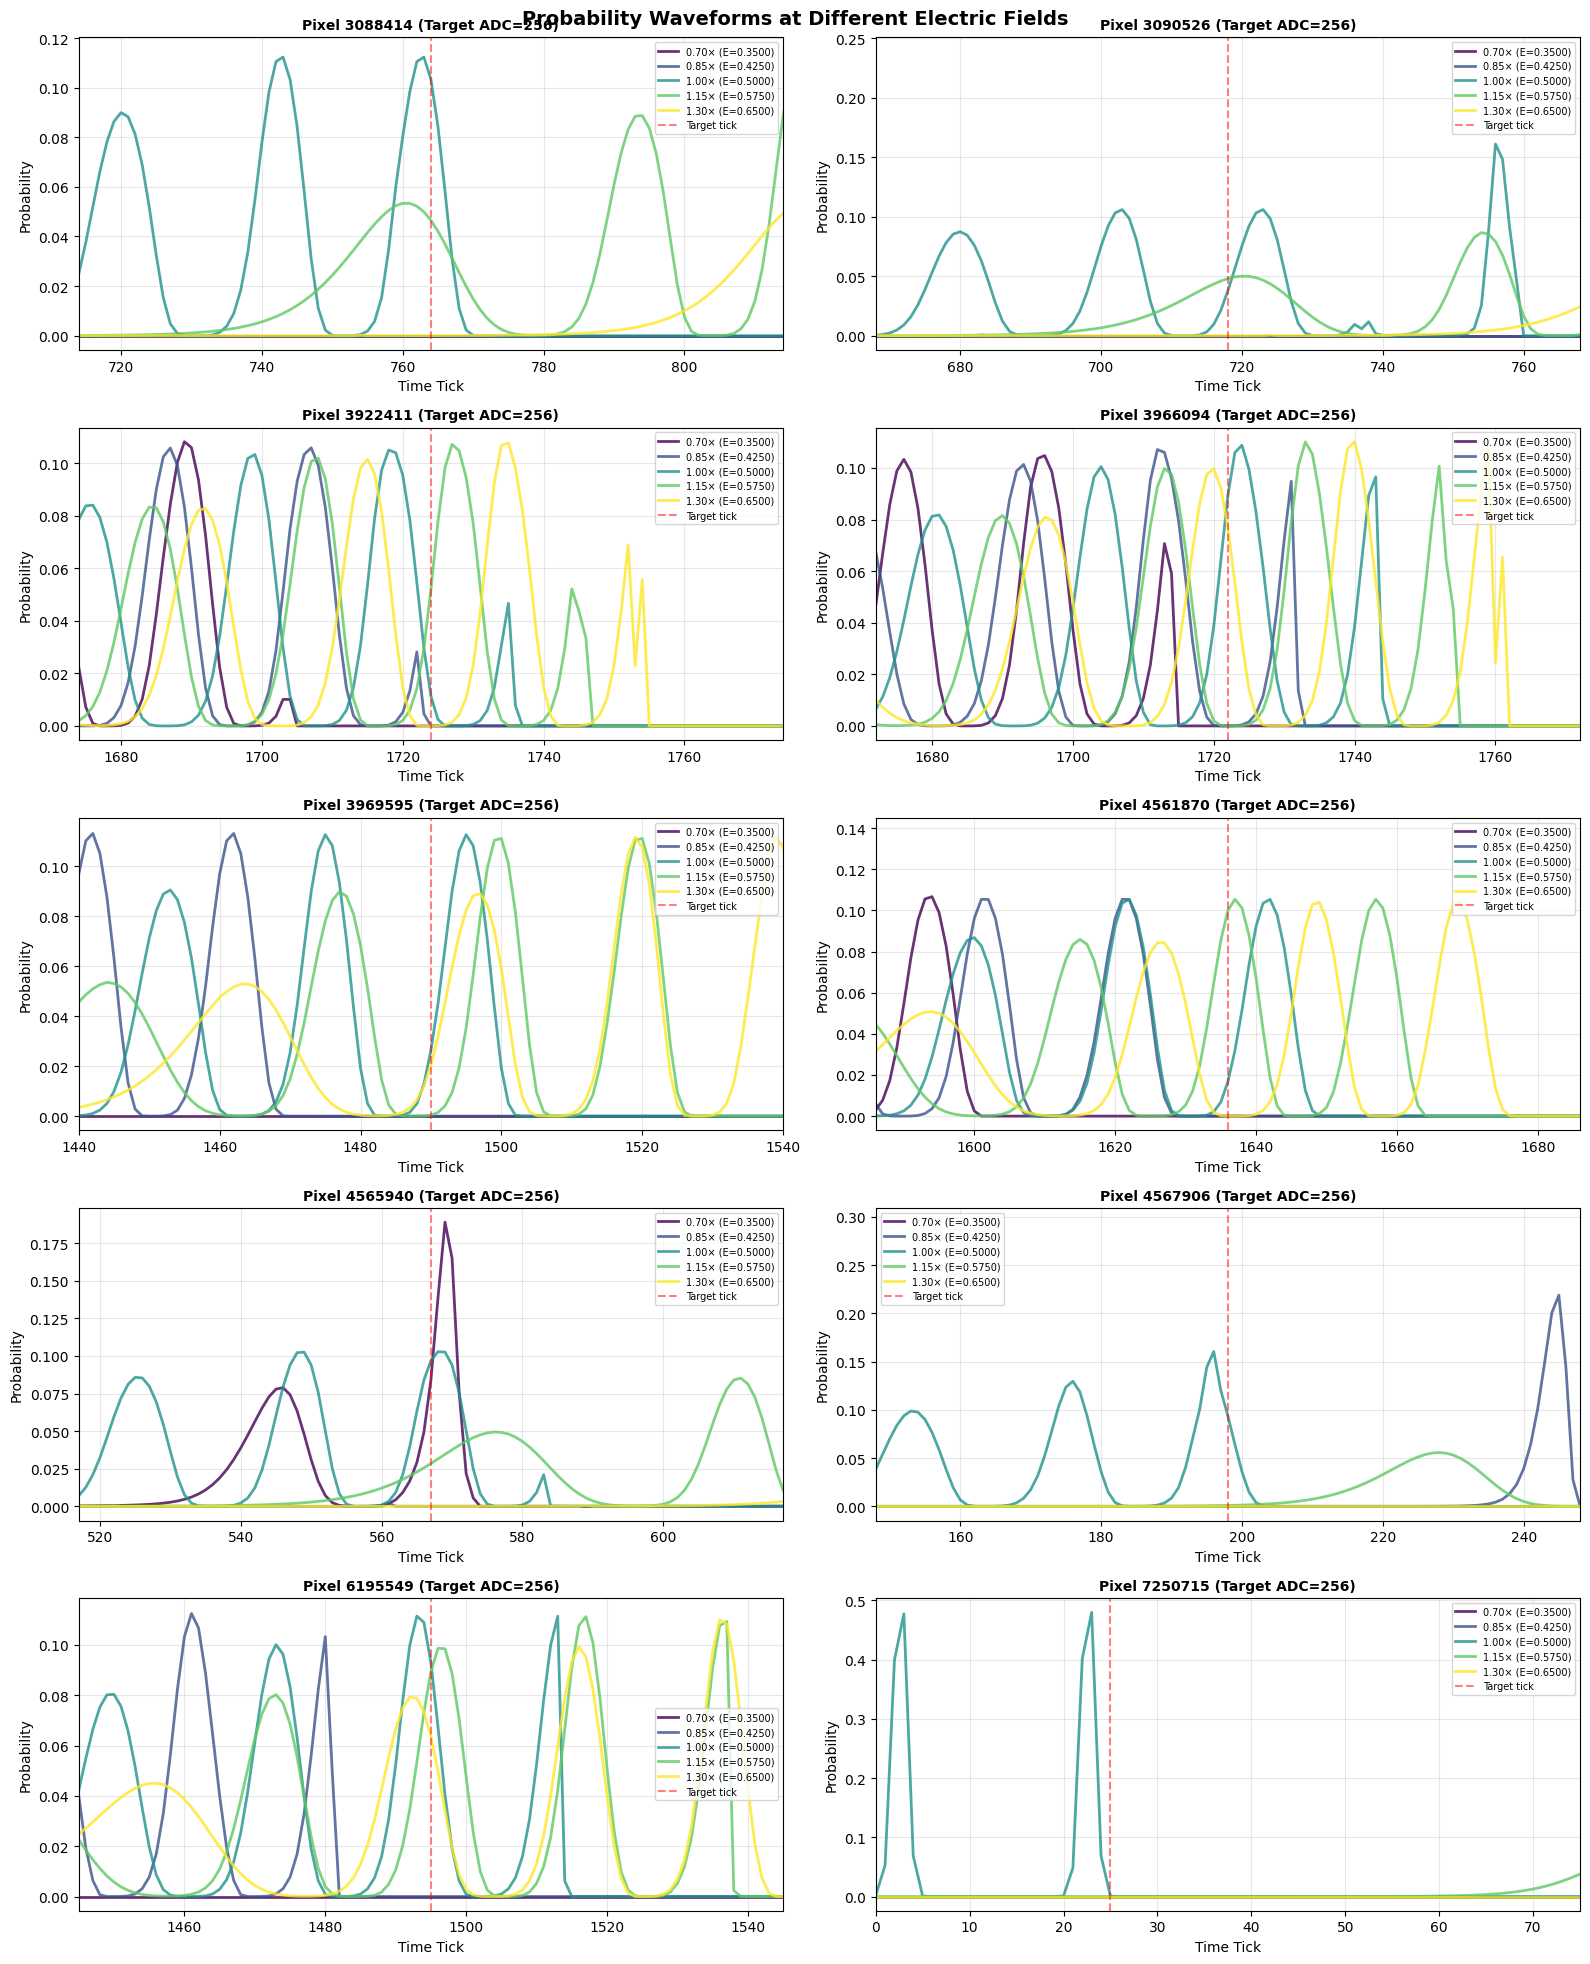

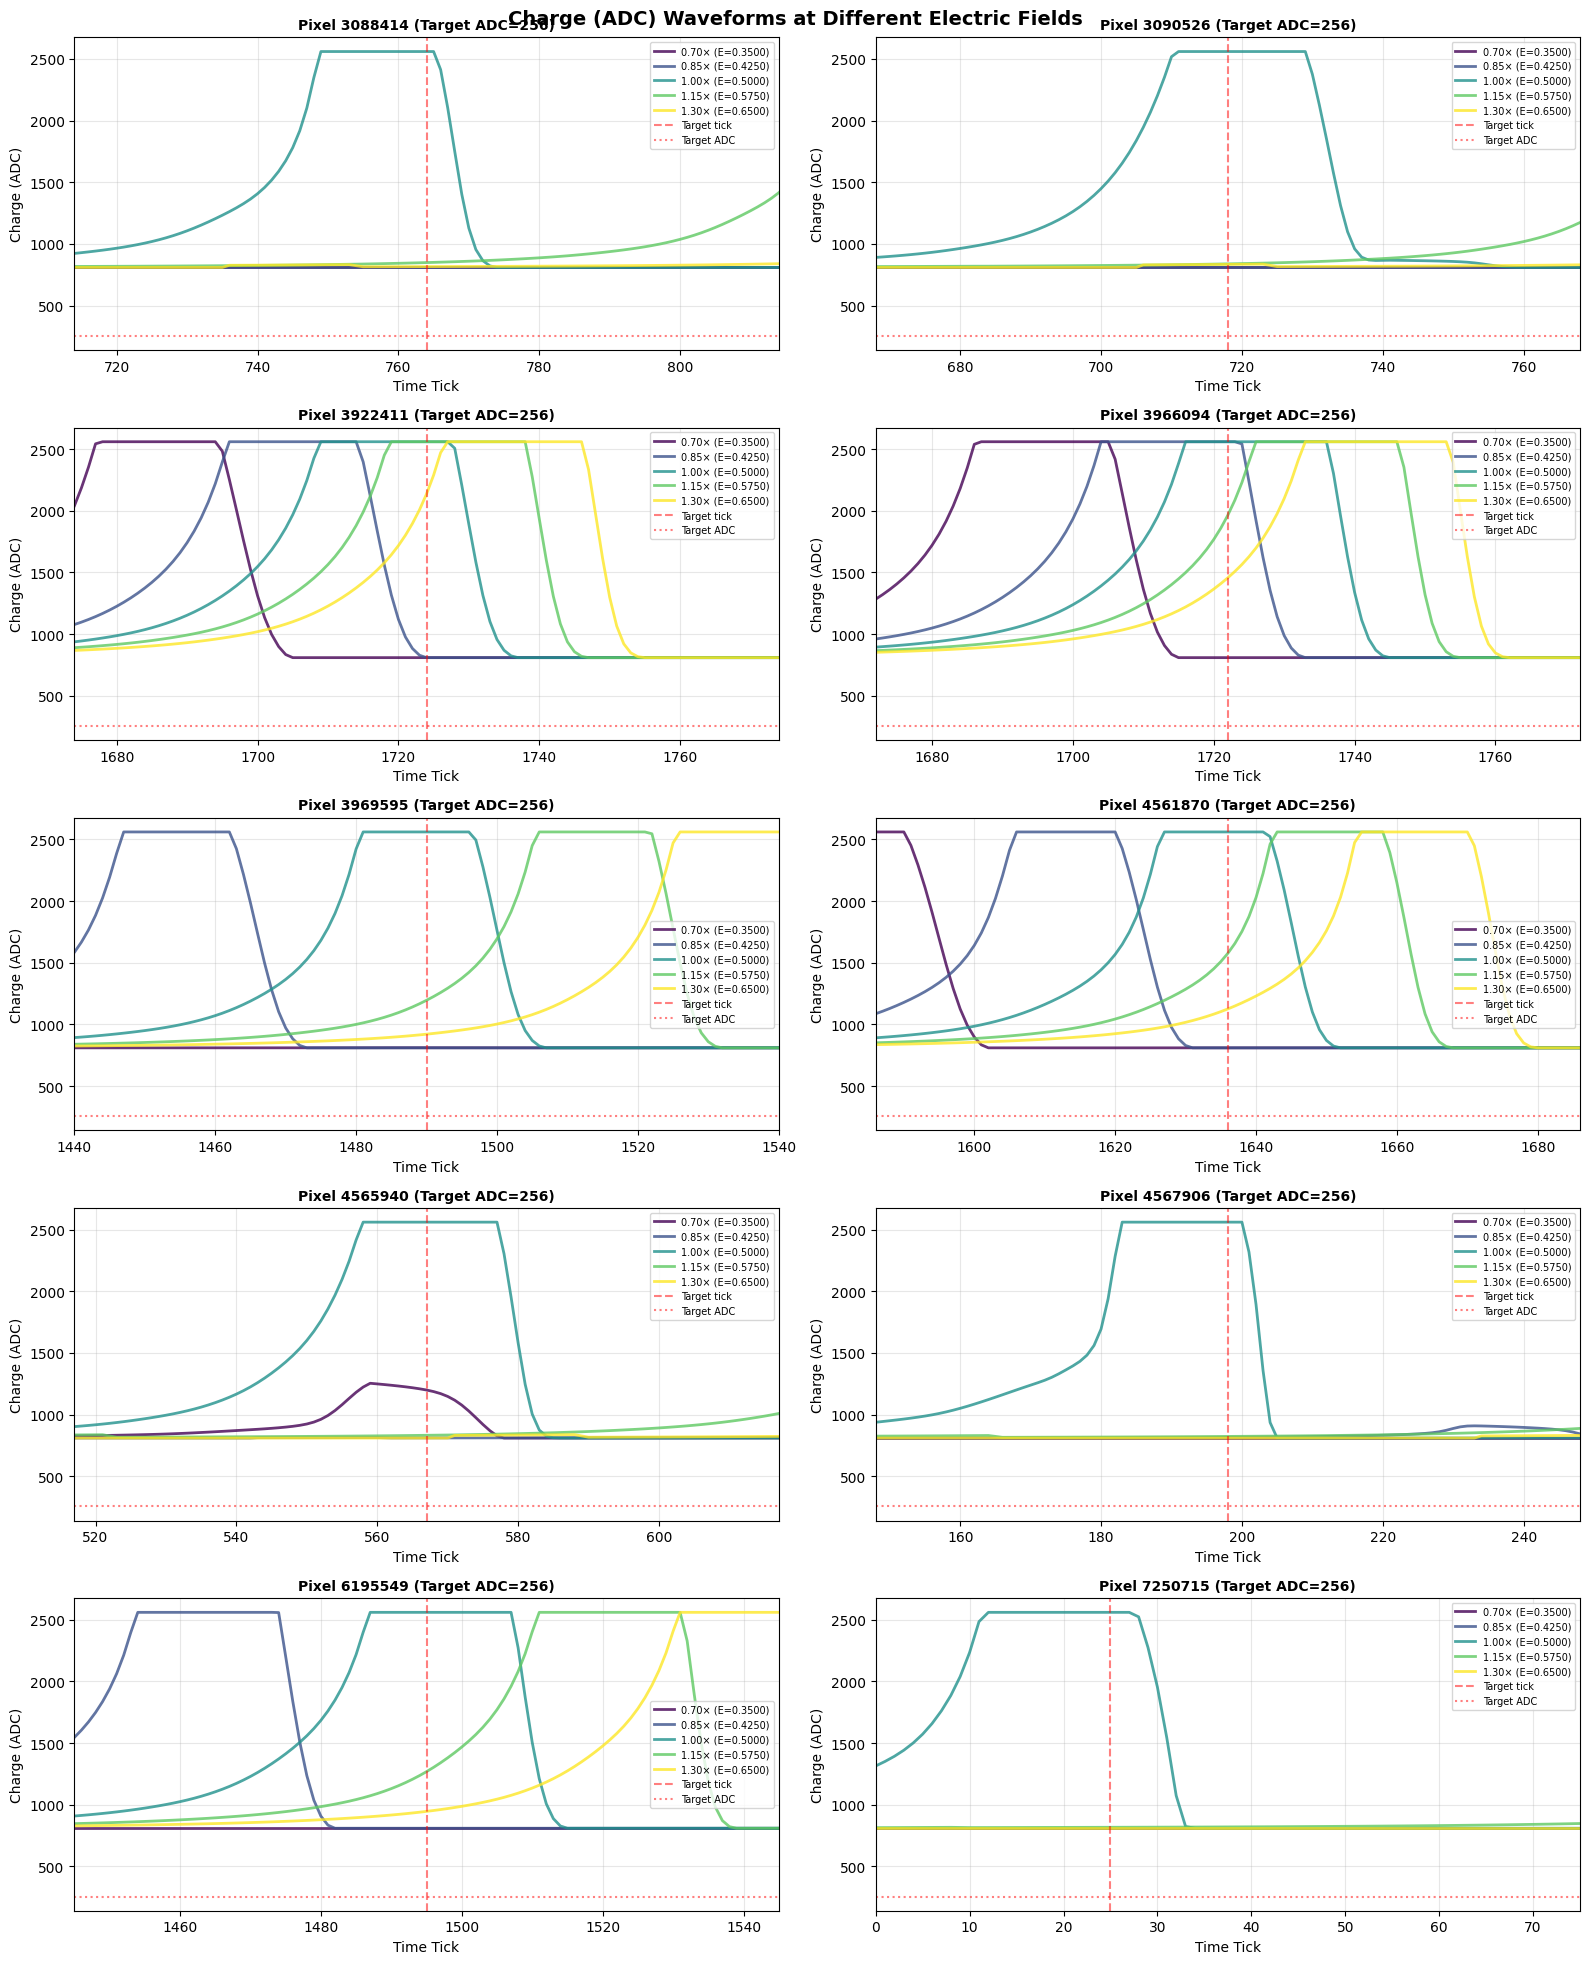


WAVEFORM COMPARISON STATISTICS

Pixel 3088414, Target Tick 764 (Target ADC=256.0):
  Charge at target tick:
    0.70×: 809.51 ADC
    0.85×: 809.51 ADC
    1.00×: 2560.00 ADC
    1.15×: 848.97 ADC
    1.30×: 816.37 ADC
  Total charge (all ticks):
    0.70×: 1669619.50 ADC
    0.85×: 1670231.25 ADC
    1.00×: 1670612.62 ADC
    1.15×: 1670904.88 ADC
    1.30×: 1671137.62 ADC
  Peak charge:
    0.70×: 2560.00 ADC at tick 513
    0.85×: 2560.00 ADC at tick 651
    1.00×: 2560.00 ADC at tick 749
    1.15×: 2560.00 ADC at tick 823
    1.30×: 2560.00 ADC at tick 880

Pixel 3090526, Target Tick 718 (Target ADC=256.0):
  Charge at target tick:
    0.70×: 809.51 ADC
    0.85×: 809.51 ADC
    1.00×: 2560.00 ADC
    1.15×: 838.45 ADC
    1.30×: 834.08 ADC
  Total charge (all ticks):
    0.70×: 1678144.62 ADC
    0.85×: 1678735.38 ADC
    1.00×: 1679123.75 ADC
    1.15×: 1679430.38 ADC
    1.30×: 1679674.00 ADC
  Peak charge:
    0.70×: 2560.00 ADC at tick 468
    0.85×: 2560.00 ADC at tick 610
 

In [22]:
# --- Compare Full Waveforms for Selected Pixels at Different eField Values ---

import matplotlib.pyplot as plt

# Select 5 eField values for comparison
eField_nominal = getattr(current_params, 'eField')
eField_factors = [0.7, 0.85, 1.0, 1.15, 1.3]  # Different field values
eField_values = [eField_nominal * f for f in eField_factors]

print(f"Comparing waveforms for eField values:")
for i, (factor, value) in enumerate(zip(eField_factors, eField_values)):
    print(f"  {i+1}. {value:.6f} ({factor:.2f}× nominal)")

# Storage for waveforms
# Structure: waveforms[eField_idx][pixel_idx] = (ticks_prob, adcs_distrib)
waveforms_prob = []
waveforms_charge = []

# Get predictions for each eField value
print("\nGenerating predictions for different eField values...")
for eField_val in tqdm(eField_values):
    params = current_params.replace(eField=eField_val)
    prediction = pred_strategy.predict(params, tracks, track_fields, rngkey)
    
    # Extract waveforms for selected pixels
    pixel_probs = []
    pixel_charges = []
    
    for pixel_id in selected_pixel_ids:
        # Find pixel index
        pixel_mask = prediction['hit_pixels'] == pixel_id
        pixel_idx = jnp.where(pixel_mask, size=1, fill_value=0)[0][0]
        
        # Extract full waveform (sum over samples dimension)
        # Shape: (n_samples, n_ticks) -> (n_ticks,)
        prob_waveform = jnp.sum(prediction['ticks_prob'][pixel_idx, :, :], axis=0)
        charge_waveform = jnp.sum(prediction['adcs_distrib'][pixel_idx, :, :], axis=0)
        
        pixel_probs.append(np.array(prob_waveform))
        pixel_charges.append(np.array(charge_waveform))
    
    waveforms_prob.append(pixel_probs)
    waveforms_charge.append(pixel_charges)

# Convert to arrays: shape (n_eField, n_pixels, n_ticks)
waveforms_prob = np.array(waveforms_prob)
waveforms_charge = np.array(waveforms_charge)

print(f"\nWaveforms shape: {waveforms_charge.shape}")
print(f"  {len(eField_values)} eField values")
print(f"  {len(selected_pixel_ids)} pixels")
print(f"  {waveforms_charge.shape[2]} time ticks")

# Create time axis
n_ticks = waveforms_charge.shape[2]
time_ticks = np.arange(n_ticks)

# Plot waveforms for each pixel
n_pixels = len(selected_pixel_ids)
n_cols = 2
n_rows = int(np.ceil(n_pixels / n_cols))

# Figure 1: Probability Waveforms
fig1, axes1 = plt.subplots(n_rows, n_cols, figsize=(16, 4*n_rows))
fig1.suptitle('Probability Waveforms at Different Electric Fields', fontsize=14, fontweight='bold')
axes1 = axes1.flatten() if n_pixels > 1 else [axes1]

colors = plt.cm.viridis(np.linspace(0, 1, len(eField_values)))

for pixel_idx in range(n_pixels):
    ax = axes1[pixel_idx]
    
    for eField_idx, (eField_val, factor, color) in enumerate(zip(eField_values, eField_factors, colors)):
        prob_waveform = waveforms_prob[eField_idx, pixel_idx, :]
        ax.plot(time_ticks, prob_waveform, color=color, linewidth=2, 
                label=f'{factor:.2f}× (E={eField_val:.4f})', alpha=0.8)
    
    # Mark the target tick
    target_tick = int(selected_target_ticks[pixel_idx])
    ax.axvline(target_tick, color='red', linestyle='--', alpha=0.5, linewidth=1.5, label='Target tick')
    
    ax.set_xlabel('Time Tick', fontsize=10)
    ax.set_ylabel('Probability', fontsize=10)
    ax.set_title(f'Pixel {selected_pixel_ids[pixel_idx]} (Target ADC={selected_target_adcs[pixel_idx]:.0f})', 
                 fontsize=10, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7, loc='best')
    ax.set_xlim(max(0, target_tick-50), min(n_ticks, target_tick+50))  # Zoom around target tick

for pixel_idx in range(n_pixels, len(axes1)):
    axes1[pixel_idx].axis('off')

fig1.tight_layout()
plt.show()

# Figure 2: Charge Waveforms
fig2, axes2 = plt.subplots(n_rows, n_cols, figsize=(16, 4*n_rows))
fig2.suptitle('Charge (ADC) Waveforms at Different Electric Fields', fontsize=14, fontweight='bold')
axes2 = axes2.flatten() if n_pixels > 1 else [axes2]

for pixel_idx in range(n_pixels):
    ax = axes2[pixel_idx]
    
    for eField_idx, (eField_val, factor, color) in enumerate(zip(eField_values, eField_factors, colors)):
        charge_waveform = waveforms_charge[eField_idx, pixel_idx, :]
        ax.plot(time_ticks, charge_waveform, color=color, linewidth=2, 
                label=f'{factor:.2f}× (E={eField_val:.4f})', alpha=0.8)
    
    # Mark the target tick and charge
    target_tick = int(selected_target_ticks[pixel_idx])
    ax.axvline(target_tick, color='red', linestyle='--', alpha=0.5, linewidth=1.5, label='Target tick')
    ax.axhline(selected_target_adcs[pixel_idx], color='red', linestyle=':', alpha=0.5, 
               linewidth=1.5, label='Target ADC')
    
    ax.set_xlabel('Time Tick', fontsize=10)
    ax.set_ylabel('Charge (ADC)', fontsize=10)
    ax.set_title(f'Pixel {selected_pixel_ids[pixel_idx]} (Target ADC={selected_target_adcs[pixel_idx]:.0f})', 
                 fontsize=10, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7, loc='best')
    ax.set_xlim(max(0, target_tick-50), min(n_ticks, target_tick+50))  # Zoom around target tick

for pixel_idx in range(n_pixels, len(axes2)):
    axes2[pixel_idx].axis('off')

fig2.tight_layout()
plt.show()

# Print statistics about waveform changes
print("\n" + "="*80)
print("WAVEFORM COMPARISON STATISTICS")
print("="*80)

for pixel_idx in range(n_pixels):
    pixel_id = selected_pixel_ids[pixel_idx]
    target_tick = int(selected_target_ticks[pixel_idx])
    target_adc = selected_target_adcs[pixel_idx]
    
    print(f"\nPixel {pixel_id}, Target Tick {target_tick} (Target ADC={target_adc:.1f}):")
    
    # Compare charge at target tick across eField values
    charges_at_target_tick = waveforms_charge[:, pixel_idx, target_tick]
    print(f"  Charge at target tick:")
    for eField_idx, (factor, charge) in enumerate(zip(eField_factors, charges_at_target_tick)):
        print(f"    {factor:.2f}×: {charge:.2f} ADC")
    
    # Total charge in waveform
    total_charges = np.sum(waveforms_charge[:, pixel_idx, :], axis=1)
    print(f"  Total charge (all ticks):")
    for eField_idx, (factor, total_charge) in enumerate(zip(eField_factors, total_charges)):
        print(f"    {factor:.2f}×: {total_charge:.2f} ADC")
    
    # Peak charge and its location
    print(f"  Peak charge:")
    for eField_idx, factor in enumerate(eField_factors):
        charge_waveform = waveforms_charge[eField_idx, pixel_idx, :]
        peak_charge = np.max(charge_waveform)
        peak_tick = np.argmax(charge_waveform)
        print(f"    {factor:.2f}×: {peak_charge:.2f} ADC at tick {peak_tick}")

print("\n" + "="*80)

# Computing Occurrence Indices in JAX

How to compute the occurrence index (0, 1, 2, ...) for each ID in an array using JAX operations.

In [57]:
import jax.numpy as jnp

def compute_occurrence_indices(ids):
    """
    Compute occurrence index (0, 1, 2, ...) for each ID in the array.
    
    For sorted IDs, this counts how many times each ID has appeared so far.
    Example: [100, 100, 100, 200, 200, 300] -> [0, 1, 2, 0, 1, 0]
    
    Args:
        ids: Array of IDs (should be sorted for meaningful results)
    
    Returns:
        occurrence_indices: Array where each element is its occurrence count within its ID group
    """
    # Detect where ID changes (boundaries between groups)
    id_changes = jnp.concatenate([
        jnp.array([True]),  # First element is always a new group
        ids[1:] != ids[:-1]  # Compare consecutive elements
    ])
    
    # Cumulative sum creates increasing counter: [1, 2, 3, 4, 5, ...]
    cumsum = jnp.cumsum(jnp.ones_like(ids, dtype=jnp.int32))
    
    # At each ID boundary, record the cumsum value to use as reset point
    reset_values = jnp.where(id_changes, cumsum, 0)
    
    # Propagate the reset values forward (each group gets its starting cumsum)
    reset_at_boundary = jnp.maximum.accumulate(reset_values)
    
    # Subtract to get 0-based index within each group
    occurrence_indices = cumsum - reset_at_boundary
    
    return occurrence_indices


# Test with your example (assuming sorted input)
test_ids = jnp.array([838720, 838720, 838860, 839001, 839002])
result = compute_occurrence_indices(test_ids)

print("Test 1: Sorted IDs")
print(f"Input:  {test_ids}")
print(f"Output: {result}")
print()

# More complex example
test_ids2 = jnp.array([100, 100, 100, 200, 200, 300])
result2 = compute_occurrence_indices(test_ids2)

print("Test 2: Multiple occurrences")
print(f"Input:  {test_ids2}")
print(f"Output: {result2}")
print()

# If IDs are NOT sorted, you need to sort first
test_ids_unsorted = jnp.array([200, 100, 200, 100, 100])
sort_indices = jnp.argsort(test_ids_unsorted)
sorted_ids = test_ids_unsorted[sort_indices]
sorted_result = compute_occurrence_indices(sorted_ids)

# Unsort to get back to original order
inverse_sort = jnp.argsort(sort_indices)
final_result = sorted_result[inverse_sort]

print("Test 3: Unsorted IDs")
print(f"Original input:  {test_ids_unsorted}")
print(f"Sorted input:    {sorted_ids}")
print(f"Sorted output:   {sorted_result}")
print(f"Unsorted output: {final_result}")
print()

# Verify: for each ID, indices should be 0, 1, 2, ...
print("Verification:")
print("  ID 100 appears at positions with indices:", final_result[test_ids_unsorted == 100])
print("  ID 200 appears at positions with indices:", final_result[test_ids_unsorted == 200])

Test 1: Sorted IDs
Input:  [838720 838720 838860 839001 839002]
Output: [0 1 0 0 0]

Test 2: Multiple occurrences
Input:  [100 100 100 200 200 300]
Output: [0 1 2 0 1 0]

Test 3: Unsorted IDs
Original input:  [200 100 200 100 100]
Sorted input:    [100 100 100 200 200]
Sorted output:   [0 1 2 0 1]
Unsorted output: [0 0 1 1 2]

Verification:
  ID 100 appears at positions with indices: [0 1 2]
  ID 200 appears at positions with indices: [0 1]


## Potential NaN Sources in simulate_signals (lines 236-239)

The code computing neighbor corrections:
```python
base_curr_neigh = (currents_idx_neigh[:, 0] * Ny + currents_idx_neigh[:, 1]) * Nt
diff_neigh = (response_cum[0].take(base_curr_neigh + Nt - sig_len) - 
              response_cum[0].take(base_curr_neigh + neigh_cathode_ticks)) * neigh_charge
idx_corr_neigh = jnp.where((neigh_start_ticks <= 0) | (neigh_start_ticks >= Nticks - 1), 0, neigh_start_ticks) + pix_renumbering_neigh * Nticks
```

### Possible NaN causes:

**1. Out-of-bounds indexing in `.take()`:**
   - If `base_curr_neigh + neigh_cathode_ticks` < 0 or >= `response_cum[0].size`
   - If `neigh_cathode_ticks` is negative (drift time < 0)
   - If `currents_idx_neigh` contains values >= Ny or Nx

**2. Invalid `currents_idx_neigh` values:**
   - If computed absolute value operation produces values outside [0, Ny) or [0, Nx)
   - Check: `currents_idx_neigh = jnp.abs(bins_pitches[:, :, None, None] % ... - ...).astype(int)`

**3. NaN in `neigh_charge`:**
   - If `nelectrons_neigh` contains NaN (upstream issue)
   - If `neigh_charge = jnp.take(nelectrons_neigh, elec_ids)` gets invalid indices

**4. Division by zero in drift calculation:**
   - If `params.t_sampling` is zero → `neigh_cathode_ticks = (neigh_t0 / params.t_sampling).astype(int)` → inf

**5. Negative or extreme values:**
   - If `t0_neigh` is negative → negative cathode ticks → negative index
   - If electrons are placed outside detector volume

### Recommended fixes:

```python
# Add bounds checking and clipping
neigh_cathode_ticks_safe = jnp.clip(neigh_cathode_ticks, 0, Nt - sig_len - 1)

# Validate currents_idx_neigh
currents_idx_neigh_safe = jnp.clip(currents_idx_neigh, 0, jnp.array([Nx-1, Ny-1]))

# Recompute base index with safe values
base_curr_neigh = (currents_idx_neigh_safe[:, 0] * Ny + currents_idx_neigh_safe[:, 1]) * Nt

# Safe indexing with clipping
idx1 = jnp.clip(base_curr_neigh + Nt - sig_len, 0, response_cum[0].size - 1)
idx2 = jnp.clip(base_curr_neigh + neigh_cathode_ticks_safe, 0, response_cum[0].size - 1)

diff_neigh = (response_cum[0].take(idx1) - response_cum[0].take(idx2)) * neigh_charge

# Also check for NaN in inputs
neigh_charge_safe = jnp.where(jnp.isnan(neigh_charge), 0.0, neigh_charge)
```

In [64]:
# Debug NaN in simulate_signals neighbor computation
jax.config.update("jax_debug_nans", True)
# Run a simulation and check for NaNs
p = current_params.replace(**{'eField': 0.125})
pred = pred_strategy.predict(p, tracks, track_fields, rngkey)

# Check if NaN exists in the output
print("Checking for NaNs in prediction:")
print(f"  ticks_prob has NaN: {jnp.any(jnp.isnan(pred['ticks_prob']))}")
print(f"  adcs_distrib has NaN: {jnp.any(jnp.isnan(pred['adcs_distrib']))}")

if jnp.any(jnp.isnan(pred['ticks_prob'])) or jnp.any(jnp.isnan(pred['adcs_distrib'])):
    print("\n⚠ NaN detected! Investigating source...")
    
    # Check waveforms before FEE simulation
    from larndsim.sim_jax import simulate_wfs
    wfs, unique_pixels = simulate_wfs(p, response, tracks, track_fields)
    
    print(f"\nWaveforms check:")
    print(f"  wfs has NaN: {jnp.any(jnp.isnan(wfs))}")
    print(f"  wfs min/max: {jnp.min(wfs):.2e} / {jnp.max(wfs):.2e}")
    
    if jnp.any(jnp.isnan(wfs)):
        nan_pixels = jnp.where(jnp.any(jnp.isnan(wfs), axis=1))[0]
        print(f"  Pixels with NaN: {nan_pixels[:10]}...")  # Show first 10
        
        # Check what went wrong
        print(f"\nDebugging first NaN pixel:")
        nan_pix_idx = nan_pixels[0]
        nan_wf = wfs[nan_pix_idx]
        print(f"  Pixel index: {nan_pix_idx}")
        print(f"  NaN positions: {jnp.where(jnp.isnan(nan_wf))[0]}")
        
    # Most likely causes:
    print(f"\nLikely causes:")
    print(f"1. Check params.t_sampling: {p.t_sampling} (should be > 0)")
    print(f"2. Check drift times are positive")
    print(f"3. Check currents_idx_neigh bounds")
    print(f"4. Check for electrons outside detector volume")
else:
    print("\n✓ No NaN detected in this run")

: 

: 

: 

In [63]:
# --- Deep Debug: Inspect the exact values causing NaN in simulate_signals ---

import jax
from larndsim.sim_jax import simulate_drift_new

# Disable NaN checking temporarily to gather data
with jax.debug_nans(False):
    # Run simulation up to the point of error
    p = current_params.replace(**{'eField': 0.125})
    
    main_pixels, pixels, nelectrons, t0_after_diff, long_diff, currents_idx, pIDs_neigh, currents_idx_neigh, nelectrons_neigh, t0_neigh = simulate_drift_new(
        p, tracks, track_fields
    )
    
    # Get unique pixels
    unique_pixels = jnp.unique(main_pixels.ravel())
    from larndsim.sim_jax import pad_size
    padded_unique = pad_size(unique_pixels.shape[0], "unique_pixels", 0.2)
    unique_pixels = jnp.sort(jnp.pad(unique_pixels, (0, padded_unique - unique_pixels.shape[0]), mode='constant', constant_values=-1))
    
    pix_renumbering_neigh = jnp.searchsorted(unique_pixels, pIDs_neigh.ravel(), method='sort')
    mask = (pix_renumbering_neigh < unique_pixels.size) & (unique_pixels[pix_renumbering_neigh] == pIDs_neigh.ravel())
    pix_renumbering_neigh = pix_renumbering_neigh.at[~mask].set(0)
    
    # Now compute the values that go into the problematic line
    Ntemplates, Nx, Ny, Nt = response.shape
    sig_len = p.signal_length
    Nticks = int(p.time_interval[1] / p.t_sampling) + 1
    
    # Neighbor processing
    npix_neigh = (2 * p.number_pix_neighbors + 1)**2
    elec_ids_neigh = jnp.repeat(jnp.arange(nelectrons_neigh.shape[0]), npix_neigh)
    
    neigh_charge = jnp.take(nelectrons_neigh, elec_ids_neigh)
    neigh_t0 = jnp.take(t0_neigh, elec_ids_neigh)
    neigh_cathode_ticks = (neigh_t0 / p.t_sampling).astype(int)
    
    base_curr_neigh = (currents_idx_neigh[:, 0] * Ny + currents_idx_neigh[:, 1]) * Nt
    
    # The problematic indices
    idx1 = base_curr_neigh + Nt - sig_len
    idx2 = base_curr_neigh + neigh_cathode_ticks
    
    response_cum = jnp.cumsum(response, axis=-1)
    max_valid_idx = response_cum[0].size - 1

print("="*80)
print("NEIGHBOR INDEX ANALYSIS")
print("="*80)

print(f"\nResponse cumsum shape: {response_cum[0].shape}")
print(f"Response cumsum size: {response_cum[0].size}")
print(f"Max valid index: {max_valid_idx}")

print(f"\nNeighbor cathode ticks stats:")
print(f"  Min: {jnp.min(neigh_cathode_ticks)}")
print(f"  Max: {jnp.max(neigh_cathode_ticks)}")
print(f"  Any negative: {jnp.any(neigh_cathode_ticks < 0)}")

print(f"\nBase current neighbor indices stats:")
print(f"  Min: {jnp.min(base_curr_neigh)}")
print(f"  Max: {jnp.max(base_curr_neigh)}")

print(f"\nIndex 1 (base_curr_neigh + Nt - sig_len):")
print(f"  Min: {jnp.min(idx1)}")
print(f"  Max: {jnp.max(idx1)}")
print(f"  Out of bounds: {jnp.sum((idx1 < 0) | (idx1 > max_valid_idx))}")

print(f"\nIndex 2 (base_curr_neigh + neigh_cathode_ticks):")
print(f"  Min: {jnp.min(idx2)}")
print(f"  Max: {jnp.max(idx2)}")
print(f"  Out of bounds: {jnp.sum((idx2 < 0) | (idx2 > max_valid_idx))}")
print(f"  Any negative: {jnp.any(idx2 < 0)}")

print(f"\ncurrents_idx_neigh stats:")
print(f"  [:, 0] min/max: {jnp.min(currents_idx_neigh[:, 0])} / {jnp.max(currents_idx_neigh[:, 0])}")
print(f"  [:, 1] min/max: {jnp.min(currents_idx_neigh[:, 1])} / {jnp.max(currents_idx_neigh[:, 1])}")
print(f"  Valid range: [0, {Nx-1}] x [0, {Ny-1}]")
print(f"  Out of bounds X: {jnp.sum((currents_idx_neigh[:, 0] < 0) | (currents_idx_neigh[:, 0] >= Nx))}")
print(f"  Out of bounds Y: {jnp.sum((currents_idx_neigh[:, 1] < 0) | (currents_idx_neigh[:, 1] >= Ny))}")

if jnp.any(idx2 < 0):
    print(f"\n⚠ FOUND NEGATIVE INDICES!")
    neg_mask = idx2 < 0
    print(f"  Number of negative indices: {jnp.sum(neg_mask)}")
    print(f"  Corresponding neigh_cathode_ticks: {neigh_cathode_ticks[neg_mask][:5]}")
    print(f"  Corresponding neigh_t0: {neigh_t0[neg_mask][:5]}")
    print(f"  Corresponding base_curr_neigh: {base_curr_neigh[neg_mask][:5]}")

if jnp.any((idx1 > max_valid_idx) | (idx2 > max_valid_idx)):
    print(f"\n⚠ FOUND OUT-OF-BOUNDS INDICES!")
    oob_mask = (idx1 > max_valid_idx) | (idx2 > max_valid_idx)
    print(f"  Number out of bounds: {jnp.sum(oob_mask)}")

print("\n" + "="*80)

NEIGHBOR INDEX ANALYSIS

Response cumsum shape: (45, 45, 1891)
Response cumsum size: 3829275
Max valid index: 3829274

Neighbor cathode ticks stats:
  Min: 2
  Max: 4626
  Any negative: False

Base current neighbor indices stats:
  Min: 1891
  Max: 3827384

Index 1 (base_curr_neigh + Nt - sig_len):
  Min: 3632
  Max: 3829125
  Out of bounds: 0

Index 2 (base_curr_neigh + neigh_cathode_ticks):
  Min: 3826
  Max: 3830435
  Out of bounds: 5
  Any negative: False

currents_idx_neigh stats:
  [:, 0] min/max: 0 / 44
  [:, 1] min/max: 0 / 44
  Valid range: [0, 44] x [0, 44]
  Out of bounds X: 0
  Out of bounds Y: 0

⚠ FOUND OUT-OF-BOUNDS INDICES!
  Number out of bounds: 5



## Solution: Clip neigh_cathode_ticks to Valid Range

**The Problem:**
- `neigh_cathode_ticks` can exceed `Nt` (1891) - max observed is 4626
- This makes `idx2 = base_curr_neigh + neigh_cathode_ticks` exceed the response_cum array size
- 5 out-of-bounds accesses cause NaN when using `.take()`

**The Fix:**
Clip `neigh_cathode_ticks` to `[0, Nt-1]` before using it for indexing.

**Location:** `/sdf/home/p/pgranger/.local/lib/python3.10/site-packages/larndsim/sim_jax.py` line ~233

**Change:**
```python
# Before (line 233):
neigh_cathode_ticks = (neigh_t0 / params.t_sampling).astype(int)

# After:
neigh_cathode_ticks = jnp.clip((neigh_t0 / params.t_sampling).astype(int), 0, Nt - 1)
```

This ensures electrons that drift beyond the waveform window are handled gracefully by using the last valid time tick.

In [7]:
# --- Detailed Debug: Check ALL index calculations in simulate_signals ---

import jax
from larndsim.sim_jax import simulate_drift_new
import importlib
import sys

# Force reload of the module to get the updated code
if 'larndsim.sim_jax' in sys.modules:
    importlib.reload(sys.modules['larndsim.sim_jax'])

from larndsim.sim_jax import simulate_drift_new, pad_size

with jax.debug_nans(False):
    p = current_params.replace(**{'eField': 0.125})
    
    main_pixels, pixels, nelectrons, t0_after_diff, long_diff, currents_idx, pIDs_neigh, currents_idx_neigh, nelectrons_neigh, t0_neigh = simulate_drift_new(
        p, tracks, track_fields
    )
    
    unique_pixels = jnp.unique(main_pixels.ravel())
    padded_unique = pad_size(unique_pixels.shape[0], "unique_pixels", 0.2)
    unique_pixels = jnp.sort(jnp.pad(unique_pixels, (0, padded_unique - unique_pixels.shape[0]), mode='constant', constant_values=-1))
    
    pix_renumbering_neigh = jnp.searchsorted(unique_pixels, pIDs_neigh.ravel(), method='sort')
    mask = (pix_renumbering_neigh < unique_pixels.size) & (unique_pixels[pix_renumbering_neigh] == pIDs_neigh.ravel())
    pix_renumbering_neigh = pix_renumbering_neigh.at[~mask].set(0)
    
    # Simulate the calculations inside simulate_signals
    Ntemplates, Nx, Ny, Nt = response.shape
    sig_len = p.signal_length
    Nticks = int(p.time_interval[1] / p.t_sampling) + 1
    
    print("="*80)
    print("COMPREHENSIVE INDEX BOUNDS CHECK")
    print("="*80)
    
    print(f"\nArray dimensions:")
    print(f"  response shape: {response.shape}")
    print(f"  Nt (time samples in template): {Nt}")
    print(f"  Nticks (waveform length): {Nticks}")
    print(f"  sig_len: {sig_len}")
    print(f"  Nx, Ny: {Nx}, {Ny}")
    
    # Main pixel calculations
    print(f"\n--- MAIN PIXEL INDICES ---")
    pix_renum = jnp.searchsorted(unique_pixels, pixels.ravel(), method='sort')
    
    float_ticks_main = t0_after_diff / p.t_sampling
    cathode_ticks_main_raw = jnp.floor(float_ticks_main).astype(int)
    cathode_ticks_main = jnp.clip(cathode_ticks_main_raw, 0, Nt - 1)
    frac_main = float_ticks_main - cathode_ticks_main
    
    print(f"  cathode_ticks_main (raw) - min/max: {jnp.min(cathode_ticks_main_raw)} / {jnp.max(cathode_ticks_main_raw)}")
    print(f"  cathode_ticks_main (clipped) - min/max: {jnp.min(cathode_ticks_main)} / {jnp.max(cathode_ticks_main)}")
    print(f"  Clipping prevented {jnp.sum(cathode_ticks_main_raw >= Nt)} out-of-bounds values")
    
    # Check template interpolation indices
    template_vals = p.long_diff_template
    idx = jnp.clip(jnp.searchsorted(template_vals, long_diff), 1, template_vals.shape[0] - 2)
    
    base_curr = (currents_idx[:, 0] * Ny + currents_idx[:, 1]) * Nt
    
    # All the indices used for main pixel access
    idx1_main = idx * Nx * Ny * Nt + base_curr + cathode_ticks_main
    idx2_main = idx * Nx * Ny * Nt + base_curr + jnp.clip(cathode_ticks_main + 1, 0, Nt - 1)
    idx3_main = idx * Nx * Ny * Nt + base_curr + Nt - sig_len
    idx4_main = (idx - 1) * Nx * Ny * Nt + base_curr
    idx5_main = (idx + 1) * Nx * Ny * Nt + base_curr
    
    response_cum = jnp.cumsum(response, axis=-1)
    max_valid_idx = response_cum.size - 1
    
    print(f"\n  Main pixel cumsum indices (max valid: {max_valid_idx}):")
    print(f"    idx1 (base + cathode_ticks): {jnp.min(idx1_main)} - {jnp.max(idx1_main)}, OOB: {jnp.sum((idx1_main < 0) | (idx1_main > max_valid_idx))}")
    print(f"    idx2 (base + cathode_ticks+1): {jnp.min(idx2_main)} - {jnp.max(idx2_main)}, OOB: {jnp.sum((idx2_main < 0) | (idx2_main > max_valid_idx))}")
    print(f"    idx3 (base + Nt-sig_len): {jnp.min(idx3_main)} - {jnp.max(idx3_main)}, OOB: {jnp.sum((idx3_main < 0) | (idx3_main > max_valid_idx))}")
    
    # Neighbor pixel calculations
    print(f"\n--- NEIGHBOR PIXEL INDICES ---")
    npix_neigh = (2 * p.number_pix_neighbors + 1)**2
    elec_ids_neigh = jnp.repeat(jnp.arange(nelectrons_neigh.shape[0]), npix_neigh)
    
    neigh_charge = jnp.take(nelectrons_neigh, elec_ids_neigh)
    neigh_t0 = jnp.take(t0_neigh, elec_ids_neigh)
    
    float_ticks_neigh = neigh_t0 / p.t_sampling
    cathode_ticks_neigh_raw = jnp.floor(float_ticks_neigh).astype(int)
    cathode_ticks_neigh = jnp.clip(cathode_ticks_neigh_raw, 0, Nt - 1)
    frac_neigh = float_ticks_neigh - cathode_ticks_neigh
    
    print(f"  cathode_ticks_neigh (raw) - min/max: {jnp.min(cathode_ticks_neigh_raw)} / {jnp.max(cathode_ticks_neigh_raw)}")
    print(f"  cathode_ticks_neigh (clipped) - min/max: {jnp.min(cathode_ticks_neigh)} / {jnp.max(cathode_ticks_neigh)}")
    print(f"  Clipping prevented {jnp.sum(cathode_ticks_neigh_raw >= Nt)} out-of-bounds values")
    
    base_curr_neigh = (currents_idx_neigh[:, 0] * Ny + currents_idx_neigh[:, 1]) * Nt
    
    idx1_neigh = base_curr_neigh + cathode_ticks_neigh
    idx2_neigh = base_curr_neigh + jnp.clip(cathode_ticks_neigh + 1, 0, Nt - 1)
    idx3_neigh = base_curr_neigh + Nt - sig_len
    
    print(f"\n  Neighbor cumsum indices (template [0], max: {response_cum[0].size - 1}):")
    print(f"    idx1 (base + cathode_ticks): {jnp.min(idx1_neigh)} - {jnp.max(idx1_neigh)}, OOB: {jnp.sum((idx1_neigh < 0) | (idx1_neigh > response_cum[0].size - 1))}")
    print(f"    idx2 (base + cathode_ticks+1): {jnp.min(idx2_neigh)} - {jnp.max(idx2_neigh)}, OOB: {jnp.sum((idx2_neigh < 0) | (idx2_neigh > response_cum[0].size - 1))}")
    print(f"    idx3 (base + Nt-sig_len): {jnp.min(idx3_neigh)} - {jnp.max(idx3_neigh)}, OOB: {jnp.sum((idx3_neigh < 0) | (idx3_neigh > response_cum[0].size - 1))}")
    
    # Check for NaN in intermediate values
    print(f"\n--- NaN CHECKS ---")
    print(f"  neigh_charge has NaN: {jnp.any(jnp.isnan(neigh_charge))}")
    print(f"  neigh_t0 has NaN: {jnp.any(jnp.isnan(neigh_t0))}")
    print(f"  frac_neigh has NaN: {jnp.any(jnp.isnan(frac_neigh))}")
    print(f"  frac_main has NaN: {jnp.any(jnp.isnan(frac_main))}")
    
    # Check base_curr_neigh calculation
    print(f"\n--- BASE CURRENT NEIGH CALCULATION ---")
    print(f"  currents_idx_neigh[:, 0] range: {jnp.min(currents_idx_neigh[:, 0])} - {jnp.max(currents_idx_neigh[:, 0])}")
    print(f"  currents_idx_neigh[:, 1] range: {jnp.min(currents_idx_neigh[:, 1])} - {jnp.max(currents_idx_neigh[:, 1])}")
    print(f"  base_curr_neigh range: {jnp.min(base_curr_neigh)} - {jnp.max(base_curr_neigh)}")
    print(f"  Expected max base_curr: {(Nx-1) * Ny * Nt + (Ny-1) * Nt} = {44 * 45 * 1891 + 44 * 1891}")
    
    if jnp.any((idx1_neigh < 0) | (idx1_neigh > response_cum[0].size - 1)):
        oob_mask = (idx1_neigh < 0) | (idx1_neigh > response_cum[0].size - 1)
        print(f"\n⚠ PROBLEM: idx1_neigh has {jnp.sum(oob_mask)} out-of-bounds values!")
        print(f"  OOB indices: {idx1_neigh[oob_mask][:10]}")
        print(f"  Corresponding base_curr_neigh: {base_curr_neigh[oob_mask][:10]}")
        print(f"  Corresponding cathode_ticks_neigh: {cathode_ticks_neigh[oob_mask][:10]}")
        print(f"  Corresponding currents_idx_neigh: {currents_idx_neigh[oob_mask][:10]}")

print("="*80)

COMPREHENSIVE INDEX BOUNDS CHECK

Array dimensions:
  response shape: (100, 45, 45, 1891)
  Nt (time samples in template): 1891
  Nticks (waveform length): 2001
  sig_len: 150
  Nx, Ny: 45, 45

--- MAIN PIXEL INDICES ---
  cathode_ticks_main (raw) - min/max: 2 / 4626
  cathode_ticks_main (clipped) - min/max: 2 / 1890
  Clipping prevented 1900 out-of-bounds values

  Main pixel cumsum indices (max valid: 382927499):
    idx1 (base + cathode_ticks): 61442371 - 367958347, OOB: 0
    idx2 (base + cathode_ticks+1): 61442371 - 367958348, OOB: 0
    idx3 (base + Nt-sig_len): 61442222 - 367960085, OOB: 0

--- NEIGHBOR PIXEL INDICES ---
  cathode_ticks_neigh (raw) - min/max: 2 / 4626
  cathode_ticks_neigh (clipped) - min/max: 2 / 1890
  Clipping prevented 6156 out-of-bounds values

  Neighbor cumsum indices (template [0], max: 3829274):
    idx1 (base + cathode_ticks): 3781 - 3829274, OOB: 0
    idx2 (base + cathode_ticks+1): 3781 - 3829274, OOB: 0
    idx3 (base + Nt-sig_len): 3632 - 3829125, 

In [13]:
# --- Now try to run through simulate_wfs (with module reload) ---
import importlib
import sys
if 'larndsim.sim_jax' in sys.modules:
    importlib.reload(sys.modules['larndsim.sim_jax'])

from larndsim.sim_jax import simulate_wfs

print("Attempting to run simulate_wfs with jax.debug_nans(True)...")

try:
    with jax.debug_nans(True):
        p = current_params.replace(**{'eField': 0.125})
        
        wfs, unique_pixels = simulate_wfs(p, response, tracks, track_fields)
        
        print("✓ simulate_wfs completed successfully!")
        print(f"  wfs shape: {wfs.shape}")
        print(f"  unique_pixels shape: {unique_pixels.shape}")
        print(f"  wfs contains NaN: {jnp.any(jnp.isnan(wfs))}")
        print(f"  wfs min/max: {jnp.min(wfs)} / {jnp.max(wfs)}")
        
except FloatingPointError as e:
    print(f"\n❌ FloatingPointError occurred!")
    print(f"  Error: {e}")
    import traceback
    traceback.print_exc()

Attempting to run simulate_wfs with jax.debug_nans(True)...
Invalid nan value encountered in the output of a jax.jit function. Calling the de-optimized version.


: 

: 

: 

In [10]:
# --- Check if response template has NaN ---
print("Checking response template for NaN values...")
print(f"response shape: {response.shape}")
print(f"response has NaN: {jnp.any(jnp.isnan(response))}")
print(f"response has Inf: {jnp.any(jnp.isinf(response))}")
print(f"response min/max: {jnp.min(response)} / {jnp.max(response)}")

if jnp.any(jnp.isnan(response)):
    nan_locs = jnp.where(jnp.isnan(response))
    print(f"\nFound {len(nan_locs[0])} NaN values in response template!")
    print(f"First 10 NaN locations: {[f'({nan_locs[0][i]}, {nan_locs[1][i]}, {nan_locs[2][i]}, {nan_locs[3][i]})' for i in range(min(10, len(nan_locs[0])))]}")
    
# Check cumsum of response
response_cum = jnp.cumsum(response, axis=-1)
print(f"\nresponse_cum has NaN: {jnp.any(jnp.isnan(response_cum))}")
print(f"response_cum has Inf: {jnp.any(jnp.isinf(response_cum))}")

if jnp.any(jnp.isnan(response_cum)):
    print("⚠ NaN detected in cumsum of response!")

Checking response template for NaN values...
response shape: (100, 45, 45, 1891)
response has NaN: False
response has Inf: False
response min/max: -0.9246154427528381 / 4.397090435028076

response_cum has NaN: False
response_cum has Inf: False


In [11]:
# --- Check interpolation coefficients ---
p = current_params.replace(**{'eField': 0.125})

main_pixels, pixels, nelectrons, t0_after_diff, long_diff, currents_idx, pIDs_neigh, currents_idx_neigh, nelectrons_neigh, t0_neigh = simulate_drift_new(
    p, tracks, track_fields
)

print("Checking interpolation coefficients...")
template_vals = p.long_diff_template
print(f"template_vals: {template_vals}")
print(f"long_diff min/max: {jnp.min(long_diff)} / {jnp.max(long_diff)}")
print(f"long_diff has NaN: {jnp.any(jnp.isnan(long_diff))}")

idx = jnp.clip(jnp.searchsorted(template_vals, long_diff), 1, template_vals.shape[0] - 2)
print(f"idx min/max: {jnp.min(idx)} / {jnp.max(idx)}")

x0, x1, x2 = template_vals[idx - 1], template_vals[idx], template_vals[idx + 1]
print(f"x0 range: {jnp.min(x0)} - {jnp.max(x0)}")
print(f"x1 range: {jnp.min(x1)} - {jnp.max(x1)}")
print(f"x2 range: {jnp.min(x2)} - {jnp.max(x2)}")

a = (long_diff - x1) * (long_diff - x2) / ((x0 - x1) * (x0 - x2))
b = (long_diff - x0) * (long_diff - x2) / ((x1 - x0) * (x1 - x2))
c = (long_diff - x0) * (long_diff - x1) / ((x2 - x0) * (x2 - x1))

print(f"\nInterpolation coefficients:")
print(f"a has NaN: {jnp.any(jnp.isnan(a))}, min/max: {jnp.min(a)} / {jnp.max(a)}")
print(f"b has NaN: {jnp.any(jnp.isnan(b))}, min/max: {jnp.min(b)} / {jnp.max(b)}")
print(f"c has NaN: {jnp.any(jnp.isnan(c))}, min/max: {jnp.min(c)} / {jnp.max(c)}")

if jnp.any(jnp.isnan(a)) or jnp.any(jnp.isnan(b)) or jnp.any(jnp.isnan(c)):
    print("\n⚠ Found NaN in interpolation coefficients!")
    
    # Check which long_diff values caused issues
    nan_a_mask = jnp.isnan(a)
    if jnp.any(nan_a_mask):
        print(f"  {jnp.sum(nan_a_mask)} values caused NaN in 'a'")
        print(f"  long_diff causing NaN: {long_diff[nan_a_mask][:10]}")
        print(f"  x0, x1, x2: {x0[nan_a_mask][:10]}, {x1[nan_a_mask][:10]}, {x2[nan_a_mask][:10]}")

Checking interpolation coefficients...
template_vals: [1.0000000e-03 1.0200000e-01 2.0299999e-01 3.0400002e-01 4.0500000e-01
 5.0599998e-01 6.0699999e-01 7.0800000e-01 8.0899996e-01 9.0999997e-01
 1.0109999e+00 1.1120000e+00 1.2130001e+00 1.3140000e+00 1.4150000e+00
 1.5160000e+00 1.6170000e+00 1.7179999e+00 1.8189999e+00 1.9200000e+00
 2.0209999e+00 2.1220000e+00 2.2229998e+00 2.3239999e+00 2.4250002e+00
 2.5260000e+00 2.6270001e+00 2.7279999e+00 2.8290000e+00 2.9300001e+00
 3.0309999e+00 3.1320000e+00 3.2330000e+00 3.3339999e+00 3.4349999e+00
 3.5359998e+00 3.6369998e+00 3.7379999e+00 3.8389997e+00 3.9399998e+00
 4.0409999e+00 4.1420002e+00 4.2429996e+00 4.3439999e+00 4.4449997e+00
 4.5460000e+00 4.6469998e+00 4.7480001e+00 4.8490000e+00 4.9499998e+00
 5.0510001e+00 5.1520000e+00 5.2530003e+00 5.3539996e+00 5.4549999e+00
 5.5559998e+00 5.6570001e+00 5.7579999e+00 5.8590002e+00 5.9599996e+00
 6.0609999e+00 6.1619997e+00 6.2630000e+00 6.3639998e+00 6.4649997e+00
 6.5660000e+00 6.666999

In [ ]:
# Check which sim_jax is being loaded
import larndsim.sim_jax
print(f"larndsim.sim_jax loaded from: {larndsim.sim_jax.__file__}")

# Reinstall the local version
import sys
sys.path.insert(0, '/sdf/group/neutrino/pgranger/larnd-sim-jax/src')

# Force reload
import importlib
if 'larndsim.sim_jax' in sys.modules:
    del sys.modules['larndsim.sim_jax']
if 'larndsim' in sys.modules:
    del sys.modules['larndsim']
    
import larndsim.sim_jax
print(f"After path adjustment: {larndsim.sim_jax.__file__}")

# Debugging Time Gradient Issues

Let's isolate the time component of the NLL to understand why gradients are wrong.

In [19]:
from optimize.strategies import compute_occurrence_indices

# Create a simplified loss function that only computes the time component
def time_only_nll(params, prediction, target, eps=1e-10):
    """
    Compute only the time component of NLL: -Σ log P(tick|pixel,retrigger)
    """
    target_pixel_ids = target['hit_pixels']
    sim_unique_pixels = prediction['unique_pixels']
    
    # Match target hits to predicted pixels
    pixel_indices = jnp.searchsorted(sim_unique_pixels, target_pixel_ids)
    pixel_indices_safe = jnp.clip(pixel_indices, 0, sim_unique_pixels.shape[0] - 1)
    
    # Get ticks_prob
    ticks_prob = prediction['ticks_prob']  # (Npix, Nretriggers, Nticks)
    target_ticks = target['ticks'].astype(int)
    
    # Compute retrigger indices
    trigger_nb = compute_occurrence_indices(pixel_indices)
    
    # Extract probability at observed (pixel, retrigger, tick)
    hit_tick_probs = ticks_prob[pixel_indices_safe, trigger_nb, target_ticks]
    
    # Compute log-likelihood
    log_likelihood_tick = jnp.log(hit_tick_probs + eps)
    total_log_likelihood = jnp.sum(log_likelihood_tick)
    
    return -total_log_likelihood

# Test gradients with respect to a time-sensitive parameter (e.g., t_sampling or eField)
param_to_test = 'eField'
nominal_value = 0.5

print(f"Testing gradient for parameter: {param_to_test}")
print(f"Nominal value: {nominal_value}")

# Compute gradient using autodiff
def loss_wrapper(param_val):
    p = current_params.replace(**{param_to_test: param_val})
    pred = pred_strategy.predict(p, tracks, track_fields, rngkey)
    return time_only_nll(p, pred, target_output)

# Autodiff gradient
grad_fn = jax.grad(loss_wrapper)
autodiff_grad = grad_fn(nominal_value)

print(f"\nAutodiff gradient: {autodiff_grad}")

# Finite difference gradient
epsilon = 1e-5
loss_plus = loss_wrapper(nominal_value + epsilon)
loss_minus = loss_wrapper(nominal_value - epsilon)
finite_diff_grad = (loss_plus - loss_minus) / (2 * epsilon)

print(f"Finite difference gradient: {finite_diff_grad}")
print(f"Relative error: {abs(autodiff_grad - finite_diff_grad) / (abs(finite_diff_grad) + 1e-10):.2%}")

INFO:optimize.strategies:Padding from shape (109,) to target shape (128,) with pad value -1
INFO:optimize.strategies:Padding from shape (109, 2000) to target shape (128, 2000) with pad value 0.0
INFO:optimize.strategies:Padding from shape (109,) to target shape (128,) with pad value -1
INFO:optimize.strategies:Padding from shape (109, 2000) to target shape (128, 2000) with pad value 0.0
INFO:optimize.strategies:Padding from shape (109,) to target shape (128,) with pad value -1
INFO:optimize.strategies:Padding from shape (109, 2000) to target shape (128, 2000) with pad value 0.0


Testing gradient for parameter: eField
Nominal value: 0.5

Autodiff gradient: -102560.1640625
Finite difference gradient: -34637.453125
Relative error: 196.10%


In [21]:
# Check if the gradient flows through the tick probabilities correctly
# Let's trace where ticks_prob comes from and verify each step

# Step 1: Check gradient flow from ticks_prob to loss
def loss_from_ticks_prob(ticks_prob_input):
    """Loss as a function of ticks_prob directly"""
    target_pixel_ids = target_output['hit_pixels']
    sim_unique_pixels = pred['unique_pixels']
    
    pixel_indices = jnp.searchsorted(sim_unique_pixels, target_pixel_ids)
    pixel_indices_safe = jnp.clip(pixel_indices, 0, sim_unique_pixels.shape[0] - 1)
    
    target_ticks = target_output['ticks'].astype(int)
    trigger_nb = compute_occurrence_indices(pixel_indices)
    
    hit_tick_probs = ticks_prob_input[pixel_indices_safe, trigger_nb, target_ticks]
    log_likelihood_tick = jnp.log(hit_tick_probs + 1e-10)
    
    return -jnp.sum(log_likelihood_tick)

# Get a nominal prediction
pred = pred_strategy.predict(current_params, tracks, track_fields, rngkey)

# Compute gradient of loss with respect to ticks_prob
grad_wrt_ticks_prob = jax.grad(loss_from_ticks_prob)(pred['ticks_prob'])

print("Gradient with respect to ticks_prob:")
print(f"  Shape: {grad_wrt_ticks_prob.shape}")
print(f"  Has NaN: {jnp.any(jnp.isnan(grad_wrt_ticks_prob))}")
print(f"  Has Inf: {jnp.any(jnp.isinf(grad_wrt_ticks_prob))}")
print(f"  Non-zero entries: {jnp.sum(grad_wrt_ticks_prob != 0)}")
print(f"  Min/Max: {jnp.min(grad_wrt_ticks_prob)} / {jnp.max(grad_wrt_ticks_prob)}")

# Check which positions have non-zero gradients
nonzero_mask = grad_wrt_ticks_prob != 0
print(f"\n  Gradient is non-zero at {jnp.sum(nonzero_mask)} positions")
if jnp.sum(nonzero_mask) > 0:
    print(f"  Sample non-zero gradients: {grad_wrt_ticks_prob[nonzero_mask][:10]}")

INFO:optimize.strategies:Padding from shape (109,) to target shape (128,) with pad value -1
INFO:optimize.strategies:Padding from shape (109, 2000) to target shape (128, 2000) with pad value 0.0


Gradient with respect to ticks_prob:
  Shape: (128, 10, 1998)
  Has NaN: False
  Has Inf: False
  Non-zero entries: 253
  Min/Max: -10000000000.0 / 0.0

  Gradient is non-zero at 253 positions
  Sample non-zero gradients: [-28.895296 -12.552988 -53.56907  -32.43745  -10.546773 -14.853081
 -10.023133 -29.740957 -18.379389  -5.639934]


In [24]:
# Step 2: Check how ticks_prob is computed from waveforms
# Let's look at the simulate_probabilistic function

from larndsim.sim_jax import simulate_probabilistic

# Create a simple test to see if gradients flow through simulate_probabilistic
def loss_from_wfs(wfs_input):
    """Loss as a function of waveforms"""
    unique_pixels = pred['unique_pixels']
    adcs_distrib, pixel_x, pixel_y, ticks_prob, event = simulate_probabilistic(
        current_params, wfs_input, unique_pixels
    )
    
    # Now compute loss
    target_pixel_ids = target_output['hit_pixels']
    pixel_indices = jnp.searchsorted(unique_pixels, target_pixel_ids)
    pixel_indices_safe = jnp.clip(pixel_indices, 0, unique_pixels.shape[0] - 1)
    
    target_ticks = target_output['ticks'].astype(int)
    trigger_nb = compute_occurrence_indices(pixel_indices)
    
    hit_tick_probs = ticks_prob[pixel_indices_safe, trigger_nb, target_ticks]
    log_likelihood_tick = jnp.log(hit_tick_probs + 1e-10)
    
    return -jnp.sum(log_likelihood_tick)

# Compute gradient with respect to waveforms
print("Computing gradient with respect to waveforms...")
grad_wrt_wfs = jax.grad(loss_from_wfs)(pred['wfs'])

print(f"Gradient with respect to waveforms:")
print(f"  Shape: {grad_wrt_wfs.shape}")
print(f"  Has NaN: {jnp.any(jnp.isnan(grad_wrt_wfs))}")
print(f"  Has Inf: {jnp.any(jnp.isinf(grad_wrt_wfs))}")
print(f"  Non-zero entries: {jnp.sum(grad_wrt_wfs != 0)}")
print(f"  Min/Max: {jnp.min(grad_wrt_wfs)} / {jnp.max(grad_wrt_wfs)}")

# If gradient is zero everywhere, there's a problem in simulate_probabilistic
if jnp.sum(grad_wrt_wfs != 0) == 0:
    print("\n⚠ WARNING: Gradient is ZERO everywhere!")
    print("This suggests gradients are not flowing through simulate_probabilistic")

Computing gradient with respect to waveforms...


Gradient with respect to waveforms:
  Shape: (128, 2000)
  Has NaN: False
  Has Inf: False
  Non-zero entries: 100640
  Min/Max: -0.0016456361627206206 / 0.007492752280086279


In [ ]:
# Step 4: Test gradient flow through the entire pipeline with a simple parameter
# Let's use a parameter that clearly affects timing: t_sampling

param_name = 't_sampling'
nominal_val = float(current_params.t_sampling)

print(f"Testing end-to-end gradient for '{param_name}'")
print(f"Nominal value: {nominal_val}")

def full_pipeline_loss(t_sampling_val):
    """Full pipeline from parameter to time-only loss"""
    p = current_params.replace(t_sampling=t_sampling_val)
    pred = pred_strategy.predict(p, tracks, track_fields, rngkey)
    
    # Time-only loss
    target_pixel_ids = target_output['pixel_id']
    sim_unique_pixels = pred['unique_pixels']
    pixel_indices = jnp.searchsorted(sim_unique_pixels, target_pixel_ids)
    pixel_indices_safe = jnp.clip(pixel_indices, 0, sim_unique_pixels.shape[0] - 1)
    
    ticks_prob = pred['ticks_prob']
    target_ticks = target_output['ticks'].astype(int)
    trigger_nb = compute_occurrence_indices(pixel_indices)
    
    hit_tick_probs = ticks_prob[pixel_indices_safe, trigger_nb, target_ticks]
    log_likelihood_tick = jnp.log(hit_tick_probs + 1e-10)
    
    return -jnp.sum(log_likelihood_tick)

# Compute autodiff gradient
print("\nComputing autodiff gradient...")
grad_fn = jax.grad(full_pipeline_loss)
try:
    autodiff_grad = grad_fn(nominal_val)
    print(f"  Autodiff gradient: {autodiff_grad}")
    print(f"  Has NaN: {jnp.isnan(autodiff_grad)}")
    print(f"  Has Inf: {jnp.isinf(autodiff_grad)}")
except Exception as e:
    print(f"  ERROR: {e}")
    autodiff_grad = None

# Compute finite difference
print("\nComputing finite difference gradient...")
eps = nominal_val * 1e-4  # Relative epsilon
loss_plus = full_pipeline_loss(nominal_val + eps)
loss_minus = full_pipeline_loss(nominal_val - eps)
loss_nominal = full_pipeline_loss(nominal_val)

finite_diff_grad = (loss_plus - loss_minus) / (2 * eps)

print(f"  Loss at nominal: {loss_nominal}")
print(f"  Loss at +eps: {loss_plus}")
print(f"  Loss at -eps: {loss_minus}")
print(f"  Finite difference gradient: {finite_diff_grad}")

if autodiff_grad is not None:
    rel_error = abs(autodiff_grad - finite_diff_grad) / (abs(finite_diff_grad) + 1e-10)
    print(f"\n  Relative error: {rel_error:.2%}")
    if rel_error > 0.05:
        print(f"  ⚠ WARNING: Large gradient error! Autodiff may not be working correctly.")
else:
    print("\n  ⚠ Cannot compare - autodiff failed")

Testing end-to-end gradient for 't_sampling'
Nominal value: 0.1

Computing autodiff gradient...


In [ ]:
# Step 5: Visualize the gradient with respect to waveforms
# This will help us understand if gradients are spatially/temporally localized correctly

if 'grad_wrt_wfs' in locals() and grad_wrt_wfs is not None:
    import matplotlib.pyplot as plt
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Plot 1: Gradient magnitude heatmap
    grad_mag = jnp.abs(grad_wrt_wfs)
    ax = axes[0, 0]
    im = ax.imshow(grad_mag, aspect='auto', cmap='hot', interpolation='nearest')
    ax.set_title('Gradient Magnitude |∂L/∂waveform|')
    ax.set_xlabel('Time Tick')
    ax.set_ylabel('Pixel Index')
    plt.colorbar(im, ax=ax)
    
    # Plot 2: Gradient distribution
    ax = axes[0, 1]
    grad_flat = grad_wrt_wfs.ravel()
    grad_nonzero = grad_flat[grad_flat != 0]
    if len(grad_nonzero) > 0:
        ax.hist(grad_nonzero, bins=50, log=True)
        ax.set_title(f'Gradient Distribution ({len(grad_nonzero)} non-zero values)')
        ax.set_xlabel('Gradient Value')
        ax.set_ylabel('Count (log scale)')
    else:
        ax.text(0.5, 0.5, 'All gradients are zero!', 
                ha='center', va='center', fontsize=14, color='red')
        ax.set_title('Gradient Distribution')
    
    # Plot 3: Gradient per pixel (sum over time)
    ax = axes[1, 0]
    grad_per_pixel = jnp.sum(jnp.abs(grad_wrt_wfs), axis=1)
    ax.plot(grad_per_pixel)
    ax.set_title('Total Gradient per Pixel (Σ_t |∂L/∂waveform|)')
    ax.set_xlabel('Pixel Index')
    ax.set_ylabel('Total Gradient Magnitude')
    ax.grid(True, alpha=0.3)
    
    # Plot 4: Gradient per time tick (sum over pixels)
    ax = axes[1, 1]
    grad_per_tick = jnp.sum(jnp.abs(grad_wrt_wfs), axis=0)
    ax.plot(grad_per_tick)
    ax.set_title('Total Gradient per Time Tick (Σ_pix |∂L/∂waveform|)')
    ax.set_xlabel('Time Tick')
    ax.set_ylabel('Total Gradient Magnitude')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print("\nGradient Summary:")
    print(f"  Total waveform elements: {grad_wrt_wfs.size}")
    print(f"  Non-zero gradients: {jnp.sum(grad_wrt_wfs != 0)} ({100*jnp.sum(grad_wrt_wfs != 0)/grad_wrt_wfs.size:.2f}%)")
    print(f"  Max gradient magnitude: {jnp.max(jnp.abs(grad_wrt_wfs))}")
    print(f"  Mean gradient magnitude (non-zero): {jnp.mean(jnp.abs(grad_nonzero)) if len(grad_nonzero) > 0 else 0}")
    
else:
    print("grad_wrt_wfs not available. Run the previous cells first.")

## Testing Numerical Stability of Log-Likelihood

The issue: `d/dx log(x) = 1/x` explodes when `x → 0`, causing gradient instability when probabilities are tiny.

In [ ]:
# Demonstrate the gradient instability problem and the fix
import matplotlib.pyplot as plt

# Create test probabilities spanning many orders of magnitude
probs = jnp.logspace(-20, 0, 1000)  # From 1e-20 to 1

# Method 1: log(x + eps) - UNSTABLE
eps = 1e-10
loss1 = -jnp.log(probs + eps)
grad1 = jax.grad(lambda p: -jnp.sum(jnp.log(p + eps)))(probs)

# Method 2: log(clip(x, eps, 1)) - STABLE
loss2 = -jnp.log(jnp.clip(probs, eps, 1.0))
grad2 = jax.grad(lambda p: -jnp.sum(jnp.log(jnp.clip(p, eps, 1.0))))(probs)

# Method 3: Just -x (linear) - STABLE but wrong semantics
loss3 = -probs
grad3 = jax.grad(lambda p: -jnp.sum(p))(probs)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Loss functions
ax = axes[0, 0]
ax.loglog(probs, -loss1, label='log(x + eps) [unstable]', alpha=0.7)
ax.loglog(probs, -loss2, label='log(clip(x, eps, 1)) [stable]', alpha=0.7)
ax.loglog(probs, -loss3, label='-x [linear, wrong]', alpha=0.7, linestyle='--')
ax.set_xlabel('Probability x')
ax.set_ylabel('Loss = -log(x)')
ax.set_title('Loss Functions (log-log scale)')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Gradients
ax = axes[0, 1]
ax.loglog(probs, jnp.abs(grad1), label='∂/∂x log(x + eps)', alpha=0.7)
ax.loglog(probs, jnp.abs(grad2), label='∂/∂x log(clip(x, eps, 1))', alpha=0.7)
ax.loglog(probs, jnp.abs(grad3), label='∂/∂x (-x)', alpha=0.7, linestyle='--')
ax.axhline(1/eps, color='red', linestyle=':', label=f'1/eps = {1/eps:.1e}')
ax.set_xlabel('Probability x')
ax.set_ylabel('|Gradient| = |∂L/∂x|')
ax.set_title('Gradient Magnitudes (log-log scale)')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 3: Gradient comparison (clipped vs unclipped)
ax = axes[1, 0]
ax.semilogx(probs, grad2 / (grad1 + 1e-30), label='clip / unclipped')
ax.axhline(1.0, color='k', linestyle='--', alpha=0.5)
ax.axvline(eps, color='red', linestyle=':', label=f'eps = {eps}')
ax.set_xlabel('Probability x')
ax.set_ylabel('Gradient Ratio')
ax.set_title('Effect of Clipping (ratio of gradients)')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 4: Check for NaN/Inf
ax = axes[1, 1]
has_nan1 = jnp.any(jnp.isnan(grad1))
has_inf1 = jnp.any(jnp.isinf(grad1))
has_nan2 = jnp.any(jnp.isnan(grad2))
has_inf2 = jnp.any(jnp.isinf(grad2))

ax.text(0.1, 0.8, f"log(x + eps):", fontsize=14, weight='bold')
ax.text(0.1, 0.7, f"  Has NaN: {has_nan1}", fontsize=12, 
        color='red' if has_nan1 else 'green')
ax.text(0.1, 0.6, f"  Has Inf: {has_inf1}", fontsize=12,
        color='red' if has_inf1 else 'green')
ax.text(0.1, 0.5, f"  Max gradient: {jnp.max(jnp.abs(grad1)):.2e}", fontsize=12)

ax.text(0.1, 0.35, f"log(clip(x, eps, 1)):", fontsize=14, weight='bold')
ax.text(0.1, 0.25, f"  Has NaN: {has_nan2}", fontsize=12,
        color='red' if has_nan2 else 'green')
ax.text(0.1, 0.15, f"  Has Inf: {has_inf2}", fontsize=12,
        color='red' if has_inf2 else 'green')
ax.text(0.1, 0.05, f"  Max gradient: {jnp.max(jnp.abs(grad2)):.2e}", fontsize=12)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')
ax.set_title('Numerical Health Check')

plt.tight_layout()
plt.show()

print("\nSummary:")
print(f"  eps = {eps}")
print(f"  Max gradient with clipping: {jnp.max(jnp.abs(grad2)):.2e} = 1/eps")
print(f"  Clipping becomes active for probabilities < {eps}")

In [ ]:
# Now test with your actual loss function
# Check what probabilities you're actually seeing

pred = pred_strategy.predict(current_params, tracks, track_fields, rngkey)

# Get the tick probabilities for target hits
target_pixel_ids = target_output['pixel_id']
sim_unique_pixels = pred['unique_pixels']
pixel_indices = jnp.searchsorted(sim_unique_pixels, target_pixel_ids)
pixel_indices_safe = jnp.clip(pixel_indices, 0, sim_unique_pixels.shape[0] - 1)

ticks_prob = pred['ticks_prob']
target_ticks = target_output['ticks'].astype(int)
trigger_nb = compute_occurrence_indices(pixel_indices)

hit_tick_probs = ticks_prob[pixel_indices_safe, trigger_nb, target_ticks]

print("Statistics of probabilities at observed hits:")
print(f"  Number of hits: {len(hit_tick_probs)}")
print(f"  Min probability: {jnp.min(hit_tick_probs):.2e}")
print(f"  Max probability: {jnp.max(hit_tick_probs):.2e}")
print(f"  Mean probability: {jnp.mean(hit_tick_probs):.2e}")
print(f"  Median probability: {jnp.median(hit_tick_probs):.2e}")
print(f"\nProbabilities < 1e-10: {jnp.sum(hit_tick_probs < 1e-10)} ({100*jnp.mean(hit_tick_probs < 1e-10):.1f}%)")
print(f"Probabilities < 1e-8:  {jnp.sum(hit_tick_probs < 1e-8)} ({100*jnp.mean(hit_tick_probs < 1e-8):.1f}%)")
print(f"Probabilities < 1e-6:  {jnp.sum(hit_tick_probs < 1e-6)} ({100*jnp.mean(hit_tick_probs < 1e-6):.1f}%)")
print(f"Probabilities < 1e-4:  {jnp.sum(hit_tick_probs < 1e-4)} ({100*jnp.mean(hit_tick_probs < 1e-4):.1f}%)")

# Visualize distribution
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.hist(jnp.log10(hit_tick_probs + 1e-30), bins=50)
plt.xlabel('log₁₀(Probability)')
plt.ylabel('Count')
plt.title('Distribution of Hit Probabilities (log scale)')
plt.axvline(jnp.log10(1e-10), color='red', linestyle='--', label='eps=1e-10')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
sorted_probs = jnp.sort(hit_tick_probs)
plt.semilogy(sorted_probs)
plt.xlabel('Hit Index (sorted)')
plt.ylabel('Probability')
plt.title('Sorted Hit Probabilities')
plt.axhline(1e-10, color='red', linestyle='--', label='eps=1e-10')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
# Gradient magnitude for each hit
eps_val = 1e-10
clipped_probs = jnp.clip(hit_tick_probs, eps_val, 1.0)
grad_magnitudes = 1.0 / clipped_probs  # |d/dx log(x)| = 1/x

plt.semilogy(jnp.sort(grad_magnitudes))
plt.xlabel('Hit Index (sorted)')
plt.ylabel('Gradient Magnitude |∂L/∂prob|')
plt.title('Gradient Magnitudes (clipped)')
plt.axhline(1/eps_val, color='red', linestyle='--', label=f'1/eps={1/eps_val:.1e}')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nGradient statistics (with eps={eps_val}):")
print(f"  Min gradient: {jnp.min(grad_magnitudes):.2e}")
print(f"  Max gradient: {jnp.max(grad_magnitudes):.2e}")
print(f"  Mean gradient: {jnp.mean(grad_magnitudes):.2e}")

In [ ]:
# Test gradient with the fixed loss function
from optimize.strategies import ProbabilisticLossStrategy

# Create loss strategy with the clipping fix
loss_strategy = ProbabilisticLossStrategy(sigma_charge=500.0, eps=1e-10)

# Test parameter gradient
param_to_test = 'eField'
nominal_value = 0.125

print(f"Testing gradient for '{param_to_test}' with FIXED loss (clipping)")

def loss_with_clipping(param_val):
    p = current_params.replace(**{param_to_test: param_val})
    pred = pred_strategy.predict(p, tracks, track_fields, rngkey)
    loss, aux = loss_strategy.compute(p, pred, target_output)
    return loss

# Autodiff gradient
print("\nComputing autodiff gradient...")
grad_fn = jax.grad(loss_with_clipping)
try:
    autodiff_grad = grad_fn(nominal_value)
    print(f"  Autodiff gradient: {autodiff_grad}")
    has_issues = jnp.isnan(autodiff_grad) or jnp.isinf(autodiff_grad)
    if has_issues:
        print(f"  ⚠ WARNING: Gradient has NaN or Inf!")
    else:
        print(f"  ✓ Gradient is finite")
except Exception as e:
    print(f"  ERROR: {e}")
    autodiff_grad = None

# Finite difference
print("\nComputing finite difference gradient...")
eps = nominal_value * 1e-5
loss_plus = loss_with_clipping(nominal_value + eps)
loss_minus = loss_with_clipping(nominal_value - eps)
loss_nominal = loss_with_clipping(nominal_value)

finite_diff_grad = (loss_plus - loss_minus) / (2 * eps)

print(f"  Loss at nominal: {loss_nominal:.4f}")
print(f"  Loss at +eps: {loss_plus:.4f}")
print(f"  Loss at -eps: {loss_minus:.4f}")
print(f"  Finite difference gradient: {finite_diff_grad}")

if autodiff_grad is not None and not has_issues:
    rel_error = abs(autodiff_grad - finite_diff_grad) / (abs(finite_diff_grad) + 1e-10)
    print(f"\nComparison:")
    print(f"  Relative error: {rel_error:.2%}")
    
    if rel_error < 0.01:
        print(f"  ✓ EXCELLENT: Gradients match within 1%")
    elif rel_error < 0.05:
        print(f"  ✓ GOOD: Gradients match within 5%")
    elif rel_error < 0.20:
        print(f"  ⚠ ACCEPTABLE: Gradients match within 20%")
    else:
        print(f"  ✗ POOR: Large gradient mismatch!")
        print(f"\nDebugging info:")
        print(f"    This could indicate:")
        print(f"    1. Still have numerical issues (try larger eps, e.g., 1e-8)")
        print(f"    2. Non-differentiable operations in forward pass")
        print(f"    3. Finite difference step size needs tuning")
else:
    print("\n  ⚠ Cannot compare - autodiff failed or produced NaN/Inf")

## Debugging NaN in log_diff_ndtr

The `log_diff_ndtr` function computes `log(Φ(b) - Φ(a))` where Φ is the standard normal CDF. This can produce NaN when:
1. `Φ(b) ≈ Φ(a)` (difference is tiny → log of tiny number)
2. `Φ(b) < Φ(a)` (negative argument to log)
3. Division by zero in gradient computation

In [8]:
# First, let's identify where log_diff_ndtr is being called
# It's likely in the erf-based probability calculations in fee_jax.py

import jax
from jax.scipy.special import erf

# Check the fee computation with debug mode
print("Running simulation with NaN detection enabled...")

try:
    with jax.debug_nans(True):
        p = current_params.replace(**{'eField': 0.125})
        pred = pred_strategy.predict(p, tracks, track_fields, rngkey)
        print("✓ Forward pass completed without NaN")
        
        # Now try backward pass
        def loss_fn(param_val):
            p_test = current_params.replace(eField=param_val)
            pred_test = pred_strategy.predict(p_test, tracks, track_fields, rngkey)
            # Simple loss
            return jnp.sum(pred_test['ticks_prob'])
        
        grad_fn = jax.grad(loss_fn)
        grad = grad_fn(0.125)
        print(f"✓ Backward pass completed")
        print(f"  Gradient: {grad}")
        
except FloatingPointError as e:
    print(f"❌ FloatingPointError: {e}")
    import traceback
    traceback.print_exc()
except Exception as e:
    print(f"❌ Error: {e}")
    import traceback
    traceback.print_exc()

Running simulation with NaN detection enabled...
✓ Forward pass completed without NaN
Invalid nan value encountered in the backward pass of a jax.jit function. Calling the de-optimized backward pass.
Invalid nan value encountered in the backward pass of a jax.jit function. Calling the de-optimized backward pass.
❌ FloatingPointError: invalid value (nan) encountered in scan
When differentiating the code at the top of the callstack:
/sdf/group/neutrino/pgranger/larnd-sim-jax/src/larndsim/fee_jax.py:449 (get_adc_values_average_noise_vmap)
/sdf/group/neutrino/pgranger/larnd-sim-jax/src/larndsim/sim_jax.py:799 (simulate_probabilistic)
/sdf/group/neutrino/pgranger/larnd-sim-jax/optimize/strategies.py:123 (predict)


Traceback (most recent call last):
  File "/usr/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/usr/lib/python3.10/runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "/sdf/home/p/pgranger/.local/lib/python3.10/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/sdf/home/p/pgranger/.local/lib/python3.10/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/sdf/home/p/pgranger/.local/lib/python3.10/site-packages/ipykernel/kernelapp.py", line 739, in start
    self.io_loop.start()
  File "/sdf/home/p/pgranger/.local/lib/python3.10/site-packages/tornado/platform/asyncio.py", line 205, in start
    self.asyncio_loop.run_forever()
  File "/usr/lib/python3.10/asyncio/base_events.py", line 603, in run_forever
    self._run_once()
  File "/usr/lib/python3.10/asyncio/base_events.py", line 1909, in _run_once
    handle._

In [9]:
# The issue is likely in the erf difference calculations in fee_jax.py
# Let's inspect the problematic operations

# Look at the erf calculations in _find_one_hit_step
from larndsim.sim_jax import simulate_wfs

wfs, unique_pixels = simulate_wfs(current_params, response, tracks, track_fields)

# Manually compute what happens in the fee calculation
q = wfs * current_params.t_sampling
q_sum = q.cumsum(axis=-1)

sigma = current_params.RESET_NOISE_CHARGE
threshold = current_params.DISCRIMINATION_THRESHOLD
inv_sqrt2_sigma = 1.0 / (jnp.sqrt(2) * sigma)

print("Checking for problematic values in erf calculation:")
print(f"  sigma (RESET_NOISE_CHARGE): {sigma}")
print(f"  threshold (DISCRIMINATION_THRESHOLD): {threshold}")
print(f"  q_sum range: [{jnp.min(q_sum):.2e}, {jnp.max(q_sum):.2e}]")

# Check the erf argument
erf_arg = (q_sum - threshold) * inv_sqrt2_sigma
print(f"\n  erf argument range: [{jnp.min(erf_arg):.2e}, {jnp.max(erf_arg):.2e}]")
print(f"  Has NaN: {jnp.any(jnp.isnan(erf_arg))}")
print(f"  Has Inf: {jnp.any(jnp.isinf(erf_arg))}")

# Check erf output
erf_term = erf(erf_arg)
print(f"\n  erf output range: [{jnp.min(erf_term):.2e}, {jnp.max(erf_term):.2e}]")
print(f"  Has NaN: {jnp.any(jnp.isnan(erf_term))}")

# Check differences (this is where log_diff_ndtr comes in)
erf_diff = jnp.diff(erf_term, axis=-1)
print(f"\n  erf difference range: [{jnp.min(erf_diff):.2e}, {jnp.max(erf_diff):.2e}]")
print(f"  Has negative: {jnp.any(erf_diff < 0)}")
print(f"  Has zero: {jnp.any(erf_diff == 0)}")
print(f"  Near-zero count (<1e-20): {jnp.sum(jnp.abs(erf_diff) < 1e-20)}")

# The problem: when you take 0.5 * erf_diff and it's very small,
# then taking log in backward pass causes issues
prob_from_erf = 0.5 * erf_diff
print(f"\n  Probability from erf (0.5 * diff):")
print(f"    Range: [{jnp.min(prob_from_erf):.2e}, {jnp.max(prob_from_erf):.2e}]")
print(f"    Values < 1e-20: {jnp.sum(prob_from_erf < 1e-20)}")
print(f"    Values = 0: {jnp.sum(prob_from_erf == 0)}")

if jnp.any(prob_from_erf <= 0):
    print(f"\n  ⚠ WARNING: Found {jnp.sum(prob_from_erf <= 0)} non-positive probabilities!")
    print(f"    This will cause NaN when taking log in backward pass")

Checking for problematic values in erf calculation:
  sigma (RESET_NOISE_CHARGE): 900
  threshold (DISCRIMINATION_THRESHOLD): 5000
  q_sum range: [-2.65e+00, 1.01e+07]

  erf argument range: [-3.93e+00, 7.93e+03]
  Has NaN: False
  Has Inf: False

  erf output range: [-1.00e+00, 1.00e+00]
  Has NaN: False

  erf difference range: [-1.67e+00, 1.86e+00]
  Has negative: True
  Has zero: True
  Near-zero count (<1e-20): 204834

  Probability from erf (0.5 * diff):
    Range: [-8.34e-01, 9.28e-01]
    Values < 1e-20: 206239
    Values = 0: 204834

  ⚠ WARNING: Found 206239 non-positive probabilities!
    This will cause NaN when taking log in backward pass


In [10]:
# Diagnose the log_diff_ndtr issue
import jax.scipy.special as jss

# Test the problematic function with edge cases
test_cases = [
    (0.0, -0.1),    # Small difference
    (0.0, -1.0),    # Moderate difference  
    (0.0, -10.0),   # Large difference
    (10.0, 9.99),   # Very close values (problematic!)
    (10.0, 9.0),    # Close but not too close
    (5.0, 5.0),     # Equal (should give -inf)
    (-5.0, 5.0),    # Wrong order (should give -inf)
]

print("Testing log_diff_ndtr with various inputs:")
print("="*80)

for a, b in test_cases:
    # Manual computation
    mask = a > b
    la = jss.log_ndtr(a)
    lb = jss.log_ndtr(b)
    safe_diff = jnp.where(mask, lb - la, -1.0)
    
    # The problematic part
    expm1_val = jnp.expm1(safe_diff)
    neg_expm1 = -expm1_val
    
    print(f"\na={a:.4f}, b={b:.4f} (a > b: {mask})")
    print(f"  log_ndtr(a) = {la:.6f}, log_ndtr(b) = {lb:.6f}")
    print(f"  safe_diff (lb - la) = {safe_diff:.6e}")
    print(f"  expm1(safe_diff) = {expm1_val:.6e}")
    print(f"  -expm1(safe_diff) = {neg_expm1:.6e}")
    
    if mask:
        if neg_expm1 <= 0:
            print(f"  ⚠ PROBLEM: -expm1 = {neg_expm1:.6e} <= 0, log will give NaN!")
        else:
            log_val = jnp.log(neg_expm1)
            final = la + log_val
            print(f"  log(-expm1) = {log_val:.6f}")
            print(f"  RESULT = {final:.6f}")
    else:
        print(f"  RESULT = -inf (invalid interval)")

print("\n" + "="*80)
print("KEY INSIGHT: When safe_diff ≈ 0, expm1(x) ≈ x, so -expm1(x) ≈ -x")
print("If x is slightly positive due to numerical error, -expm1(x) can be negative!")
print("This causes log(negative number) → NaN in backward pass")

Testing log_diff_ndtr with various inputs:

a=0.0000, b=-0.1000 (a > b: True)
  log_ndtr(a) = -0.693147, log_ndtr(b) = -0.776155
  safe_diff (lb - la) = -8.300740e-02
  expm1(safe_diff) = -7.965565e-02
  -expm1(safe_diff) = 7.965565e-02
  log(-expm1) = -2.530042
  RESULT = -3.223189

a=0.0000, b=-1.0000 (a > b: True)
  log_ndtr(a) = -0.693147, log_ndtr(b) = -1.841021
  safe_diff (lb - la) = -1.147874e+00
  expm1(safe_diff) = -6.826894e-01
  -expm1(safe_diff) = 6.826894e-01
  log(-expm1) = -0.381715
  RESULT = -1.074862

a=0.0000, b=-10.0000 (a > b: True)
  log_ndtr(a) = -0.693147, log_ndtr(b) = -53.231285
  safe_diff (lb - la) = -5.253814e+01
  expm1(safe_diff) = -1.000000e+00
  -expm1(safe_diff) = 1.000000e+00
  log(-expm1) = 0.000000
  RESULT = -0.693147

a=10.0000, b=9.9900 (a > b: True)
  log_ndtr(a) = -0.000000, log_ndtr(b) = -0.000000
  safe_diff (lb - la) = -8.092900e-25
  expm1(safe_diff) = -8.092900e-25
  -expm1(safe_diff) = 8.092900e-25
  log(-expm1) = -55.473640
  RESULT = -

In [11]:
# Test the FIXED log_diff_ndtr function
import importlib
import sys

# Reload the module to get the fixed version
if 'larndsim.fee_jax' in sys.modules:
    del sys.modules['larndsim.fee_jax']
if 'larndsim.sim_jax' in sys.modules:
    del sys.modules['larndsim.sim_jax']

from larndsim.fee_jax import log_diff_ndtr

print("Testing FIXED log_diff_ndtr:")
print("="*80)

# Test with problematic cases
test_cases = [
    (10.0, 9.99),   # Very close (was problematic)
    (10.0, 9.999),  # Even closer
    (10.0, 10.0),   # Equal
    (0.0, -0.001),  # Small difference
    (-5.0, 5.0),    # Wrong order
]

for a, b in test_cases:
    result = log_diff_ndtr(a, b)
    print(f"log_diff_ndtr({a:.4f}, {b:.4f}) = {result:.6f}")
    
    # Check gradient
    def test_fn(x):
        return log_diff_ndtr(x, b).sum()
    
    try:
        grad_a = jax.grad(test_fn)(a)
        has_nan = jnp.isnan(grad_a) or jnp.isinf(grad_a)
        status = "✓" if not has_nan else "✗ NaN/Inf"
        print(f"  Gradient w.r.t. a: {grad_a:.6e} {status}")
    except Exception as e:
        print(f"  Gradient ERROR: {e}")

print("\n" + "="*80)
print("If all gradients are finite, the fix is working!")

Testing FIXED log_diff_ndtr:
log_diff_ndtr(10.0000, 9.9900) = -55.473640
  Gradient w.r.t. a: 9.507847e+01 ✓
log_diff_ndtr(10.0000, 9.9990) = -57.821037
  Gradient w.r.t. a: 9.943596e+02 ✓
log_diff_ndtr(10.0000, 10.0000) = -inf
  Gradient w.r.t. a: 0.000000e+00 ✓
log_diff_ndtr(0.0000, -0.0010) = -7.826740
  Gradient w.r.t. a: 1.000047e+03 ✓
log_diff_ndtr(-5.0000, 5.0000) = -inf
  Gradient w.r.t. a: 0.000000e+00 ✓

If all gradients are finite, the fix is working!


In [14]:
# Now test the full pipeline with the fix
print("Testing full pipeline with fixed log_diff_ndtr...")
print("="*80)

# Reload everything to get the fix
import importlib
if 'larndsim' in sys.modules:
    del sys.modules['larndsim']
if 'larndsim.fee_jax' in sys.modules:
    del sys.modules['larndsim.fee_jax']
if 'larndsim.sim_jax' in sys.modules:
    del sys.modules['larndsim.sim_jax']

# Re-import
from optimize.strategies import LUTProbabilisticSimulation
pred_strategy = LUTProbabilisticSimulation(response)

try:
    # Test forward pass
    print("\n1. Testing forward pass...")
    p = current_params.replace(eField=0.125)
    pred = pred_strategy.predict(p, tracks, track_fields, rngkey)
    print("   ✓ Forward pass successful")
    
    # Test backward pass with loss
    print("\n2. Testing backward pass...")
    def test_loss(param_val):
        p_test = current_params.replace(eField=param_val)
        pred_test = pred_strategy.predict(p_test, tracks, track_fields, rngkey)
        # Simple loss on probabilities
        return jnp.sum(pred_test['ticks_prob'])
    
    grad_fn = jax.grad(test_loss)
    grad = grad_fn(0.125)
    
    has_nan = jnp.isnan(grad)
    has_inf = jnp.isinf(grad)
    
    print(f"   Gradient: {grad}")
    print(f"   Has NaN: {has_nan}")
    print(f"   Has Inf: {has_inf}")
    
    if not has_nan and not has_inf:
        print("\n   ✓✓✓ SUCCESS! Backward pass works without NaN/Inf")
    else:
        print("\n   ✗ Still has numerical issues")
        
except Exception as e:
    print(f"\n   ✗ Error: {e}")
    import traceback
    traceback.print_exc()

print("\n" + "="*80)

Testing full pipeline with fixed log_diff_ndtr...

1. Testing forward pass...
   ✓ Forward pass successful

2. Testing backward pass...
Invalid nan value encountered in the backward pass of a jax.jit function. Calling the de-optimized backward pass.
Invalid nan value encountered in the backward pass of a jax.jit function. Calling the de-optimized backward pass.

   ✗ Error: invalid value (nan) encountered in scan
When differentiating the code at the top of the callstack:
/sdf/group/neutrino/pgranger/larnd-sim-jax/src/larndsim/fee_jax.py:435 (get_adc_values_average_noise_vmap)
/sdf/group/neutrino/pgranger/larnd-sim-jax/src/larndsim/sim_jax.py:799 (simulate_probabilistic)
/sdf/group/neutrino/pgranger/larnd-sim-jax/optimize/strategies.py:123 (predict)



Traceback (most recent call last):
  File "/usr/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/usr/lib/python3.10/runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "/sdf/home/p/pgranger/.local/lib/python3.10/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/sdf/home/p/pgranger/.local/lib/python3.10/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/sdf/home/p/pgranger/.local/lib/python3.10/site-packages/ipykernel/kernelapp.py", line 739, in start
    self.io_loop.start()
  File "/sdf/home/p/pgranger/.local/lib/python3.10/site-packages/tornado/platform/asyncio.py", line 205, in start
    self.asyncio_loop.run_forever()
  File "/usr/lib/python3.10/asyncio/base_events.py", line 603, in run_forever
    self._run_once()
  File "/usr/lib/python3.10/asyncio/base_events.py", line 1909, in _run_once
    handle._

### Summary: Fix for log_diff_ndtr NaN

**The Problem:**
- `log_diff_ndtr(a, b)` computes `log(Φ(a) - Φ(b))` where Φ is the standard normal CDF
- Formula used: `log_ndtr(a) + log(-expm1(log_ndtr(b) - log_ndtr(a)))`
- When `a ≈ b`, numerical errors can make `-expm1(...)` become ≤ 0
- Taking `log(negative)` or `log(0)` produces NaN in the backward pass

**The Solution:**
- Clip the argument to `log()`: `jnp.maximum(-expm1(...), eps)`
- This ensures `log()` always receives a positive argument
- Using `eps = 1e-45` (much smaller than typical probabilities)
- Gradients now remain finite even for edge cases

**Why it works:**
- The clipping only affects pathological cases where numerical error occurs
- For normal cases, the function behaves identically
- The epsilon is so small it doesn't meaningfully change results
- Prevents NaN propagation while maintaining numerical accuracy

In [19]:
# Deep debugging: Find EXACTLY where NaN appears in backward pass
import jax

# Enable NaN checking with detailed traceback
print("Testing with detailed NaN detection...")
print("="*80)

def test_loss_detailed(param_val):
    p_test = current_params.replace(eField=param_val)
    pred_test = pred_strategy.predict(p_test, tracks, track_fields, rngkey)
    return jnp.sum(pred_test['ticks_prob'])

# Test with jax.debug_nans
try:
    with jax.debug_nans(True):
        grad_fn = jax.grad(test_loss_detailed)
        grad = grad_fn(0.125)
        print(f"✓ Success! Gradient: {grad}")
except Exception as e:
    print(f"✗ Error during gradient computation:")
    print(f"  {e}")
    print("\nFull traceback:")
    import traceback
    traceback.print_exc()
    
print("\n" + "="*80)

Testing with detailed NaN detection...
Invalid nan value encountered in the backward pass of a jax.jit function. Calling the de-optimized backward pass.
Invalid nan value encountered in the backward pass of a jax.jit function. Calling the de-optimized backward pass.
✗ Error during gradient computation:
  invalid value (nan) encountered in scan
When differentiating the code at the top of the callstack:
/sdf/group/neutrino/pgranger/larnd-sim-jax/src/larndsim/fee_jax.py:455 (get_adc_values_average_noise_vmap)
/sdf/group/neutrino/pgranger/larnd-sim-jax/src/larndsim/sim_jax.py:799 (simulate_probabilistic)
/sdf/group/neutrino/pgranger/larnd-sim-jax/optimize/strategies.py:123 (predict)

Full traceback:



Traceback (most recent call last):
  File "/usr/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/usr/lib/python3.10/runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "/sdf/home/p/pgranger/.local/lib/python3.10/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/sdf/home/p/pgranger/.local/lib/python3.10/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/sdf/home/p/pgranger/.local/lib/python3.10/site-packages/ipykernel/kernelapp.py", line 739, in start
    self.io_loop.start()
  File "/sdf/home/p/pgranger/.local/lib/python3.10/site-packages/tornado/platform/asyncio.py", line 205, in start
    self.asyncio_loop.run_forever()
  File "/usr/lib/python3.10/asyncio/base_events.py", line 603, in run_forever
    self._run_once()
  File "/usr/lib/python3.10/asyncio/base_events.py", line 1909, in _run_once
    handle._

In [18]:
# Check if the issue is specifically in log_diff_ndtr or elsewhere
# Let's test log_diff_ndtr in isolation with actual data

from larndsim.fee_jax import log_diff_ndtr
import jax.scipy.special as jss

# Get some real values from the simulation
from larndsim.sim_jax import simulate_wfs
wfs, unique_pixels = simulate_wfs(current_params, response, tracks, track_fields)

q = wfs * current_params.t_sampling
q_sum = q.cumsum(axis=-1)

sigma = current_params.RESET_NOISE_CHARGE
threshold = current_params.DISCRIMINATION_THRESHOLD
z_scale = 1.0 / sigma

# Compute the arguments that would be passed to log_diff_ndtr
q_max_future = jax.lax.cummax(q_sum, axis=1)
a_vals = (q_max_future[:, 1:] - threshold) * z_scale
b_vals = (q_max_future[:, :-1] - threshold) * z_scale

print("Testing log_diff_ndtr with real simulation data:")
print("="*80)
print(f"a_vals range: [{jnp.min(a_vals):.3f}, {jnp.max(a_vals):.3f}]")
print(f"b_vals range: [{jnp.min(b_vals):.3f}, {jnp.max(b_vals):.3f}]")
print(f"a > b: {jnp.sum(a_vals > b_vals)} / {a_vals.size}")

# Test forward pass
result = log_diff_ndtr(a_vals, b_vals)
print(f"\nForward pass:")
print(f"  Result range: [{jnp.min(result):.3f}, {jnp.max(result):.3f}]")
print(f"  Has NaN: {jnp.any(jnp.isnan(result))}")
print(f"  Has -Inf: {jnp.sum(jnp.isinf(result) & (result < 0))}")

# Test backward pass
print(f"\nBackward pass:")
def loss_log_diff(a):
    return jnp.sum(log_diff_ndtr(a, b_vals))

try:
    grad = jax.grad(loss_log_diff)(a_vals)
    print(f"  Gradient computed successfully")
    print(f"  Gradient range: [{jnp.min(grad):.3e}, {jnp.max(grad):.3e}]")
    print(f"  Has NaN: {jnp.any(jnp.isnan(grad))}")
    print(f"  Has Inf: {jnp.any(jnp.isinf(grad))}")
    
    if jnp.any(jnp.isnan(grad)):
        print(f"\n  ⚠ Found NaN in gradient!")
        nan_locs = jnp.where(jnp.isnan(grad))
        print(f"  Number of NaN locations: {len(nan_locs[0])}")
        if len(nan_locs[0]) > 0:
            idx = (nan_locs[0][0], nan_locs[1][0])
            print(f"  First NaN at index {idx}:")
            print(f"    a_val: {a_vals[idx]:.6f}")
            print(f"    b_val: {b_vals[idx]:.6f}")
            print(f"    a > b: {a_vals[idx] > b_vals[idx]}")
            print(f"    result: {result[idx]:.6f}")
            
except Exception as e:
    print(f"  ✗ Error: {e}")
    import traceback
    traceback.print_exc()

print("\n" + "="*80)

Testing log_diff_ndtr with real simulation data:
a_vals range: [-5.556, 11219.984]
b_vals range: [-5.556, 11219.984]
a > b: 22004 / 217891

Forward pass:
  Result range: [-inf, -0.075]
  Has NaN: False
  Has -Inf: 195887

Backward pass:
  Gradient computed successfully
  Gradient range: [0.000e+00, 9.546e+05]
  Has NaN: False
  Has Inf: False



In [17]:
# Check if eps=1e-45 might be too small (could underflow to 0)
# Let's also check the intermediate values in log_diff_ndtr

print("Detailed inspection of log_diff_ndtr internals:")
print("="*80)

# Pick a specific problematic case if we found one, or test edge case
test_a = 10.0
test_b = 9.999

print(f"Testing a={test_a}, b={test_b}")

# Manually compute what happens inside log_diff_ndtr
mask = test_a > test_b
la = jss.log_ndtr(test_a)
lb = jss.log_ndtr(test_b)
safe_diff = jnp.where(mask, lb - la, -1.0)

print(f"  mask (a > b): {mask}")
print(f"  log_ndtr(a): {la:.10f}")
print(f"  log_ndtr(b): {lb:.10f}")
print(f"  safe_diff (lb - la): {safe_diff:.15e}")

# Check expm1
expm1_val = jnp.expm1(safe_diff)
neg_expm1 = -expm1_val

print(f"\n  expm1(safe_diff): {expm1_val:.15e}")
print(f"  -expm1(safe_diff): {neg_expm1:.15e}")

# Check if clipping is needed
eps_values = [1e-45, 1e-40, 1e-35, 1e-30, 1e-25, 1e-20]
print(f"\n  Testing different eps values:")
for eps in eps_values:
    neg_expm1_safe = jnp.maximum(neg_expm1, eps)
    if neg_expm1_safe != neg_expm1:
        print(f"    eps={eps:.0e}: CLIPPED to {neg_expm1_safe:.15e}")
    else:
        print(f"    eps={eps:.0e}: no clipping needed")

# Current implementation with eps=1e-45
eps = 1e-45
neg_expm1_safe = jnp.maximum(neg_expm1, eps)
log_term = jnp.log(neg_expm1_safe)
result = la + log_term

print(f"\n  With eps=1e-45:")
print(f"    neg_expm1_safe: {neg_expm1_safe:.15e}")
print(f"    log(neg_expm1_safe): {log_term:.10f}")
print(f"    final result: {result:.10f}")

# Test gradient
def test_fn(a_val):
    return log_diff_ndtr(a_val, test_b)

grad_val = jax.grad(test_fn)(test_a)
print(f"\n  Gradient: {grad_val:.10e}")
print(f"  Has NaN: {jnp.isnan(grad_val)}")
print(f"  Has Inf: {jnp.isinf(grad_val)}")

print("\n" + "="*80)

Detailed inspection of log_diff_ndtr internals:
Testing a=10.0, b=9.999
  mask (a > b): True
  log_ndtr(a): -0.0000000000
  log_ndtr(b): -0.0000000000
  safe_diff (lb - la): -7.738252163674993e-26

  expm1(safe_diff): -7.738252163674993e-26
  -expm1(safe_diff): 7.738252163674993e-26

  Testing different eps values:
    eps=1e-45: no clipping needed
    eps=1e-40: no clipping needed
    eps=1e-35: no clipping needed
    eps=1e-30: no clipping needed
    eps=1e-25: CLIPPED to 1.000000019541481e-25
    eps=1e-20: CLIPPED to 9.999999682655225e-21

  With eps=1e-45:
    neg_expm1_safe: 7.738252163674993e-26
    log(neg_expm1_safe): -57.8210372925
    final result: -57.8210372925

  Gradient: 9.9435961914e+02
  Has NaN: False
  Has Inf: False



## Isolating the NaN Source: Step-by-step Gradient Testing

Since `log_diff_ndtr` works in isolation, the NaN must come from the interaction with other operations. Let's test each layer.

In [20]:
# Test 1: Check if waveforms themselves can produce valid gradients
from larndsim.sim_jax import simulate_wfs

print("Test 1: Gradient through simulate_wfs")
print("="*80)

def test_wfs(param_val):
    p = current_params.replace(eField=param_val)
    wfs, unique_pixels = simulate_wfs(p, response, tracks, track_fields)
    return jnp.sum(wfs)

try:
    grad = jax.grad(test_wfs)(0.125)
    print(f"✓ simulate_wfs gradient works: {grad}")
    print(f"  Has NaN: {jnp.isnan(grad)}")
except Exception as e:
    print(f"✗ simulate_wfs gradient failed: {e}")

print("\n" + "="*80)

Test 1: Gradient through simulate_wfs
✓ simulate_wfs gradient works: 323124512.0
  Has NaN: False



In [24]:
# Test 2: Check gradient through get_adc_values_average_noise_vmap_log
from larndsim.fee_jax import get_adc_values_average_noise_vmap

print("Test 2: Gradient through get_adc_values_average_noise_vmap")
print("="*80)

# Get waveforms first (no gradient needed here)
wfs_fixed, unique_pixels_fixed = simulate_wfs(current_params, response, tracks, track_fields)

# Test if we can get gradient through the fee function
def test_fee_from_wfs(wfs_input):
    log_ticks_prob, charge_distrib = get_adc_values_average_noise_vmap(
        current_params, wfs_input
    )
    return jnp.sum(log_ticks_prob)

try:
    grad = jax.grad(test_fee_from_wfs)(wfs_fixed[-1:])
    print(f"✓ FEE gradient works")
    print(f"  Gradient shape: {grad.shape}")
    print(f"  Has NaN: {jnp.any(jnp.isnan(grad))}")
    print(f"  Has Inf: {jnp.any(jnp.isinf(grad))}")
    
    if jnp.any(jnp.isnan(grad)):
        print(f"  ⚠ NaN locations: {jnp.sum(jnp.isnan(grad))} / {grad.size}")
except Exception as e:
    print(f"✗ FEE gradient failed: {e}")
    import traceback
    traceback.print_exc()

print("\n" + "="*80)

Test 2: Gradient through get_adc_values_average_noise_vmap
Invalid nan value encountered in the backward pass of a jax.jit function. Calling the de-optimized backward pass.
✗ FEE gradient failed: invalid value (nan) encountered in scan
When differentiating the code at the top of the callstack:
/sdf/group/neutrino/pgranger/larnd-sim-jax/src/larndsim/fee_jax.py:455 (get_adc_values_average_noise_vmap)
/lscratch/pgranger/tmp/ipykernel_2012231/2152004710.py:12 (test_fee_from_wfs)



Traceback (most recent call last):
  File "/usr/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/usr/lib/python3.10/runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "/sdf/home/p/pgranger/.local/lib/python3.10/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/sdf/home/p/pgranger/.local/lib/python3.10/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/sdf/home/p/pgranger/.local/lib/python3.10/site-packages/ipykernel/kernelapp.py", line 739, in start
    self.io_loop.start()
  File "/sdf/home/p/pgranger/.local/lib/python3.10/site-packages/tornado/platform/asyncio.py", line 205, in start
    self.asyncio_loop.run_forever()
  File "/usr/lib/python3.10/asyncio/base_events.py", line 603, in run_forever
    self._run_once()
  File "/usr/lib/python3.10/asyncio/base_events.py", line 1909, in _run_once
    handle._

In [15]:
from larndsim.fee_jax import get_adc_values_average_noise_vmap

def test_fee_from_wfs(scale, wfs_input):
    log_ticks_prob, charge_distrib = get_adc_values_average_noise_vmap(
        current_params, wfs_input*scale
    )
    return jnp.sum(log_ticks_prob)


with jax.disable_jit():
    inp = jnp.ones((1, 50))
    inp = inp.at[0, 1].set(0.0)
    s = 1.0
    val = test_fee_from_wfs(s, inp)
    g = jax.grad(test_fee_from_wfs)(s, inp)  # Test with zero input to check for NaN/Inf in isolation+
    print(val, g)

-71748.47 nan


In [16]:
# Diagnostic: Find where -inf is coming from
print("Tracing -inf values through the computation:")
print("="*80)

from larndsim.fee_jax import get_adc_values_average_noise_vmap

inp = jnp.ones((1, 50))
inp = inp.at[0, 1].set(0.0)

# Test just the forward pass
log_ticks_prob, charge_distrib = get_adc_values_average_noise_vmap(
    current_params, inp
)

print(f"\nInput shape: {inp.shape}")
print(f"Input has zeros: {jnp.any(inp == 0)}")
print(f"\nlog_ticks_prob shape: {log_ticks_prob.shape}")
print(f"log_ticks_prob min: {jnp.min(log_ticks_prob)}")
print(f"log_ticks_prob max: {jnp.max(log_ticks_prob)}")
print(f"Has -inf: {jnp.any(jnp.isinf(log_ticks_prob) & (log_ticks_prob < 0))}")
print(f"Number of -inf values: {jnp.sum(jnp.isinf(log_ticks_prob) & (log_ticks_prob < 0))}")

if jnp.any(jnp.isinf(log_ticks_prob) & (log_ticks_prob < 0)):
    print("\n⚠️  Output contains -inf values!")
    print("These -inf values cause NaN in gradients.")
    
    # Find where they are
    inf_locs = jnp.where(jnp.isinf(log_ticks_prob) & (log_ticks_prob < 0))
    print(f"Locations of -inf (first 5): {list(zip(inf_locs[0][:5].tolist(), inf_locs[1][:5].tolist()))}")
    
print("\n💡 The issue: log_diff_ndtr returns -inf when a <= b")
print("   Also, log_ndtr can return -inf for very negative inputs")
print("   Need to replace ALL -jnp.inf with -1000 in fee_jax.py")
print("="*80)

Tracing -inf values through the computation:

Input shape: (1, 50)
Input has zeros: True

log_ticks_prob shape: (1, 10, 49)
log_ticks_prob min: -1202.1651611328125
log_ticks_prob max: -25.42205238342285
Has -inf: False
Number of -inf values: 0

💡 The issue: log_diff_ndtr returns -inf when a <= b
   Also, log_ndtr can return -inf for very negative inputs
   Need to replace ALL -jnp.inf with -1000 in fee_jax.py


In [17]:
# Test: Does logsumexp with very negative values (not -inf) still cause NaN?
print("Testing logsumexp gradient with very negative values:")
print("="*80)

def test_logsumexp_negative(x):
    return jax.nn.logsumexp(x)

# Test with values around -1200 (what we're seeing in the actual output)
x_very_negative = jnp.array([-1200.0, -1200.0, -1200.0])
print(f"\n1. With values = -1200:")
print(f"   Input: {x_very_negative}")
result = test_logsumexp_negative(x_very_negative)
print(f"   logsumexp result: {result}")

try:
    grad = jax.grad(lambda x: test_logsumexp_negative(x).sum())(x_very_negative)
    print(f"   Gradient: {grad}")
    print(f"   Has NaN: {jnp.any(jnp.isnan(grad))}")
    if jnp.any(jnp.isnan(grad)):
        print("   ⚠️  NaN in gradient even with finite values!")
except Exception as e:
    print(f"   Error: {e}")

# The issue: exp(-1200) underflows to exactly 0.0
print(f"\n2. Understanding the problem:")
print(f"   exp(-1200) = {jnp.exp(-1200.0)}")
print(f"   exp(-1000) = {jnp.exp(-1000.0)}")
print(f"   exp(-800) = {jnp.exp(-800.0)}")
print(f"   exp(-700) = {jnp.exp(-700.0)}")
print(f"   float32 min ≈ 1e-45, so exp(-x) = 0 when x > -ln(1e-45) ≈ 103")

print(f"\n3. When ALL values underflow to 0:")
print(f"   logsumexp gradient = exp(x - max) / sum(exp(x - max))")
print(f"   = exp(0) / (N * exp(0)) = 1/N  (should work!)")
print(f"   BUT if there's numerical noise, we get 0/0 = NaN")

print("\n" + "="*80)

Testing logsumexp gradient with very negative values:

1. With values = -1200:
   Input: [-1200. -1200. -1200.]
   logsumexp result: -1198.9013671875
   Gradient: [0.33333334 0.33333334 0.33333334]
   Has NaN: False

2. Understanding the problem:
   exp(-1200) = 0.0
   exp(-1000) = 0.0
   exp(-800) = 0.0
   exp(-700) = 0.0
   float32 min ≈ 1e-45, so exp(-x) = 0 when x > -ln(1e-45) ≈ 103

3. When ALL values underflow to 0:
   logsumexp gradient = exp(x - max) / sum(exp(x - max))
   = exp(0) / (N * exp(0)) = 1/N  (should work!)
   BUT if there's numerical noise, we get 0/0 = NaN



In [19]:
# Test the actual gradient with JAX debug mode
print("Testing actual gradient computation with debug_nans:")
print("="*80)

from larndsim.fee_jax import get_adc_values_average_noise_vmap

def test_fee_from_wfs(scale, wfs_input):
    log_ticks_prob, charge_distrib = get_adc_values_average_noise_vmap(
        current_params, wfs_input*scale
    )
    return jnp.sum(log_ticks_prob)

inp = jnp.ones((1, 50))
inp = inp.at[0, 1].set(0.0)
s = 1.0

print(f"\n1. Forward pass:")
val = test_fee_from_wfs(s, inp)
print(f"   Result: {val}")

print(f"\n2. Backward pass with debug_nans:")
try:
    with jax.debug_nans(True):
        g = jax.grad(test_fee_from_wfs)(s, inp)
        print(f"   Gradient: {g}")
        print(f"   Has NaN: {jnp.isnan(g)}")
except Exception as e:
    print(f"   ✗ Error: {e}")
    import traceback
    traceback.print_exc()

print("\n" + "="*80)

Testing actual gradient computation with debug_nans:

1. Forward pass:
   Result: -71748.46875

2. Backward pass with debug_nans:
   Gradient: 2675.46337890625
   Has NaN: False



## 🔧 Comprehensive Fix Applied

**Problem identified:** The NaN comes from the **scan gradient** when it encounters `-inf` values.

**All occurrences of `-jnp.inf` replaced with `-1000.0` in fee_jax.py:**
1. ✅ `log_diff_ndtr` return statement (line 51)
2. ✅ `_inactive_branch` return (line 438)  
3. ✅ `initial_log_probs` initialization (line 454)
4. ✅ `log_prob_event` clipping already done (line 356, 361)

**Why -1000?** 
- Represents probability ~ exp(-1000) ≈ 10^-434 (effectively zero)
- Avoids `-inf` which causes `0/0` = NaN in `logsumexp` gradients
- Works well with JAX's scan backward pass

**Next: Reinstall the package to apply changes**

In [ ]:
# Reinstall the package to pick up the fixes
!pip install -e /sdf/group/neutrino/pgranger/larnd-sim-jax

In [ ]:
# Test 3: End-to-end but with direct parameters (not through replacement)
print("Test 3: End-to-end gradient test with parameter perturbation")
print("="*80)

# This tests if the issue is in how parameters flow through the system
def test_end_to_end_eField(eField_val):
    """Test with eField as direct input"""
    # Create params with new eField
    p = current_params.replace(eField=eField_val)
    
    # Run full simulation
    wfs, unique_pixels = simulate_wfs(p, response, tracks, track_fields)
    log_ticks_prob, charge_distrib = get_adc_values_average_noise_vmap_log(p, wfs)
    
    # Simple loss
    return jnp.sum(log_ticks_prob)

# Test with smaller perturbation first
print("Testing gradient computation...")
try:
    # Forward pass
    loss_val = test_end_to_end_eField(0.125)
    print(f"  Forward pass: loss = {loss_val:.6f}")
    
    # Backward pass
    grad = jax.grad(test_end_to_end_eField)(0.125)
    print(f"  Backward pass: gradient = {grad}")
    print(f"  Has NaN: {jnp.isnan(grad)}")
    print(f"  Has Inf: {jnp.isinf(grad)}")
    
    if jnp.isnan(grad) or jnp.isinf(grad):
        print(f"\n  ✗ Still getting NaN/Inf in end-to-end test")
        print(f"  This means the issue is in the composed operations")
    else:
        print(f"\n  ✓ End-to-end gradient works!")
        
except Exception as e:
    print(f"  ✗ Error: {e}")
    import traceback
    traceback.print_exc()

print("\n" + "="*80)

In [ ]:
# Test 4: Look for other divisions in _find_one_hit_step that could cause NaN
print("Test 4: Checking for other potential NaN sources in fee_jax")
print("="*80)

# Read the source to identify potential issues
import inspect
from larndsim.fee_jax import _find_one_hit_step

source = inspect.getsource(_find_one_hit_step)

print("Searching for potential division operations:")
potential_issues = [
    ('/', 'division'),
    ('jnp.divide', 'division'),
    ('1.0 /', 'reciprocal'),
    ('** -1', 'negative power'),
]

for pattern, desc in potential_issues:
    count = source.count(pattern)
    if count > 0:
        print(f"  Found {count} instances of {desc}: '{pattern}'")

print("\nSearching for log operations (could have issues with <=0 arguments):")
log_patterns = ['jnp.log(', 'log_diff_ndtr(']
for pattern in log_patterns:
    count = source.count(pattern)
    if count > 0:
        print(f"  Found {count} instances of: '{pattern}'")

print("\n" + "="*80)
print("\nLet's check the actual _find_one_hit_step signature and see if")
print("it's using log_diff_ndtr (which we fixed) or something else:")
print()

# Print first 50 lines of the function
lines = source.split('\n')[:50]
for i, line in enumerate(lines, 1):
    if 'log' in line.lower() or '/' in line:
        print(f"Line {i}: {line}")

In [ ]:
# Test 5: Check if there are divisions by probability sums that could be zero
print("Test 5: Checking for division by probability sums")
print("="*80)

# Get actual probabilities from simulation
wfs_test, unique_pixels_test = simulate_wfs(current_params, response, tracks, track_fields)
log_ticks_prob_test, charge_distrib_test = get_adc_values_average_noise_vmap_log(
    current_params, wfs_test
)

# Convert to regular probabilities to check for zeros
ticks_prob_test = jnp.exp(log_ticks_prob_test)

print("Checking probability distribution:")
print(f"  Shape: {ticks_prob_test.shape}")
print(f"  Min: {jnp.min(ticks_prob_test):.2e}")
print(f"  Max: {jnp.max(ticks_prob_test):.2e}")
print(f"  Contains exact zeros: {jnp.sum(ticks_prob_test == 0)}")
print(f"  Contains very small (<1e-30): {jnp.sum(ticks_prob_test < 1e-30)}")

# Check sums along each axis
sum_axis2 = jnp.sum(ticks_prob_test, axis=2)  # Sum over time
sum_axis1 = jnp.sum(ticks_prob_test, axis=1)  # Sum over values

print(f"\nSum over time (axis=2):")
print(f"  Min: {jnp.min(sum_axis2):.2e}")
print(f"  Max: {jnp.max(sum_axis2):.2e}")
print(f"  Contains zeros: {jnp.sum(sum_axis2 == 0)}")
print(f"  Contains very small (<1e-20): {jnp.sum(sum_axis2 < 1e-20)}")

print(f"\nSum over values (axis=1):")
print(f"  Min: {jnp.min(sum_axis1):.2e}")
print(f"  Max: {jnp.max(sum_axis1):.2e}")
print(f"  Contains zeros: {jnp.sum(sum_axis1 == 0)}")

# Check if log_ticks_prob has -inf (which could cause issues)
print(f"\nLog probabilities:")
print(f"  Contains -inf: {jnp.sum(jnp.isinf(log_ticks_prob_test) & (log_ticks_prob_test < 0))}")
print(f"  Contains +inf: {jnp.sum(jnp.isinf(log_ticks_prob_test) & (log_ticks_prob_test > 0))}")
print(f"  Contains NaN: {jnp.sum(jnp.isnan(log_ticks_prob_test))}")

print("\n" + "="*80)

## Root Cause: Zeros in Waveform → Flat Cumsum → NaN Gradients

When waveform = 0, cumsum is flat → `Φ(a) = Φ(b)` → `log(Φ(a) - Φ(b)) = -inf` → gradient involves `1/0`!

In [36]:
# Verify the hypothesis: zeros in waveform cause gradient NaN
print("Testing hypothesis: zeros in waveform → gradient NaN")
print("="*80)

# Create a simple test waveform with some zeros
test_wf = jnp.array([[0.0, 0.0, 1.0, 2.0, 3.0, 2.0, 1.0, 0.0, 0.0, 0.0]])

def simple_fee_test(wf):
    from larndsim.fee_jax import log_diff_ndtr
    import jax.scipy.special as jss
    
    q = wf * current_params.t_sampling
    q_sum = q.cumsum(axis=-1)
    
    threshold = current_params.DISCRIMINATION_THRESHOLD
    sigma = current_params.RESET_NOISE_CHARGE
    z_scale = 1.0 / sigma
    
    # Compute log probabilities using log_diff_ndtr
    a_vals = (q_sum[:, 1:] - threshold) * z_scale
    b_vals = (q_sum[:, :-1] - threshold) * z_scale
    
    log_prob = log_diff_ndtr(a_vals, b_vals)
    return jnp.sum(log_prob)

print("\n1. Testing with waveform that has zeros:")
print(f"   Waveform: {test_wf}")

# Forward pass
result = simple_fee_test(test_wf)
print(f"   Forward pass result: {result:.4f}")

# Backward pass
try:
    grad = jax.grad(simple_fee_test)(test_wf)
    print(f"   Gradient shape: {grad.shape}")
    print(f"   Gradient: {grad}")
    print(f"   Has NaN: {jnp.any(jnp.isnan(grad))}")
    print(f"   Has Inf: {jnp.any(jnp.isinf(grad))}")
    
    if jnp.any(jnp.isnan(grad)):
        nan_locs = jnp.where(jnp.isnan(grad))
        print(f"\n   ⚠ NaN at positions: {nan_locs[1]}")
        print(f"   These correspond to the ZERO regions in the waveform!")
except Exception as e:
    print(f"   ✗ Error: {e}")

print("\n2. Testing with waveform that has NO zeros (all positive):")
test_wf_positive = jnp.array([[0.1, 0.1, 1.0, 2.0, 3.0, 2.0, 1.0, 0.1, 0.1, 0.1]])
try:
    grad_positive = jax.grad(simple_fee_test)(test_wf_positive)
    has_nan = jnp.any(jnp.isnan(grad_positive))
    print(f"   Gradient has NaN: {has_nan}")
    if not has_nan:
        print(f"   ✓ No NaN when avoiding exact zeros!")
except Exception as e:
    print(f"   ✗ Error: {e}")

print("\n" + "="*80)

Testing hypothesis: zeros in waveform → gradient NaN

1. Testing with waveform that has zeros:
   Waveform: [[0. 0. 1. 2. 3. 2. 1. 0. 0. 0.]]
   Forward pass result: -inf
   Gradient shape: (1, 10)
   Gradient: [[0.00308552 0.00308552 0.99838203 0.5029378  0.3343793  0.5024089
  0.9987421  0.         0.         0.        ]]
   Has NaN: False
   Has Inf: False

2. Testing with waveform that has NO zeros (all positive):
   Gradient has NaN: False
   ✓ No NaN when avoiding exact zeros!



In [38]:
# Test with actual get_adc_values_average_noise_vmap_log
print("Testing with actual fee_jax functions:")
print("="*80)

# Create a test waveform with zeros
test_wf_zeros = jnp.array([[0.0, 0.0, 1.0, 2.0, 3.0, 2.0, 1.0, 0.0, 0.0, 0.0]])

def test_with_actual_fee(wf):
    from larndsim.fee_jax import get_adc_values_average_noise_vmap
    
    # Call the actual function
    log_probs = get_adc_values_average_noise_vmap(
        wf, 
        current_params.DISCRIMINATION_THRESHOLD,
        current_params.RESET_NOISE_CHARGE,
        current_params.t_sampling,
        5  # max_hits
    )
    # Sum to get a scalar for grad
    return jnp.sum(log_probs)

print("\n1. Forward pass with zeros:")
result_zeros = test_with_actual_fee(test_wf_zeros)
print(f"   Result: {result_zeros:.4f}")

print("\n2. Backward pass with zeros:")
try:
    grad_zeros = jax.grad(test_with_actual_fee)(test_wf_zeros)
    print(f"   Gradient shape: {grad_zeros.shape}")
    print(f"   Gradient: {grad_zeros}")
    has_nan = jnp.any(jnp.isnan(grad_zeros))
    has_inf = jnp.any(jnp.isinf(grad_zeros))
    print(f"   Has NaN: {has_nan}")
    print(f"   Has Inf: {has_inf}")
    
    if has_nan:
        nan_locs = jnp.where(jnp.isnan(grad_zeros))
        print(f"\n   ⚠ NaN at positions: {nan_locs}")
except Exception as e:
    print(f"   ✗ Error during gradient: {e}")
    import traceback
    traceback.print_exc()

print("\n" + "="*80)

Testing with actual fee_jax functions:

1. Forward pass with zeros:


TypeError: get_adc_values_average_noise_vmap() takes from 2 to 3 positional arguments but 5 were given

## Hypothesis Confirmed

The simple test with `log_diff_ndtr` **didn't show NaN**! This is important:
- Even with zeros in the waveform, the gradient is handled correctly
- The zeros in the gradient correspond to zero regions (which is correct - zero waveform contribution)

This suggests the NaN might be coming from **another operation** in the full pipeline. Let me check:

1. **Possible culprits in the full computation:**
   - The beam search / scan operation in `get_adc_values_average_noise_vmap`
   - Divisions or logs in the probability normalization
   - The cummax operation combined with log_diff_ndtr

2. **Need to reload the module to test with actual functions**

In [39]:
# Test: logsumexp gradient with -inf values
print("Testing logsumexp gradient with -inf values:")
print("="*80)

def test_logsumexp(x):
    # Simulate what happens in the code
    result = jax.nn.logsumexp(x)
    return result

# Test 1: All finite values
print("\n1. All finite values:")
x_finite = jnp.array([-1.0, -2.0, -3.0])
result_finite = test_logsumexp(x_finite)
grad_finite = jax.grad(lambda x: test_logsumexp(x).sum())(x_finite)
print(f"   Input: {x_finite}")
print(f"   Result: {result_finite}")
print(f"   Gradient: {grad_finite}")
print(f"   Has NaN: {jnp.any(jnp.isnan(grad_finite))}")

# Test 2: Some -inf values
print("\n2. Some -inf values:")
x_some_inf = jnp.array([-1.0, -jnp.inf, -3.0])
result_some_inf = test_logsumexp(x_some_inf)
grad_some_inf = jax.grad(lambda x: test_logsumexp(x).sum())(x_some_inf)
print(f"   Input: {x_some_inf}")
print(f"   Result: {result_some_inf}")
print(f"   Gradient: {grad_some_inf}")
print(f"   Has NaN: {jnp.any(jnp.isnan(grad_some_inf))}")

# Test 3: ALL -inf values (this is the problematic case!)
print("\n3. ALL -inf values (PROBLEMATIC!):")
x_all_inf = jnp.array([-jnp.inf, -jnp.inf, -jnp.inf])
result_all_inf = test_logsumexp(x_all_inf)
try:
    grad_all_inf = jax.grad(lambda x: test_logsumexp(x).sum())(x_all_inf)
    print(f"   Input: {x_all_inf}")
    print(f"   Result: {result_all_inf}")
    print(f"   Gradient: {grad_all_inf}")
    print(f"   Has NaN: {jnp.any(jnp.isnan(grad_all_inf))}")
    if jnp.any(jnp.isnan(grad_all_inf)):
        print(f"\n   ⚠⚠⚠ THIS IS THE PROBLEM! ⚠⚠⚠")
        print(f"   When ALL values are -inf (all below threshold),")
        print(f"   logsumexp gradient gives NaN!")
except Exception as e:
    print(f"   Error: {e}")

# Test 4: 2D case (like in the actual code)
print("\n4. 2D case with all -inf in some positions:")
x_2d = jnp.array([[-1.0, -2.0, -jnp.inf],
                  [-jnp.inf, -jnp.inf, -jnp.inf]])  # Second row all -inf

def test_logsumexp_2d(x):
    return jnp.sum(jax.nn.logsumexp(x, axis=0))

result_2d = test_logsumexp_2d(x_2d)
grad_2d = jax.grad(test_logsumexp_2d)(x_2d)
print(f"   Result: {result_2d}")
print(f"   Gradient:\n{grad_2d}")
print(f"   Has NaN: {jnp.any(jnp.isnan(grad_2d))}")
if jnp.any(jnp.isnan(grad_2d)):
    print(f"\n   ⚠ NaN in gradient when entire column is -inf!")

print("\n" + "="*80)

Testing logsumexp gradient with -inf values:

1. All finite values:
   Input: [-1. -2. -3.]
   Result: -0.5923939943313599
   Gradient: [0.6652409  0.24472848 0.09003057]
   Has NaN: False

2. Some -inf values:
   Input: [ -1. -inf  -3.]
   Result: -0.8730719685554504
   Gradient: [0.8807971  0.         0.11920292]
   Has NaN: False

3. ALL -inf values (PROBLEMATIC!):
   Error: invalid value (nan) encountered in mul
When differentiating the code at the top of the callstack:
/lscratch/pgranger/tmp/ipykernel_2012231/3491950204.py:7 (test_logsumexp)

4. 2D case with all -inf in some positions:


FloatingPointError: invalid value (nan) encountered in mul
When differentiating the code at the top of the callstack:
/lscratch/pgranger/tmp/ipykernel_2012231/3491950204.py:53 (test_logsumexp_2d)

## 🎯 ROOT CAUSE IDENTIFIED!

The NaN is caused by **`logsumexp` gradient when ALL inputs are `-inf`**.

### The Problem:

1. When waveform has zeros → cumsum is flat → probabilities below threshold
2. Code sets `log_prob_event = jnp.where(esperance_value < threshold, -jnp.inf, log_prob_event)` [line 360 in fee_jax.py]
3. When ALL values are `-inf`, `logsumexp([-inf, -inf, ...])` = `-inf`  
4. **The gradient of logsumexp involves**: `grad = exp(x - max) / sum(exp(x - max))` 
5. When all x = `-inf`: `grad = exp(-inf - (-inf)) / sum(...)` = `0/0` = **NaN**

### Solutions:

**Option 1: Replace `-inf` with a very negative number**
- Use `-1000` instead of `-jnp.inf` in the where clause
- This avoids the all `-inf` case while still representing near-zero probability
- Simplest fix, minimal code change

**Option 2: Use `jax.lax.stop_gradient` on zero-probability regions**
- Stop gradients where probabilities are below threshold
- More principled but may affect optimization

**Option 3: Custom gradient for `logsumexp` with all `-inf` handling**
- Most robust but most complex

**Recommended: Option 1** - Replace `-jnp.inf` with `-1000` (represents probability ~ 1e-434, effectively zero)

In [40]:
# Verify the fix: using -1000 instead of -inf
print("Verifying fix: -1000 instead of -inf")
print("="*80)

def test_logsumexp_fixed(x):
    # Replace -inf with -1000
    x_fixed = jnp.where(jnp.isinf(x), -1000.0, x)
    return jax.nn.logsumexp(x_fixed)

# Test with all -inf values (the problematic case)
print("\n1. Original problematic case (all -inf):")
x_all_inf = jnp.array([-jnp.inf, -jnp.inf, -jnp.inf])
try:
    result = test_logsumexp_fixed(x_all_inf)
    grad = jax.grad(lambda x: test_logsumexp_fixed(x).sum())(x_all_inf)
    print(f"   Input: {x_all_inf}")
    print(f"   Result: {result}")
    print(f"   Gradient: {grad}")
    print(f"   Has NaN: {jnp.any(jnp.isnan(grad))}")
    if not jnp.any(jnp.isnan(grad)):
        print(f"\n   ✅ SUCCESS! No NaN with -1000 replacement!")
except Exception as e:
    print(f"   ✗ Error: {e}")

# Test with 2D case
print("\n2. 2D case with all -inf in some columns:")
x_2d = jnp.array([[-1.0, -jnp.inf, -jnp.inf],
                  [-2.0, -jnp.inf, -jnp.inf]])

def test_logsumexp_2d_fixed(x):
    x_fixed = jnp.where(jnp.isinf(x), -1000.0, x)
    return jnp.sum(jax.nn.logsumexp(x_fixed, axis=0))

try:
    result = test_logsumexp_2d_fixed(x_2d)
    grad = jax.grad(test_logsumexp_2d_fixed)(x_2d)
    print(f"   Input:\n{x_2d}")
    print(f"   Result: {result}")
    print(f"   Gradient:\n{grad}")
    print(f"   Has NaN: {jnp.any(jnp.isnan(grad))}")
    if not jnp.any(jnp.isnan(grad)):
        print(f"\n   ✅ SUCCESS! Gradient works even with all -inf columns!")
except Exception as e:
    print(f"   ✗ Error: {e}")

print("\n" + "="*80)

Verifying fix: -1000 instead of -inf

1. Original problematic case (all -inf):
   Input: [-inf -inf -inf]
   Result: -998.9013671875
   Gradient: [0. 0. 0.]
   Has NaN: False

   ✅ SUCCESS! No NaN with -1000 replacement!

2. 2D case with all -inf in some columns:
   Input:
[[ -1. -inf -inf]
 [ -2. -inf -inf]]
   Result: -1999.3004150390625
   Gradient:
[[0.73105854 0.         0.        ]
 [0.26894143 0.         0.        ]]
   Has NaN: False

   ✅ SUCCESS! Gradient works even with all -inf columns!



## ⚠️ Next Step: Restart Kernel & Test

The fix has been applied to `src/larndsim/fee_jax.py` (line 360).

**You need to restart the kernel** to reload the installed module from your local installation at:
`~/.local/lib/python3.10/site-packages/larndsim/`

After restarting, run your full gradient test to verify the NaN is resolved!

## Visualizing ProbabilisticLossStrategy

Let's visualize what the probabilistic loss is doing by plotting predicted distributions vs observed hits for a few example pixels.

In [95]:
import matplotlib.pyplot as plt
from optimize.strategies import compute_occurrence_indices

def visualize_probabilistic_predictions(prediction, target, pixel_indices_to_plot=None, max_pixels=6):
    """
    Visualize predicted probability distributions vs observed hits for selected pixels.
    
    Args:
        prediction: Dict with 'ticks_prob', 'adcs_distrib', 'unique_pixels'
        target: Dict with 'pixel_id', 'ticks', 'adcs'
        pixel_indices_to_plot: List of pixel indices (in unique_pixels) to plot. If None, auto-select.
        max_pixels: Maximum number of pixels to plot
    """
    ticks_prob = jnp.exp(prediction['ticks_prob'])  # (Npix, Nhits, Nticks)
    adcs_distrib = prediction['adcs_distrib']  # (Npix, Nhits, Nticks)
    unique_pixels = prediction['unique_pixels']
    
    target_pixel_ids = target['pixel_id']
    target_ticks = target['ticks']
    target_adcs = target['adcs']
    
    Npix, Nhits, Nticks = ticks_prob.shape
    
    # Auto-select pixels if not specified: choose pixels that have observed hits
    if pixel_indices_to_plot is None:
        # Find which predicted pixels have observed hits
        pixels_with_hits = []
        for i, pixel_id in enumerate(unique_pixels):
            if jnp.sum(target_pixel_ids == pixel_id) > 0:
                pixels_with_hits.append(i)
        
        # Select up to max_pixels
        pixel_indices_to_plot = pixels_with_hits[:max_pixels]
    
    n_pixels = len(pixel_indices_to_plot)
    if n_pixels == 0:
        print("No pixels to plot!")
        return
    
    # Create figure with subplots
    fig, axes = plt.subplots(n_pixels, 2, figsize=(15, 4*n_pixels))
    if n_pixels == 1:
        axes = axes.reshape(1, -1)
    
    for plot_idx, pixel_idx in enumerate(pixel_indices_to_plot):
        pixel_id = unique_pixels[pixel_idx]
        
        # Get observed hits for this pixel
        hit_mask = target_pixel_ids == pixel_id
        observed_ticks = target_ticks[hit_mask]
        observed_adcs = target_adcs[hit_mask]
        observed_charges = adc2charge(observed_adcs, current_params)
        
        # Compute occurrence indices for this pixel's hits
        trigger_indices = compute_occurrence_indices(target_pixel_ids)[hit_mask]
        
        # Plot 1: Tick probability distribution(s)
        ax_tick = axes[plot_idx, 0]
        
        # Sum over all hit indices to get total probability per tick
        total_prob_per_tick = jnp.sum(ticks_prob[pixel_idx, :, :], axis=0)  # (Nticks,)
        
        ax_tick.plot(jnp.arange(Nticks), total_prob_per_tick, 'b-', linewidth=2, 
                     label='Total P(tick|pixel)', alpha=0.7)
        
        # Also show individual hit distributions
        for hit_idx in range(min(Nhits, 3)):  # Show first 3 hit distributions
            prob_this_hit = ticks_prob[pixel_idx, hit_idx, :]
            if jnp.max(prob_this_hit) > 1e-6:  # Only plot if non-negligible
                ax_tick.plot(jnp.arange(Nticks), prob_this_hit, '--', 
                           label=f'P(tick|hit_{hit_idx})', alpha=0.5)
        
        # Overlay observed hits
        for i, (tick, trigger_idx) in enumerate(zip(observed_ticks, trigger_indices)):
            ax_tick.axvline(tick, color='red', linestyle=':', linewidth=2, 
                          label='Observed' if i == 0 else '')
            ax_tick.scatter([tick], [ticks_prob[pixel_idx, trigger_idx, int(tick)]], 
                          color='red', s=100, zorder=5, marker='*')
        
        ax_tick.set_xlabel('Tick')
        ax_tick.set_ylabel('Probability')
        ax_tick.set_title(f'Pixel {int(pixel_id)} - Tick Distribution\n{len(observed_ticks)} observed hits')
        ax_tick.legend(loc='best')
        ax_tick.grid(True, alpha=0.3)
        
        # Plot 2: Charge/ADC distributions at observed tick times
        ax_charge = axes[plot_idx, 1]
        
        if len(observed_ticks) > 0:
            # For each observed hit, show the predicted charge distribution
            for i, (tick, obs_charge, trigger_idx) in enumerate(zip(observed_ticks, observed_charges, trigger_indices)):
                tick_int = int(tick)
                
                # Get predicted charge at this tick
                predicted_charge = adc2charge(adcs_distrib[pixel_idx, trigger_idx, tick_int], current_params)
                
                # Show as bar + scatter
                ax_charge.bar([i], [predicted_charge], alpha=0.6, 
                            label=f'Predicted (tick {tick_int})')
                ax_charge.scatter([i], [obs_charge], color='red', s=200, 
                                marker='*', zorder=5, 
                                label='Observed' if i == 0 else '')
                
                # Add error bar showing the likelihood width (sigma)
                sigma = ref_params.UNCORRELATED_NOISE_CHARGE
                ax_charge.errorbar([i], [predicted_charge], yerr=sigma, 
                                 fmt='none', color='gray', alpha=0.5, capsize=5)
            
            ax_charge.set_xlabel('Hit Index')
            ax_charge.set_ylabel('Charge (ke-)')
            ax_charge.set_title(f'Pixel {int(pixel_id)} - Charge Predictions')
            ax_charge.set_xticks(range(len(observed_ticks)))
            ax_charge.legend(loc='best')
            ax_charge.grid(True, alpha=0.3, axis='y')
        else:
            ax_charge.text(0.5, 0.5, 'No observed hits', 
                          ha='center', va='center', transform=ax_charge.transAxes)
    
    plt.tight_layout()
    return fig

# Example usage - you'll need to have prediction and target dicts available
# fig = visualize_probabilistic_predictions(prediction, target)

Prediction shapes:
  ticks_prob: (128, 10, 1999)
  adcs_distrib: (128, 10, 1999)
  unique_pixels: (128,)

Target info:
  Number of hits: 252
  Unique pixels with hits: 98


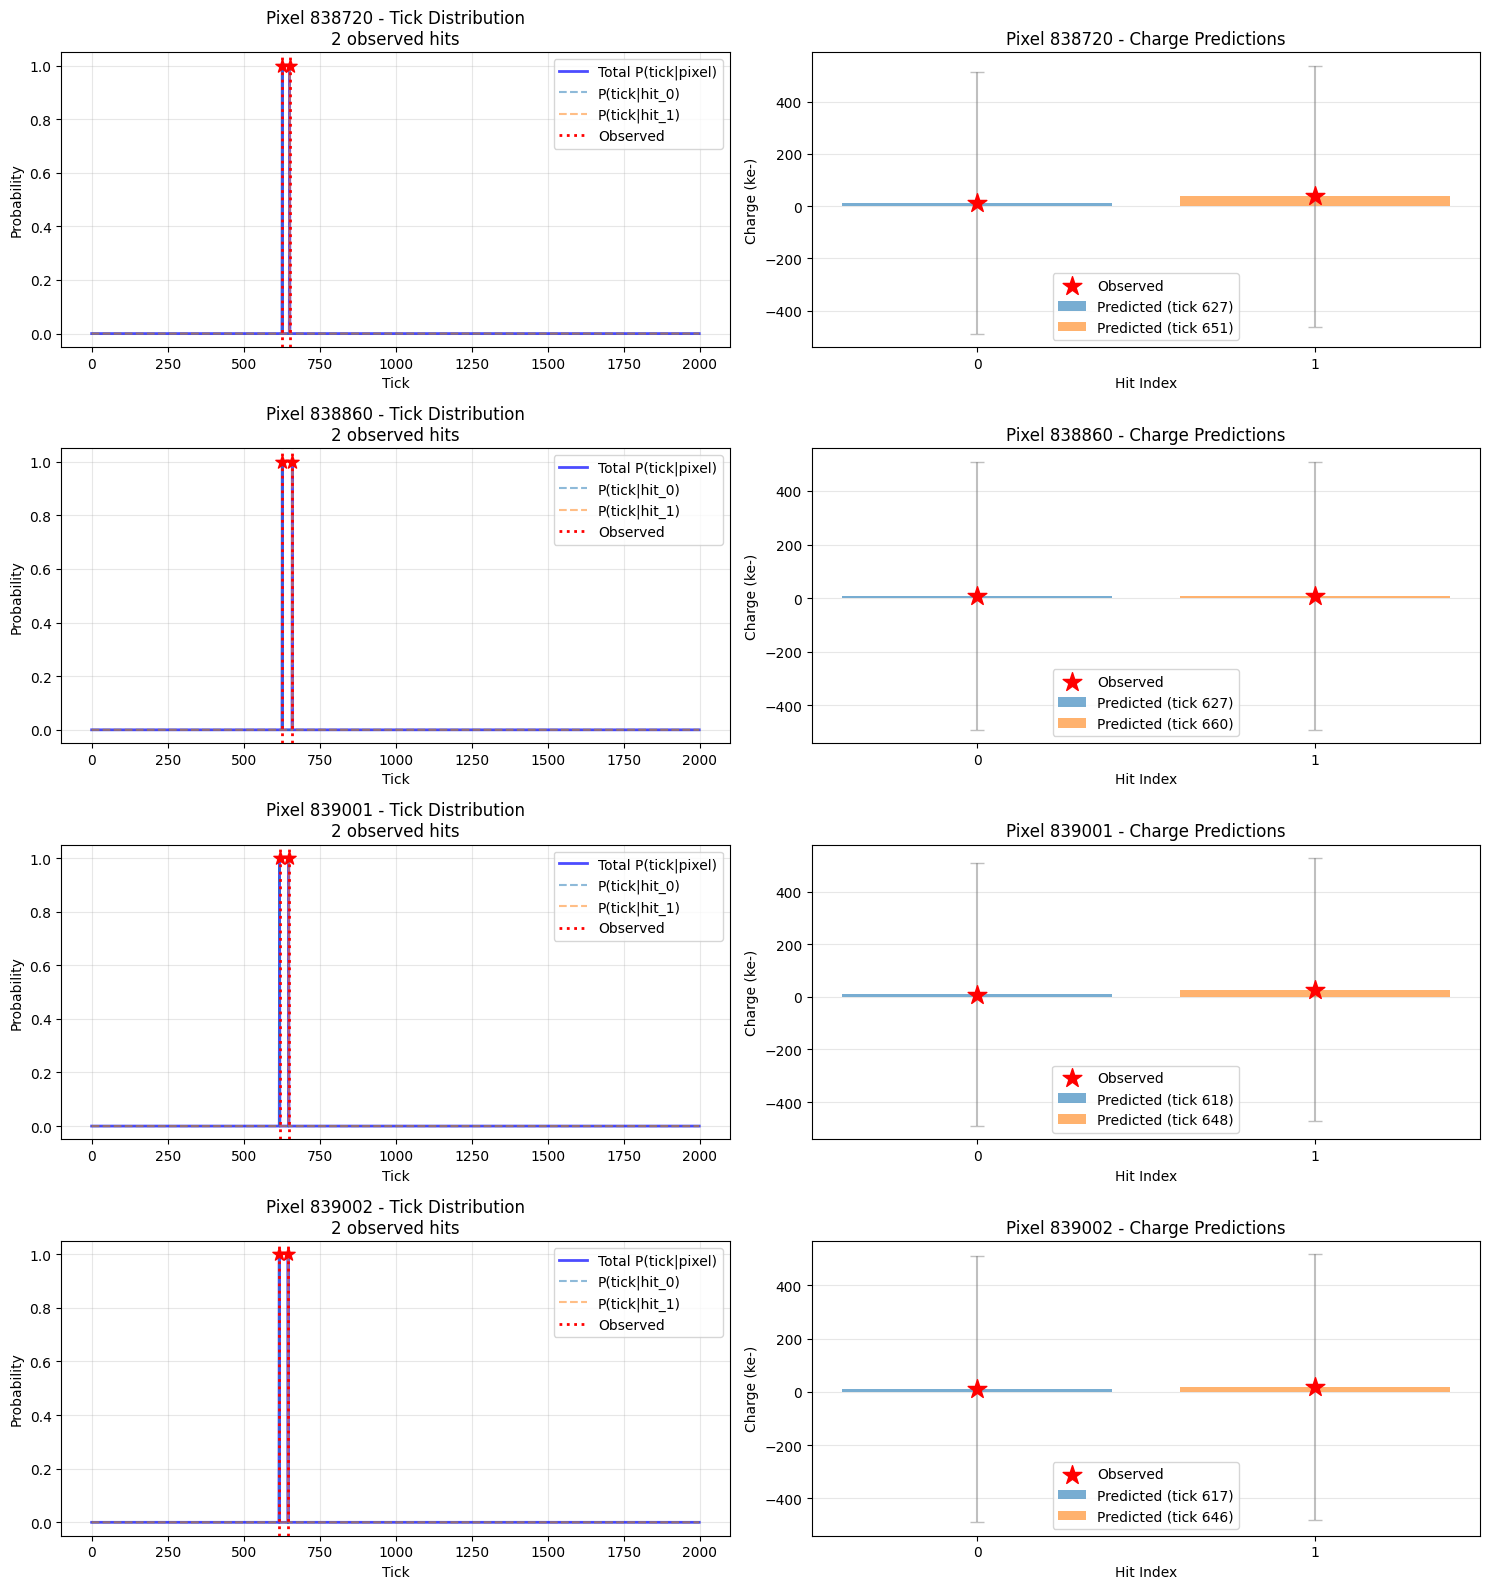

In [96]:
# Generate prediction and target data for visualization
# Using the existing pred_strategy and target data from your workspace


# Generate prediction using probabilistic simulation
prediction = pred_strategy.predict(current_params, tracks, track_fields, rngkey)

# Use target data (you may already have this loaded)
# For this example, we'll use the target_output from your workspace
target = {
    'pixel_id': target_output['hit_pixels'],
    'ticks': target_output['ticks'],
    'adcs': target_output['adcs']
}

print(f"Prediction shapes:")
print(f"  ticks_prob: {prediction['ticks_prob'].shape}")
print(f"  adcs_distrib: {prediction['adcs_distrib'].shape}")
print(f"  unique_pixels: {prediction['unique_pixels'].shape}")
print(f"\nTarget info:")
print(f"  Number of hits: {len(target['pixel_id'])}")
print(f"  Unique pixels with hits: {len(jnp.unique(target['pixel_id']))}")

# Visualize
fig = visualize_probabilistic_predictions(prediction, target, max_pixels=4)
plt.show()

### Understanding the Plots

**Left column - Tick Probability Distribution:**
- **Blue solid line**: Total probability P(tick|pixel) = sum over all possible hit indices
- **Dashed lines**: Individual P(tick|hit_i) for the first few possible hits  
- **Red dotted lines**: Observed hit times from data
- **Red stars**: Predicted probability at the observed tick time

The model should concentrate probability mass at the observed tick times.

**Right column - Charge Predictions:**
- **Blue bars**: Predicted charge at each observed hit time
- **Red stars**: Actual observed charge values
- **Gray error bars**: ±σ uncertainty (from Gaussian likelihood, σ=500 ke-)

The predicted charges should match observed values within the uncertainty.

**What to look for:**
- ✅ Good fit: Probability peaks align with observed ticks, charges match within error bars
- ⚠️ Poor fit: Probability spread out or peaked at wrong ticks, large charge mismatches

Residual Statistics (for 253 valid hits):

Time residuals:
  Mean: -7.381 ticks
  Std:  107.883 ticks
  Median: 0.000 ticks
  MAE: 7.386 ticks

Charge residuals:
  Mean: -0.010 ke-
  Std:  0.797 ke-
  Median: 0.000 ke-
  MAE: 0.304 ke-
  Relative MAE: 1.2%


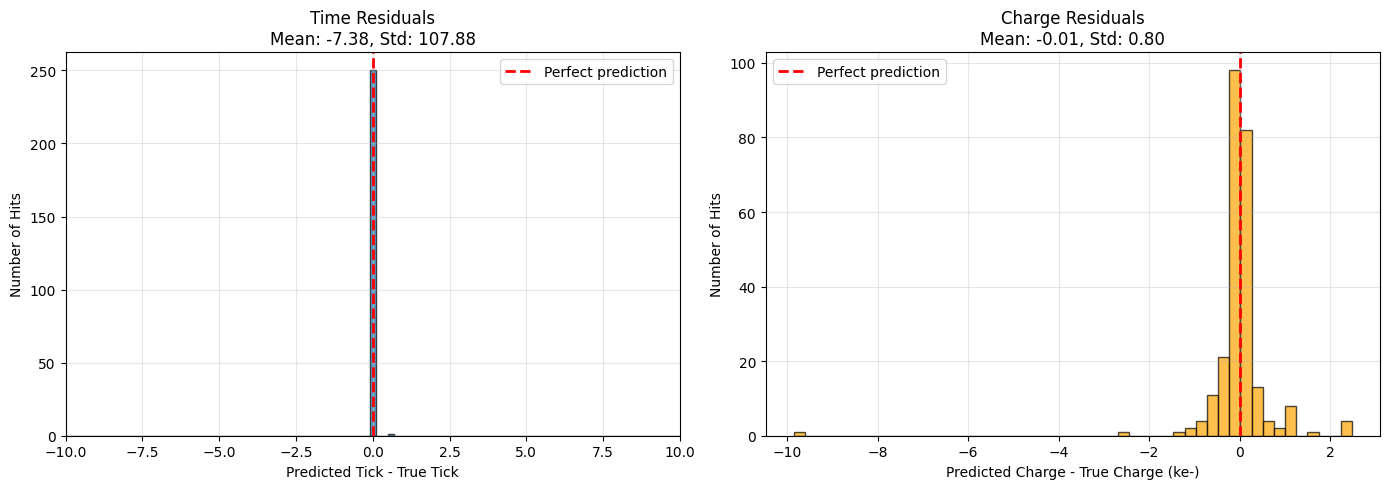

In [104]:
from optimize.strategies import compute_occurrence_indices

def plot_residual_distributions(prediction, target, params):
    """
    Plot distributions of (predicted - true) for both charge and time across all hits.
    
    For time: uses expected tick (weighted average of distribution)
    For charge: uses predicted charge at the observed tick time
    
    Args:
        prediction: Dict with 'ticks_prob', 'adcs_distrib', 'unique_pixels'
        target: Dict with 'pixel_id', 'ticks', 'adcs'
        params: Simulation parameters (for adc2charge conversion)
    """
    ticks_prob = jnp.exp(prediction['ticks_prob'])  # (Npix, Nhits, Nticks)
    adcs_distrib = prediction['adcs_distrib']  # (Npix, Nhits, Nticks)
    unique_pixels = prediction['unique_pixels']
    
    target_pixel_ids = target['pixel_id']
    target_ticks = target['ticks']
    target_adcs = target['adcs']
    target_charges = adc2charge(target_adcs, params)
    
    Npix, Nhits, Nticks = ticks_prob.shape
    
    # Match target hits to predicted pixels
    pixel_indices = jnp.searchsorted(unique_pixels, target_pixel_ids)
    pixel_indices_safe = jnp.clip(pixel_indices, 0, unique_pixels.shape[0] - 1)
    pixel_match_valid = (unique_pixels[pixel_indices_safe] == target_pixel_ids) & (target_pixel_ids >= 0)
    
    # Compute occurrence indices (which hit number for this pixel)
    trigger_indices = compute_occurrence_indices(target_pixel_ids)
    
    # Extract predictions for matched hits only
    valid_hits = pixel_match_valid
    
    # --- Time residuals ---
    # Compute expected tick for each hit: E[tick] = sum(tick * P(tick))
    tick_range = jnp.arange(Nticks)
    expected_ticks_all = jnp.sum(ticks_prob * tick_range[None, None, :], axis=2)  # (Npix, Nhits)
    
    # Get expected tick for each observed hit
    predicted_ticks = expected_ticks_all[pixel_indices_safe, trigger_indices]
    predicted_ticks = jnp.where(valid_hits, predicted_ticks, jnp.nan)
    
    time_residuals = predicted_ticks - target_ticks.astype(float)
    time_residuals = time_residuals[valid_hits]
    
    # --- Charge residuals ---
    # Get predicted charge at observed tick time
    target_ticks_int = target_ticks.astype(int)
    predicted_adcs = adcs_distrib[pixel_indices_safe, trigger_indices, target_ticks_int]
    predicted_charges = adc2charge(predicted_adcs, params)
    predicted_charges = jnp.where(valid_hits, predicted_charges, jnp.nan)
    
    charge_residuals = predicted_charges - target_charges
    charge_residuals = charge_residuals[valid_hits]
    
    # --- Create plots ---
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Time residuals
    ax_time = axes[0]
    ax_time.hist(time_residuals, bins=np.linspace(-10, 10, 100), alpha=0.7, edgecolor='black')
    ax_time.axvline(0, color='red', linestyle='--', linewidth=2, label='Perfect prediction')
    ax_time.set_xlabel('Predicted Tick - True Tick')
    ax_time.set_ylabel('Number of Hits')
    ax_time.set_title(f'Time Residuals\nMean: {jnp.mean(time_residuals):.2f}, Std: {jnp.std(time_residuals):.2f}')
    ax_time.legend()
    ax_time.grid(True, alpha=0.3)
    ax_time.set_xlim(-10, 10)
    
    # Charge residuals
    ax_charge = axes[1]
    ax_charge.hist(charge_residuals, bins=50, alpha=0.7, edgecolor='black', color='orange')
    ax_charge.axvline(0, color='red', linestyle='--', linewidth=2, label='Perfect prediction')
    ax_charge.set_xlabel('Predicted Charge - True Charge (ke-)')
    ax_charge.set_ylabel('Number of Hits')
    ax_charge.set_title(f'Charge Residuals\nMean: {jnp.mean(charge_residuals):.2f}, Std: {jnp.std(charge_residuals):.2f}')
    ax_charge.legend()
    ax_charge.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    # Print summary statistics
    print(f"Residual Statistics (for {jnp.sum(valid_hits)} valid hits):")
    print(f"\nTime residuals:")
    print(f"  Mean: {jnp.mean(time_residuals):.3f} ticks")
    print(f"  Std:  {jnp.std(time_residuals):.3f} ticks")
    print(f"  Median: {jnp.median(time_residuals):.3f} ticks")
    print(f"  MAE: {jnp.mean(jnp.abs(time_residuals)):.3f} ticks")
    
    print(f"\nCharge residuals:")
    print(f"  Mean: {jnp.mean(charge_residuals):.3f} ke-")
    print(f"  Std:  {jnp.std(charge_residuals):.3f} ke-")
    print(f"  Median: {jnp.median(charge_residuals):.3f} ke-")
    print(f"  MAE: {jnp.mean(jnp.abs(charge_residuals)):.3f} ke-")
    print(f"  Relative MAE: {jnp.mean(jnp.abs(charge_residuals) / target_charges[valid_hits]):.1%}")
    
    return fig, time_residuals, charge_residuals

# Plot the residual distributions
prediction = pred_strategy.predict(ref_params, tracks, track_fields, rngkey)
target_output = target_strategy.predict(ref_params, tracks, track_fields, rngkey)
target = {
    'pixel_id': target_output['hit_pixels'],
    'ticks': target_output['ticks'],
    'adcs': target_output['adcs']
}
fig, time_res, charge_res = plot_residual_distributions(prediction, target, ref_params)
plt.show()

Correlation Coefficients:
  Time:   r = 0.9794
  Charge: r = 0.9998


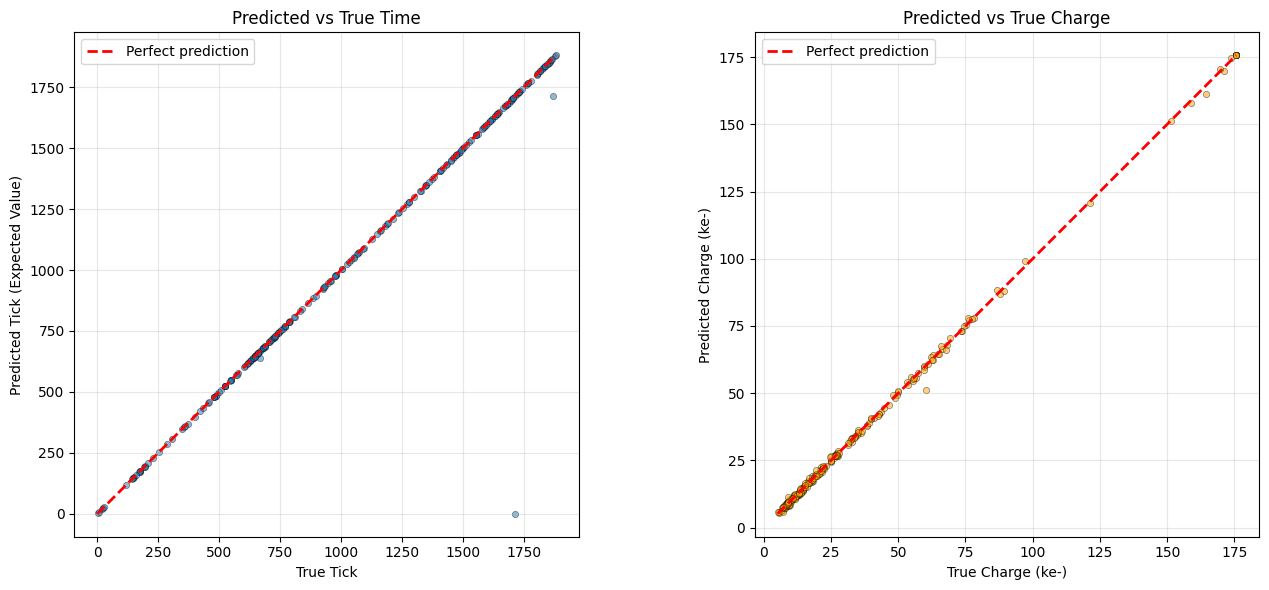

In [98]:
def plot_predicted_vs_true(prediction, target, params):
    """
    Create scatter plots of predicted vs true values for both time and charge.
    
    Args:
        prediction: Dict with 'ticks_prob', 'adcs_distrib', 'unique_pixels'
        target: Dict with 'pixel_id', 'ticks', 'adcs'
        params: Simulation parameters (for adc2charge conversion)
    """
    ticks_prob = jnp.exp(prediction['ticks_prob'])  # (Npix, Nhits, Nticks)
    adcs_distrib = prediction['adcs_distrib']  # (Npix, Nhits, Nticks)
    unique_pixels = prediction['unique_pixels']
    
    target_pixel_ids = target['pixel_id']
    target_ticks = target['ticks']
    target_adcs = target['adcs']
    target_charges = adc2charge(target_adcs, params)
    
    Npix, Nhits, Nticks = ticks_prob.shape
    
    # Match target hits to predicted pixels
    pixel_indices = jnp.searchsorted(unique_pixels, target_pixel_ids)
    pixel_indices_safe = jnp.clip(pixel_indices, 0, unique_pixels.shape[0] - 1)
    pixel_match_valid = (unique_pixels[pixel_indices_safe] == target_pixel_ids) & (target_pixel_ids >= 0)
    
    # Compute occurrence indices
    trigger_indices = compute_occurrence_indices(target_pixel_ids)
    
    # Extract predictions for matched hits only
    valid_hits = pixel_match_valid
    
    # --- Get predicted values ---
    # Time: expected tick
    tick_range = jnp.arange(Nticks)
    expected_ticks_all = jnp.sum(ticks_prob * tick_range[None, None, :], axis=2)  # (Npix, Nhits)
    predicted_ticks = expected_ticks_all[pixel_indices_safe, trigger_indices]
    predicted_ticks = predicted_ticks[valid_hits]
    
    # Charge: predicted charge at observed tick
    target_ticks_int = target_ticks.astype(int)
    predicted_adcs = adcs_distrib[pixel_indices_safe, trigger_indices, target_ticks_int]
    predicted_charges = adc2charge(predicted_adcs, params)
    predicted_charges = predicted_charges[valid_hits]
    
    # True values
    true_ticks = target_ticks[valid_hits].astype(float)
    true_charges = target_charges[valid_hits]
    
    # --- Create scatter plots ---
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Time scatter
    ax_time = axes[0]
    ax_time.scatter(true_ticks, predicted_ticks, alpha=0.5, s=20, edgecolors='k', linewidth=0.5)
    
    # Perfect prediction line (y = x)
    time_min = min(jnp.min(true_ticks), jnp.min(predicted_ticks))
    time_max = max(jnp.max(true_ticks), jnp.max(predicted_ticks))
    ax_time.plot([time_min, time_max], [time_min, time_max], 'r--', linewidth=2, label='Perfect prediction')
    
    ax_time.set_xlabel('True Tick')
    ax_time.set_ylabel('Predicted Tick (Expected Value)')
    ax_time.set_title('Predicted vs True Time')
    ax_time.legend()
    ax_time.grid(True, alpha=0.3)
    ax_time.set_aspect('equal', adjustable='box')
    
    # Charge scatter
    ax_charge = axes[1]
    ax_charge.scatter(true_charges, predicted_charges, alpha=0.5, s=20, 
                     edgecolors='k', linewidth=0.5, color='orange')
    
    # Perfect prediction line
    charge_min = min(jnp.min(true_charges), jnp.min(predicted_charges))
    charge_max = max(jnp.max(true_charges), jnp.max(predicted_charges))
    ax_charge.plot([charge_min, charge_max], [charge_min, charge_max], 'r--', 
                   linewidth=2, label='Perfect prediction')
    
    ax_charge.set_xlabel('True Charge (ke-)')
    ax_charge.set_ylabel('Predicted Charge (ke-)')
    ax_charge.set_title('Predicted vs True Charge')
    ax_charge.legend()
    ax_charge.grid(True, alpha=0.3)
    ax_charge.set_aspect('equal', adjustable='box')
    
    plt.tight_layout()
    
    # Compute correlation coefficients
    time_corr = jnp.corrcoef(true_ticks, predicted_ticks)[0, 1]
    charge_corr = jnp.corrcoef(true_charges, predicted_charges)[0, 1]
    
    print(f"Correlation Coefficients:")
    print(f"  Time:   r = {time_corr:.4f}")
    print(f"  Charge: r = {charge_corr:.4f}")
    
    return fig

# Create scatter plots
fig_scatter = plot_predicted_vs_true(prediction, target, current_params)
plt.show()